# Taller 2 · De 16 canales a la figura

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

En el Taller 1 tenían un electrodo y tres neuronas. Aquí tienen **una sonda con 16 electrodos** y dos
registros (experimentos) donde no todo lo que cruza el umbral es una neurona. La pregunta cambia: ya
no es sólo *¿qué neurona responde a qué estímulo?*, sino **¿cuáles de estos grupos son neuronas de
verdad?** y, de ser neuronas de verdad, **¿cuáles responden de manera significativa al estímulo?**

## Cómo está organizado

Trabajan con **dos registros de la misma sonda**:

| archivo | qué trae | para qué |
|---|---|---|
| `taller2_limpia.h5` | 90 s, sin estímulos, unas pocas unidades bien separadas y poco ruido | aprender el método donde todo sale bonito |
| `taller2_ruidosa.h5` | 200 s, tres condiciones de estímulo, muchas más unidades, actividad multiunitaria y artefactos | hacer el trabajo de verdad |

**El pipeline se escribe una sola vez.** Lo construyen sobre la grabación limpia (secciones 1 a 3) y
después lo corren sobre la ruidosa (sección 4 en adelante) cambiando **únicamente el nombre del
archivo**. Por eso todo lo que escriban va en funciones, con argumentos, y no como un guion de arriba
abajo.

**Las secciones 1 a 3** van en las sesiones del 8 y el 10 de septiembre, **4 a 8** en el
laboratorio del 11, y **9 a 12** en la sesión del 15.

## Qué se entrega

Un solo notebook, en el repositorio de la pareja, carpeta `taller2/`, con:

- todas las celdas de código corriendo de arriba abajo sin errores,
- **las 12 preguntas contestadas** (P1 a P12): cada una tiene una parte de
  selección múltiple y una parte abierta,
- **la hoja de respuestas del final llena**, con las letras y los números de su pipeline,
- **OJO:** el `README.md` actualizado (la mayoría no hizo README en el Taller 1),


**Los datos NO van al repositorio.** Entre los dos pesan unos 105 MB. GitHub aceptaría el archivo
grande con una advertencia, así que la razón no es que no quepa: es que **git guarda todas las
versiones de cada archivo para siempre**, y un binario grande infla el repositorio de forma
permanente, aunque después lo borren. Por eso el repositorio lleva el código y el enlace de descarga,
y los datos se bajan cada vez que se abre el notebook. Es la práctica estándar: el código es lo que
cambia y vive en GitHub, y los datos pueden ir o no a un repositorio aparte, como Zenodo.

**Peso: 30 % de la nota del curso.** Habrá además un quiz en clase que puede subir esta nota.

## Cómo se usa la IA aquí

Igual que en el Taller 1. Los iconos:

- ✏️ **Ejercicio**: lo escriben ustedes, con o sin ayuda de la IA.
- ✍️ **Prompt**: además del código, tienen que dejar escrito el prompt que usaron.
- ⚠️ **Trampa**: un error que casi todo el mundo comete la primera vez. Léanlo antes de programar.

Un recordatorio del Taller 1: la IA puede proponer código que corre y da un resultado equivocado.
La única defensa es **graficar el resultado intermedio** y preguntarse si tiene sentido biológico.

## 0 · Preparación

Corran esta celda una sola vez. Baja de una carpeta de Drive los dos registros y el módulo de
verificación. Si les pide reintentar, vuelvan a correrla: los archivos ya bajados no se vuelven a bajar.

⚠️ **Trampa.** La grabación ruidosa son 200 s por 16 canales. En memoria, como números decimales,
son unos 380 MB. Colab lo aguanta, pero **no carguen las dos grabaciones a la vez** si les da error
de memoria: trabajen una, y cuando pasen a la otra reinicien el entorno.

In [ ]:
# Carpeta de Drive con los datos y el modulo de verificacion
ID_CARPETA = "1L4t2SJW36ntvtpDvW3wQEUDLRLehXVGv"

import os
if not all(os.path.exists(f) for f in ["taller2_limpia.h5", "taller2_ruidosa.h5",
                                       "verificacion.py"]):
    !pip -q install --upgrade gdown
    import gdown
    gdown.download_folder(id=ID_CARPETA, output=".", quiet=False, use_cookies=False)

for f in sorted(os.listdir(".")):
    if f.endswith((".h5", ".py")):
        print(f, f"{os.path.getsize(f)/1e6:.1f} MB")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, sosfiltfilt

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

---
# 1 · El archivo, la sonda y el filtro

Una **sonda lineal** es una aguja plana de silicio con varios sitios de registro (electrodos) repartidos a lo largo de la
punta. Cada sitio mide el voltaje en su vecindad, así que un mismo potencial de acción aparece en
varios sitios a la vez, con amplitud distinta en cada uno.

Esa es una ventaja de tener varios canales, y de ella salen dos cosas que con un electrodo solo
no se pueden hacer:

1. **Ubicar la neurona.** Si la amplitud es máxima en el sitio 6 y va cayendo hacia arriba y hacia
   abajo, la neurona está cerca del sitio 6. Esa posición es una característica más para separar sus
   disparos de los de otras posibles neuronas.
2. **Reconocer lo que no es una neurona.** Una neurona está *localizada*: su señal desaparece a unos
   100 µm. Un artefacto eléctrico aparece **en los 16 sitios a la vez, y puede tener la misma forma
   que un potencial de acción**. Esa diferencia tiene mucho peso a la hora de descartar artefactos.

La amplitud cae con la distancia porque el medio extracelular conduce y dispersa: aproximadamente
como 1/r, donde r es la distancia entre la neurona y el sitio de registro.

El archivo trae el grupo `geometria`, con la posición de cada sitio en micrómetros.

## ¿Qué es un archivo `.h5`?

Un `.h5` (formato **HDF5**, *Hierarchical Data Format*) es el estándar para guardar datos científicos
grandes. Un registro de 200 s en 16 canales a 15 kHz son 48 millones de números: en CSV serían unos
500 MB de texto que hay que leer entero antes de mirar el primer milisegundo. El mismo registro en
`.h5` pesa 73 MB, y permite leer un pedazo sin cargar el resto.

Piensen en un `.h5` como **un sistema de carpetas dentro de un solo archivo**. Tiene tres piezas:

| pieza | analogía | qué es |
|---|---|---|
| **Grupo** (*group*) | carpeta | contiene otros grupos y datasets |
| **Dataset** | archivo | un arreglo de números, como un `np.array` |
| **Atributo** (*attrs*) | etiqueta pegada | metadato corto: frecuencia de muestreo, unidades, notas |

Los atributos son los que explican qué hay dentro del archivo y en qué unidades está.

Tres cosas importantes:

1. **Un dataset no es un arreglo.** `archivo['registro/datos']` no trae nada a memoria hasta que se
   indexa con `[x:y]`. Esa es la ventaja del formato, y también la razón por la que `.shape` responde
   al instante en un archivo de 70 MB.
2. **Los enteros no son microvoltios.** El equipo guarda cuentas del conversor analógico-digital; hay
   que multiplicar por `escala_uV_por_bit`. Si se saltan ese paso, las amplitudes salen unas cinco
   veces más grandes y sin sentido físico.
3. **Los textos salen como bytes** (`b'A'` en vez de `'A'`). Se arregla con `.astype(str)` o
   `.decode()`.

Se abre siempre con `with ... as f:` para que quede cerrado. Un `.h5` abierto dos veces en modo
escritura se corrompe.

### Cómo se abre

Pregúntenle a la IA, o miren el Taller 1. Ese prompt les puede servir como el intercambio 1 del
ejercicio 14b.

## Mirar antes de calcular, y filtrar

La señal cruda mezcla cosas que ocurren a escalas de tiempo muy distintas. Los potenciales de
acción duran alrededor de 1 ms, así que su energía está por encima de unos 300 Hz. Por debajo hay
señales lentas: el potencial de campo local, que es la actividad conjunta de miles de neuronas, la
deriva del electrodo, y el ruido de la red eléctrica a 60 Hz.

Un **filtro pasa-banda de 300 a 5000 Hz** deja pasar los disparos y quita lo demás. El límite de
arriba no es capricho: por encima de 5000 Hz ya casi no hay señal neuronal y sí hay ruido térmico.

⚠️ **Trampa.** Usen `sosfiltfilt` y no `sosfilt`. El primero filtra hacia adelante y hacia atrás, así
que no desplaza la señal en el tiempo. El segundo introduce un retardo que corre todos sus disparos
unos cuantos milisegundos, y eso arruina en silencio todo lo que venga después.

### ✏️ Ejercicio 1

**a)** Abran `taller2_limpia.h5` y averigüen qué contiene: los grupos, los conjuntos de datos, la
frecuencia de muestreo, el factor de conversión a microvoltios y las posiciones de los sitios.

**b)** Dibujen la sonda: un punto por sitio, en su posición real, con el número de canal al lado.

**c)** Carguen la grabación, conviértanla a microvoltios y grafíquenla en dos paneles, cruda y
filtrada, con los 16 canales organizados por profundidad y una ventana de medio segundo.


**Nota:**

>Para generar el código siguiente hubo 3 cambios en el prompt que permitieron mantener las especificaciones dadas. El cambio más necesario fue convertir los tres procesos en definiciones en vez de códigos independientes. Todo se termina especificando en el prompt final que contiene detalles al respecto de la construcción de cada función.

**Prompt inicial:**

>"Crea código en Python (para Google Colab) que sobre un archivo `.h5` de registros electrofisiológicos: Exploración que abre el archivo, imprime todos los grupos y datasets. El siguiente es Dibujo de la sonda que grafica un scatter con un punto por sitio en su posición real y el número de canal anotado al lado, con el eje Y invertido. Finalmente, otro código debe cargar la grabación, convertirla a microvoltios y graficarla en dos paneles, cruda y filtrada, con los 16 canales organizados por profundidad y una ventana de medio segundo."

**Cambio 1:** Tras explorar el archivo y obtener 3 bloques de código.

>"Tengo tres bloques de código en Python (para Google Colab) que hacen lo siguiente sobre un archivo `.h5` de registros electrofisiológicos: Exploración que abre el archivo, imprime todos los grupos y datasets con `visititems`, imprime los atributos de cada grupo/dataset y los del archivo raíz, y luego imprime las posiciones (x_um, y_um) de cada canal desde `geometria/canal_x_um` y `geometria/canal_y_um`.Dibujo de la sonda que grafica un scatter con un punto por sitio en su posición real (x_um, y_um) y el número de canal anotado al lado, con el eje Y invertido (profundidad hacia abajo).Y final mente Carga, conversión y filtrado que abre `registro/datos` (forma canales × muestras, tipo int16), carga solo una ventana de 0.5 s (usando indexado perezoso, sin traer el archivo completo a memoria), la convierte a microvoltios multiplicando por el atributo `escala_uV_por_bit`, ordena los canales por profundidad usando `canal_y_um`, aplica un filtro pasa-banda de 300–5000 Hz con `scipy.signal.butter` (`output='sos'`) y `sosfiltfilt` (para evitar desfase temporal), y grafica dos paneles lado a lado (cruda vs. filtrada) con los canales apilados verticalmente por profundidad y el número de canal original etiquetado.

>Quiero que reescribas estos tres pasos como definiciones para poder aplicarlos a otros archivos `.h5` con estructura similar, sin tener que reescribir el código cada vez.

**Cambio 2:** Recuperar todo el código obtenido como funciones reutilizables para usar con taller2_ruidosa.h5

> + "Una función para explorar el archivo que imprima todo lo anterior y devuelva un diccionario con lo esencial (frecuencia de muestreo, escala a µV, posiciones x/y de los canales, shape de los datos) para no tener que reabrir el archivo en los pasos siguientes. Una función `dibujar_sonda` que reciba ese diccionario y grafique la sonda y una función auxiliar con filtro low=300, high=5000."

**Cambio 3:** Para entender cómo usar el código tanto con taller2_limpia.h5 como con taller2_ruidosa.h5

> + "Al final, muestra un ejemplo de uso encadenando las tres funciones con una ruta de archivo. Si el nombre de algún atributo (como la frecuencia de muestreo o la escala) cambia en otro archivo, indica exactamente qué líneas del código habría que ajustar."

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt


def explorar_h5(ruta):
    """
    Paso a) Recorre el archivo e imprime grupos, datasets, atributos
    y posiciones de los sitios. Devuelve un diccionario con lo esencial
    para no tener que volver a abrir el archivo después.
    """
    info = {}
    with h5py.File(ruta, "r") as f:
        print("=" * 60)
        print("GRUPOS Y DATASETS")
        print("=" * 60)
        def listar(nombre, objeto):
            tipo = "GRUPO" if isinstance(objeto, h5py.Group) else "DATASET"
            extra = f"  shape={objeto.shape}  dtype={objeto.dtype}" if tipo == "DATASET" else ""
            print(f"[{tipo}] {nombre}{extra}")
        f.visititems(listar)

        print("\n" + "=" * 60)
        print("ATRIBUTOS")
        print("=" * 60)
        def listar_attrs(nombre, objeto):
            if len(objeto.attrs) > 0:
                print(f"\n{nombre}:")
                for clave, valor in objeto.attrs.items():
                    print(f"   {clave} = {valor}")
        f.visititems(listar_attrs)
        print("\nAtributos del archivo raíz (/):")
        for clave, valor in f.attrs.items():
            print(f"   {clave} = {valor}")

        # guarda lo esencial para los pasos siguientes
        info["fs"] = f.attrs.get("frecuencia_muestreo_hz")
        info["escala"] = f.attrs.get("escala_uV_por_bit")
        info["x_um"] = f["geometria/canal_x_um"][:]
        info["y_um"] = f["geometria/canal_y_um"][:]
        info["shape_datos"] = f["registro/datos"].shape

        print("\n" + "=" * 60)
        print("POSICIONES DE LOS SITIOS")
        print("=" * 60)
        for canal, (x, y) in enumerate(zip(info["x_um"], info["y_um"])):
            print(f"canal {canal}: x={x} um, y={y} um")

    return info


def dibujar_sonda(info, titulo="Geometría de la sonda"):
    """
    Paso b) Dibuja un punto por sitio con su número de canal al lado.
    Recibe el diccionario `info` que devuelve explorar_h5().
    """
    x_um, y_um = info["x_um"], info["y_um"]
    fig, ax = plt.subplots(figsize=(4, 8))
    ax.scatter(x_um, y_um, s=80, color="steelblue")
    for canal, (x, y) in enumerate(zip(x_um, y_um)):
        ax.annotate(str(canal), (x, y), textcoords="offset points", xytext=(8, 0), fontsize=9)
    ax.set_xlabel("X (µm)")
    ax.set_ylabel("Y (µm)")
    ax.set_title(titulo)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


def bandpass_sos(datos, fs, low=300, high=5000, orden=4):
    """Filtro pasa-banda sin desfase (sosfiltfilt)."""
    nyq = fs / 2
    sos = butter(orden, [low / nyq, high / nyq], btype="band", output="sos")
    return sosfiltfilt(sos, datos, axis=-1)


def cargar_convertir_filtrar_graficar(ruta, info, ventana_s=0.5, low=300, high=5000):
    """
    Paso c) Carga una ventana de la grabación, la convierte a µV,
    la filtra y grafica dos paneles (cruda vs filtrada) con los canales
    ordenados por profundidad.
    """
    fs = info["fs"]
    escala = info["escala"]
    y_um = info["y_um"]

    with h5py.File(ruta, "r") as f:
        datos_raw = f["registro/datos"]
        n_muestras_ventana = int(ventana_s * fs)
        trozo = datos_raw[:, :n_muestras_ventana]  # solo esta ventana se carga a memoria

    # enteros ADC -> µV
    trozo_uV = trozo * escala

    # ordenar canales por profundidad
    orden_profundidad = np.argsort(y_um)
    trozo_uV_ordenado = trozo_uV[orden_profundidad]

    # filtrar
    trozo_filtrado = bandpass_sos(trozo_uV_ordenado, fs, low=low, high=high)

    # graficar
    tiempo = np.arange(n_muestras_ventana) / fs
    n_canales = trozo_uV_ordenado.shape[0]
    separacion = np.max(np.abs(trozo_uV_ordenado)) * 1.5

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
    for i in range(n_canales):
        offset = i * separacion
        ax1.plot(tiempo, trozo_uV_ordenado[i] + offset, lw=0.5, color="black")
        ax2.plot(tiempo, trozo_filtrado[i] + offset, lw=0.5, color="darkred")
        canal_original = orden_profundidad[i]
        ax1.text(-0.01, offset, str(canal_original), fontsize=7, ha="right", va="center")

    ax1.set_title("Cruda (µV)")
    ax2.set_title(f"Filtrada ({low}–{high} Hz, sosfiltfilt)")
    ax1.set_xlabel("Tiempo (s)")
    ax2.set_xlabel("Tiempo (s)")
    ax1.set_ylabel("Canal (ordenado por profundidad)")
    ax1.set_yticks([])
    plt.tight_layout()
    plt.show()

    return trozo_uV_ordenado, trozo_filtrado

    trozo_filtrado=trozo_filtrado

In [ ]:
ruta = "/content/taller2_limpia.h5"

info_limpia = explorar_h5(ruta)
print(info_limpia)
dibujar_sonda(info_limpia)
cruda, trozo_filtrado = cargar_convertir_filtrar_graficar(ruta, info_limpia)

**P1.**

**Selección múltiple.** La amplitud cae aproximadamente como 1/r, donde r es la distancia entre la
neurona y el sitio. Una neurona está a 20 µm del sitio más cercano. Moviéndose por la sonda a partir
de ese sitio, ¿a qué distancia la amplitud habrá caído a la mitad?

- **Respuesta: a) unos 35 µm: menos de lo que hay entre dos sitios vecinos**
- **b)** unos 40 µm: exactamente el sitio siguiente
- **c)** unos 80 µm: dos sitios más allá
- **d)** unos 200 µm: cinco sitios más allá

**Abierta.** En la señal filtrada busquen un evento que aparezca **en los 16 canales al mismo
tiempo**. ¿Puede eso ser una neurona? Justifiquen en dos frases usando la caída 1/r.


***Su respuesta:*** Existe un evento que tiene dos picos, uno en el canal 3 y otro en el 11. Si este fuera causado por una única neurona mostraría únicamente un pico debido al decaimíento de amplitud de 1/r en el espacio, por lo que en estas circunstancias debería tener un máximo en el sitio más cercano y caer el los otros canales

---
# 2 · Detectar los disparos en 16 canales

## Repaso: el umbral de detección con la mediana

El umbral se pone en `k` veces el nivel de ruido. Pero hay que medir ese nivel sin que los disparos lo
contaminen: si usan la desviación estándar de la señal, los potenciales de acción la inflan, el umbral
sube y se pierde la capacidad de detectarlos. Mientras más potenciales de acción tenga el registro,
peor.

La solución es medir el ruido con la **mediana del valor absoluto de la señal**. Los disparos ocupan
menos del 1 % del tiempo de grabación, así que la mediana los excluye: describe el ruido mucho mejor
que la desviación estándar, que se calcula a partir de la media y por eso es susceptible a los valores
extremos, que son justamente los que queremos detectar.

Falta un detalle de unidades. Para una campana normal de desviación estándar σ, la mediana del valor
absoluto vale siempre 0,6745 · σ. Dividiendo por esa constante, el número queda expresado como si
fuera una desviación estándar, y entonces **`k = 4` significa que el umbral está 4 desviaciones
estándar del ruido por debajo de cero**. Cero es la media, porque el filtro ya quitó
cualquier componente de deriva lenta.

## Lo nuevo en el Taller 2

**Ahora hay 16 canales.** Un PA cruza el umbral en tres o cuatro sitios a la vez, con unas
décimas de milisegundo de diferencia. Si cuentan cada cruce por separado van a contar el mismo
potencial de acción cuatro veces.

La solución estándar tiene tres pasos:

1. Calcular un umbral **por canal** (cada sitio tiene su propio nivel de ruido).
2. Marcar todos los cruces en cada canal.
3. **Fusionar** los cruces que caen dentro de una misma ventana corta (0,5 ms) en un solo evento, y
   quedarse con el instante y el canal donde el voltaje fue **más negativo de todos**. Ese canal se
   llama el **canal pico** del evento.

### ✍️ Ejercicio 2 · Escriban su prompt

Escriban la función `detectar(X, k=4.5, muerto_ms=0.5, fs=15000)` que reciba la señal filtrada de los
16 canales y devuelva dos arreglos:
1. el instante de cada evento en segundos y
2. su canal pico.

Escríbanle a la IA un prompt que incluya los tres pasos de arriba. Dejen el prompt en la celda de
texto y el código que resultó en la celda de código, con comentarios suyos.

**Su prompt:**
Escribe una función detectar(X, k=4.5, muerto_ms=0.5, fs=15000) que reciba la señal filtrada de los 16 canales y devuelva dos arreglos: el instante de cada evento en segundos y su canal pico. Esta función debe seguir los siguientes pasos: 1. Calcular un umbral por canal (cada sitio tiene su propio nivel de ruido). 2. Marcar todos los cruces en cada canal. 3. Fusionar los cruces que caen dentro de una misma ventana corta (0,5 ms) en un solo evento, y quedarse con el instante y el canal donde el voltaje fue más negativo de todos. Ese canal se llama el canal pico del evento.

In [ ]:
# ✍️ Ejercicio 2
import numpy as np

def detectar(X, k=4.5, muerto_ms=0.5, fs=15000):
    """
    Detecta eventos (spikes) en una señal filtrada multicanal.

    Parámetros
    ----------
    X : np.array, shape (n_canales, n_muestras)
        Señal ya filtrada (pasa-banda), en µV.
    k : float
        Número de desviaciones estándar (robustas) para el umbral.
    muerto_ms : float
        Ventana de fusión: cruces dentro de esta ventana se cuentan
        como un solo evento.
    fs : float
        Frecuencia de muestreo en Hz.

    Devuelve
    --------
    tiempos_s : np.array
        Instante de cada evento, en segundos.
    canales_pico : np.array (int)
        Canal donde el voltaje fue más negativo en cada evento.
    """
    n_canales, n_muestras = X.shape
    muerto_muestras = int(round(muerto_ms / 1000 * fs))

    # 1. Umbral por canal (cada sitio tiene su propio nivel de ruido).
    #    Se usa una estimación robusta de la desviación estándar (MAD),
    #    menos sensible a los propios spikes que np.std.
    sigma = np.median(np.abs(X), axis=1) / 0.6745       # (n_canales,)
    umbral = -k * sigma                                  # umbral negativo por canal

    # 2. Marcar todos los cruces en cada canal.
    cruces = X < umbral[:, None]                          # (n_canales, n_muestras), bool
    hay_cruce = cruces.any(axis=0)                         # (n_muestras,) — algún canal cruzó
    muestras_cruce = np.where(hay_cruce)[0]

    if len(muestras_cruce) == 0:
        return np.array([]), np.array([], dtype=int)

    def _resolver_grupo(idx_grupo):
        """Dado un grupo de muestras (índices), encuentra el instante
        y el canal donde el voltaje fue más negativo entre los canales
        que realmente cruzaron el umbral en esas muestras."""
        sub = X[:, idx_grupo]                              # (n_canales, len(grupo))
        sub_cruces = cruces[:, idx_grupo]
        # solo comparamos valores donde hubo cruce real; el resto se ignora
        sub_enmascarado = np.where(sub_cruces, sub, np.inf)
        canal_min, muestra_rel = np.unravel_index(
            np.argmin(sub_enmascarado), sub_enmascarado.shape
        )
        muestra_min = idx_grupo[muestra_rel]
        return muestra_min / fs, canal_min

    # 3. Fusionar cruces dentro de la misma ventana corta (muerto_ms)
    #    en un solo evento, quedándose con el pico más negativo.
    tiempos_s = []
    canales_pico = []
    grupo_actual = [muestras_cruce[0]]

    for m in muestras_cruce[1:]:
        if m - grupo_actual[-1] <= muerto_muestras:
            grupo_actual.append(m)
        else:
            t, c = _resolver_grupo(np.array(grupo_actual))
            tiempos_s.append(t)
            canales_pico.append(c)
            grupo_actual = [m]

    # último grupo pendiente
    t, c = _resolver_grupo(np.array(grupo_actual))
    tiempos_s.append(t)
    canales_pico.append(c)

    return np.array(tiempos_s), np.array(canales_pico, dtype=int)

# Uso de la función detectar con variables de las celdas anteriores
# Asegúrate que 'trozo_filtrado' y 'info_limpia' (con 'fs') estén definidos en celdas anteriores.
fs = info_limpia['fs']
tiempos_s, canales_pico = detectar(trozo_filtrado, k=4.5, muerto_ms=0.5, fs=fs)

# Re-calculating `muestras_cruce` for histogram analysis
# This logic is extracted from the 'detectar' function to make 'muestras_cruce' available globally.
X_for_muestras_cruce = trozo_filtrado # Use the filtered signal
fs_for_muestras_cruce = info_limpia['fs']
k_for_muestras_cruce = 4.5 # Assuming the default k value from detectar function call

sigma = np.median(np.abs(X_for_muestras_cruce), axis=1) / 0.6745
umbral = -k_for_muestras_cruce * sigma
cruces = X_for_muestras_cruce < umbral[:, None]
hay_cruce = cruces.any(axis=0)
muestras_cruce = np.where(hay_cruce)[0]

print(f"{len(tiempos_s)} eventos detectados")
print("primeros 10 tiempos:", tiempos_s[:10])
print("primeros 10 canales pico:", canales_pico[:10])

In [ ]:
#Con muerto_ms = 0.2

import numpy as np

def detectar(X, k=4.5, muerto_ms=0.001, fs=15000):
    """
    Detecta eventos (spikes) en una señal filtrada multicanal.

    Parámetros
    ----------
    X : np.array, shape (n_canales, n_muestras)
        Señal ya filtrada (pasa-banda), en µV.
    k : float
        Número de desviaciones estándar (robustas) para el umbral.
    muerto_ms : float
        Ventana de fusión: cruces dentro de esta ventana se cuentan
        como un solo evento.
    fs : float
        Frecuencia de muestreo en Hz.

    Devuelve
    --------
    tiempos_s : np.array
        Instante de cada evento, en segundos.
    canales_pico : np.array (int)
        Canal donde el voltaje fue más negativo en cada evento.
    """
    n_canales, n_muestras = X.shape
    muerto_muestras = int(round(muerto_ms / 1000 * fs))

    # 1. Umbral por canal (cada sitio tiene su propio nivel de ruido).
    #    Se usa una estimación robusta de la desviación estándar (MAD),
    #    menos sensible a los propios spikes que np.std.
    sigma = np.median(np.abs(X), axis=1) / 0.6745       # (n_canales,)
    umbral = -k * sigma                                  # umbral negativo por canal

    # 2. Marcar todos los cruces en cada canal.
    cruces = X < umbral[:, None]                          # (n_canales, n_muestras), bool
    hay_cruce = cruces.any(axis=0)                         # (n_muestras,) — algún canal cruzó
    muestras_cruce = np.where(hay_cruce)[0]

    if len(muestras_cruce) == 0:
        return np.array([]), np.array([], dtype=int)

    def _resolver_grupo(idx_grupo):
        """Dado un grupo de muestras (índices), encuentra el instante
        y el canal donde el voltaje fue más negativo entre los canales
        que realmente cruzaron el umbral en esas muestras."""
        sub = X[:, idx_grupo]                              # (n_canales, len(grupo))
        sub_cruces = cruces[:, idx_grupo]
        # solo comparamos valores donde hubo cruce real; el resto se ignora
        sub_enmascarado = np.where(sub_cruces, sub, np.inf)
        canal_min, muestra_rel = np.unravel_index(
            np.argmin(sub_enmascarado), sub_enmascarado.shape
        )
        muestra_min = idx_grupo[muestra_rel]
        return muestra_min / fs, canal_min

    # 3. Fusionar cruces dentro de la misma ventana corta (muerto_ms)
    #    en un solo evento, quedándose con el pico más negativo.
    tiempos_s = []
    canales_pico = []
    grupo_actual = [muestras_cruce[0]]

    for m in muestras_cruce[1:]:
        if m - grupo_actual[-1] <= muerto_muestras:
            grupo_actual.append(m)
        else:
            t, c = _resolver_grupo(np.array(grupo_actual))
            tiempos_s.append(t)
            canales_pico.append(c)
            grupo_actual = [m]

    # último grupo pendiente
    t, c = _resolver_grupo(np.array(grupo_actual))
    tiempos_s.append(t)
    canales_pico.append(c)

    return np.array(tiempos_s), np.array(canales_pico, dtype=int)

# Uso de la función detectar con variables de las celdas anteriores
# Asegúrate que 'trozo_filtrado' y 'info_limpia' (con 'fs') estén definidos en celdas anteriores.
fs = info_limpia['fs']
tiempos_s, canales_pico = detectar(trozo_filtrado, k=4.5, muerto_ms=0.2, fs=fs) #CAMBIO a 0.2

print(f"{len(tiempos_s)} eventos detectados")
print("primeros 10 tiempos:", tiempos_s[:10])
print("primeros 10 canales pico:", canales_pico[:10])

In [ ]:
# Decidimos medir el tiempo muerto usual para entender porqué el cambio de 0.5 a 0.2 no estaba cambiando el resultado
# distancia entre cruces consecutivos, en ms, para ver dónde caen los "huecos"
diffs_ms = np.diff(muestras_cruce) / fs * 1000
plt.hist(diffs_ms[diffs_ms < 5], bins=50)
plt.xlabel("distancia entre cruces consecutivos (ms)")
plt.axvline(0.2, color="green", ls="--", label="0.2 ms")
plt.axvline(0.5, color="red", ls="--", label="0.5 ms")
plt.legend()
plt.show()

In [ ]:
t_05, c_05 = detectar(trozo_filtrado, k=4.5, muerto_ms=0.5, fs=fs)
t_02, c_02 = detectar(trozo_filtrado, k=4.5, muerto_ms=0.2, fs=fs)
print(f"con 0.5 ms: {len(t_05)} eventos")
print(f"con 0.2 ms: {len(t_02)} eventos")

**P2.**

**Selección múltiple.** Vuelvan a correr la detección sobre la grabación limpia con `muerto_ms = 0.2`
en vez de 0,5. Salen más eventos. ¿De dónde salen?

- **a)** de neuronas más lejanas, que antes no cruzaban el umbral
- **Respuesta b) del mismo disparo, contado varias veces**
- **c)** del umbral, que se recalcula más bajo
- **d)** del filtro, que deja pasar más ruido

**Abierta.** Digan cuántos eventos detectaron con 0,5 ms y cuántos con 0,2 ms, y expliquen en una
frase por qué 0,5 ms es una elección razonable y 5 ms no lo sería.

***Su respuesta:***

>En nuestro caso encontramos 15 eventos tanto en 0,5 ms como en 0,2 ms. Al comparar en una gráfica fue posible ver que no había cruces del umbral que se encontraran separados por estos tiempos (se confirmará en el código abajo de esta respuesta), por esta razón no se afectó su cuenta, de hecho, es posible ver que los cruces del umbral se encuentran separados en su mayoría por muy poco tiempo (entre 0 y 0,3 ms). En cuanto a 0,5 ms vs 5 ms, 0,5 ms es razonable porque es apenas mayor que la duración típica de la fase de cruce de un solo potencial de acción,mientras que 5 ms supera el intervalo típico entre disparos reales y puede fusionar eventos genuinamente distintos y perdiendo spikes verdaderos.

In [ ]:
diffs_ms = np.diff(muestras_cruce) / fs * 1000
en_zona_intermedia = diffs_ms[(diffs_ms > 0.2) & (diffs_ms <= 0.5)]
print(f"cruces con separación entre 0.2 y 0.5 ms: {len(en_zona_intermedia)}")

---
# 3 · Dos niveles de medida


Un **evento** es un potencial de acción, no un cruce del umbral. El mismo disparo cruza el
umbral en varios electrodos a la vez, y el detector fusiona esos cruces en uno solo. Para
escoger el canal pico ya tuvo que mirar los 16 canales, pero no guardó nada más.

Por eso la detección de la sección 2 devuelve **dos vectores, uno por evento**: el instante y
el canal pico. Lo primero que hace esta sección es volver a la señal filtrada y recortar una
ventana alrededor de cada instante, en los 16 canales. Ahí aparece la dimensión de canales:

- formas de onda: **eventos × 16 canales × muestras**
- perfil de amplitud, el valor del valle en cada electrodo: **eventos × 16 canales**

De ese perfil salen la amplitud y el centroide.

Todo lo que sigue se mide sobre uno de dos niveles: cada evento, o un grupo ya formado. Las
del segundo nivel no se pueden calcular antes de agrupar, así que no sirven para agrupar. Y
de las del primer nivel, **tres son las que entran a K-means**: son las de la última columna,
y son las que se explican abajo.

| medida | se mide sobre | qué es | ¿agrupa? |
|---|---|---|---|
| instante | cada evento | el momento del valle, en segundos | — |
| canal pico | cada evento | el electrodo donde el voltaje fue más negativo | — |
| perfil de amplitud | cada evento | los 16 valores del valle, uno por electrodo | — |
| **amplitud** | cada evento | el mayor de esos 16 valores | **sí** |
| **media anchura del valle** | cada evento | ancho a media profundidad, en el canal pico | **sí** |
| **centroide de profundidad** | cada evento | promedio de las posiciones, ponderado por el perfil | **sí** |
| número de disparos | un grupo | cuántos eventos quedaron en él | — |
| violaciones del refractario | un grupo | fracción de intervalos menores a 2 ms | — |
| autocorrelograma | un grupo | intervalos entre sus propios disparos | — |
| distribución de amplitudes | un grupo | histograma de la amplitud de sus eventos | — |
| pendiente de caída espacial | un grupo | cómo cae la amplitud al alejarse del canal pico | — |
| razón pico / valle | un grupo | medida sobre la forma de onda promedio del grupo | — |
| correlograma cruzado | dos grupos | intervalos entre los disparos de uno y otro | — |


En esta sección van las tres del primer nivel.


## Tres características de cada PA que van a usar para agruparlos en unidades

**1 · La amplitud.** El valor mínimo del valle en el canal pico, en microvoltios. Depende de dos cosas
a la vez: de qué tan grande sea la neurona y de qué tan cerca esté de la sonda. Recuerden: dos
neuronas distintas pueden llegar con la misma amplitud desde distancias distintas.

Las tres figuras que siguen son **el mismo evento**, medido de tres formas.

In [ ]:
#Corran esta celda.
from IPython.display import Image, display
display(Image("car1_amplitud.png"))

**2 · La media anchura del valle.** El ancho del valle medido a la mitad de su profundidad, en
milisegundos. Distingue neuronas que la amplitud no distingue, porque depende del tipo de célula y no
de la distancia a la que esté.

In [ ]:
#Corran esta celda.
display(Image("car2_anchura.png"))

⚠️ **Trampa importante.** El potencial de acción completo dura entre 0,6 y 1,4 ms, así que a 15 000
muestras por segundo caben entre 9 y 21 muestras. El problema no es ese. Es que **la media anchura del
valle abarca sólo unas 5 muestras** en las unidades angostas y 9 en las anchas, y si la miden contando
muestras enteras, el resultado sólo puede saltar de 67 en 67 µs. Perderían resolución y no estimarían
la anchura del valle exacta: la nube de mediciones les sale como un peine. Hay que **interpolar
linealmente entre muestras** para encontrar dónde exactamente la señal cruza la mitad de la
profundidad.

In [ ]:
#Corran esta celda.
display(Image("car3_interpolar.png"))

**3 · El centroide de profundidad.** Los sitios de la sonda están en posiciones fijas: el primero a
0 µm de la punta, el segundo a 40, y así hasta 600. Un mismo disparo llega a varios sitios con
amplitudes distintas, y de ahí se estima **a qué profundidad está la neurona que lo produjo**: es el
promedio de las posiciones de los sitios, ponderado por la amplitud que el disparo alcanzó en cada
uno.

El evento de las figuras anteriores llega con 122 µV al sitio de 200 µm, 187 µV al de 240 y 69 µV al
de 280. Su centroide es

(200·122 + 240·187 + 280·69) / (122 + 187 + 69) = **234 µm**

Los otros trece sitios no entran en la cuenta. Sólo se usan aquellos donde la amplitud supera el 30 %
del máximo, que en este evento son 56 µV, porque en los sitios lejanos lo que se mide es ruido y
arrastraría el centroide hacia la mitad de la sonda.

Fíjense en algo: el centroide **se calcula sobre cada disparo, pero lo que estima es una propiedad de
la neurona**, no de ese disparo en particular. Por eso separa tan bien. Cada potencial de acción trae,
en su perfil de amplitudes, una medición ruidosa de dónde está la célula que lo disparó.

In [ ]:
#Corran esta celda
display(Image("car4_centroide.png"))

### ✏️ Ejercicio 3

**a)** Extraigan la forma de onda de cada evento en los 16 canales, desde 1,0 ms antes hasta 2,0 ms
después del instante detectado. El resultado es un arreglo de tres dimensiones: eventos × canales ×
muestras.

**b)** Calculen las tres características para cada evento.

**c)** Grafiquen las tres nubes de puntos posibles con esas tres características, en tres paneles.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================================
# a) EXTRACCIÓN DE FORMAS DE ONDA: eventos x 16 canales x muestras
# =========================================================================
def extraer_formas_onda(filtrada, tiempos_s, fs, ms_pre=1.0, ms_post=2.0):
    """
    Recorta, alrededor de cada evento, una ventana de la señal FILTRADA
    en los 16 canales simultáneamente.

    Conversión de ms a muestras:
        A frecuencia de muestreo fs (muestras/s), el tiempo entre dos
        muestras consecutivas es dt = 1/fs segundos. Para saber cuántas
        muestras hay en "ms_pre" milisegundos, convertimos ms_pre a
        segundos (ms_pre * 1e-3) y dividimos por dt, lo que equivale a
        multiplicar por fs:
            muestras_pre = round(ms_pre * 1e-3 * fs)
        round() es necesario porque fs*tiempo no siempre da un entero
        exacto; redondeamos a la muestra más cercana.

    Ventana final:
        Si el evento está en la muestra idx0 (la más cercana a tiempos_s[i]),
        la ventana toma las muestras [idx0 - muestras_pre, idx0 + muestras_post],
        ambas incluidas. Eso son (muestras_pre + muestras_post + 1) puntos
        por canal, y con ms_pre=1.0, ms_post=2.0 y fs=15000 Hz da
        15 + 30 + 1 = 46 muestras, que equivalen exactamente a 3.0 ms
        (de -1.0 ms a +2.0 ms respecto al instante detectado).

    Parameters
    ----------
    filtrada : np.ndarray, shape (16, n_muestras_totales)
        Señal ya filtrada (pasa-banda), en µV, para los 16 canales.
    tiempos_s : array-like, shape (n_eventos,)
        Instante de detección de cada evento, en segundos.
    fs : float
        Frecuencia de muestreo en Hz.
    ms_pre, ms_post : float
        Tamaño de la ventana antes/después del instante detectado, en ms.

    Returns
    -------
    formas_onda : np.ndarray, shape (n_eventos_validos, 16, n_muestras_ventana)
        Eje 0 -> evento (cada disparo detectado)
        Eje 1 -> canal (0..15, sitio de registro en la sonda)
        Eje 2 -> muestra dentro de la ventana temporal del evento
    tiempo_ventana_ms : np.ndarray, shape (n_muestras_ventana,)
        Eje temporal de la ventana, en ms, con 0 = instante detectado.
        Útil para graficar formas de onda o para la interpolación del punto b).
    indices_validos : np.ndarray
        Índices (dentro de tiempos_s / canal_pico originales) de los eventos
        que sí entraron completos en el registro. Los eventos demasiado
        cerca del inicio o del final del registro se descartan porque su
        ventana se saldría del arreglo; hay que filtrar canal_pico con
        estos mismos índices antes de pasarlo a calcular_caracteristicas().
    """
    n_canales, n_muestras_totales = filtrada.shape

    # --- conversión ms -> muestras (ver docstring) ---
    muestras_pre = int(round(ms_pre * 1e-3 * fs))
    muestras_post = int(round(ms_post * 1e-3 * fs))

    # muestra más cercana al instante de detección de cada evento
    idx_centrales = np.round(np.asarray(tiempos_s) * fs).astype(int)

    formas = []
    indices_validos = []
    for i, idx0 in enumerate(idx_centrales):
        ini = idx0 - muestras_pre
        fin = idx0 + muestras_post + 1  # +1: el slicing de numpy no incluye el extremo final
        if ini < 0 or fin > n_muestras_totales:
            # evento demasiado pegado al borde del registro: no cabe la ventana completa
            continue
        formas.append(filtrada[:, ini:fin])
        indices_validos.append(i)

    # apilar todos los recortes (16, n_muestras_ventana) en un tercer eje -> (eventos, 16, n_muestras_ventana)
    formas_onda = np.stack(formas, axis=0)

    # eje temporal de la ventana en ms, centrado en 0 = instante detectado
    tiempo_ventana_ms = (np.arange(-muestras_pre, muestras_post + 1) / fs) * 1000.0

    return formas_onda, tiempo_ventana_ms, np.array(indices_validos, dtype=int)


# =========================================================================
# b) CARACTERÍSTICAS POR EVENTO: amplitud, media anchura, centroide
# =========================================================================
def calcular_caracteristicas(formas_onda, canal_pico, tiempo_ventana_ms, y_um,
                              umbral_relativo=0.30):
    """
    Calcula, para cada evento, las tres características que luego
    alimentarán K-means.

    1) Amplitud (µV):
        Es simplemente el valor mínimo (el fondo del valle) de la traza
        del canal pico dentro de la ventana. Un potencial de acción
        extracelular es una deflexión negativa, así que "buscar el valle"
        es tomar el mínimo de la traza.

    2) Media anchura del valle (ms), por interpolación lineal:
        - "Media profundidad" = la mitad del valor del valle
          (nivel_medio = valor_valle / 2, asumiendo que la línea de base
          está en 0 µV, que es razonable tras el filtro pasa-banda).
        - Buscamos, a la izquierda del valle, el par de muestras
          consecutivas entre las que la señal CRUZA ese nivel medio
          (una muestra todavía por encima, la siguiente ya por debajo).
          En vez de quedarnos con la muestra más cercana, interpolamos
          linealmente entre esas dos muestras para hallar el instante
          EXACTO (no entero en número de muestras) en que la recta que
          las une pasa por nivel_medio. Lo mismo a la derecha del valle.
        - La media anchura es la diferencia entre el cruce derecho y el
          cruce izquierdo, ambos en ms.
        Fórmula de interpolación lineal entre dos puntos (t0,y0) y (t1,y1)
        para hallar t donde y=nivel:
            frac = (nivel - y0) / (y1 - y0)
            t = t0 + frac * (t1 - t0)

    3) Centroide de profundidad (µm):
        - Tomamos, para el evento, la amplitud del valle en CADA uno de
          los 16 canales (no solo el canal pico): magnitud del mínimo de
          la traza de cada canal dentro de la misma ventana.
        - Nos quedamos únicamente con los canales cuya amplitud supera
          el 30 % de la amplitud máxima entre los 16 (así excluimos
          canales lejanos donde solo hay ruido, no señal real de la
          neurona).
        - Con esos canales "buenos" calculamos un promedio de la
          posición en profundidad (y_um) ponderado por la amplitud:
              centroide = sum(posicion_i * amplitud_i) / sum(amplitud_i)
          Esto ubica, en µm, el punto de la sonda más cercano a la
          neurona que generó el evento (idea de la sección "ubicar la
          neurona" del enunciado).

    Parameters
    ----------
    formas_onda : np.ndarray, shape (n_eventos, 16, n_muestras_ventana)
        Salida de extraer_formas_onda().
    canal_pico : array-like, shape (n_eventos,)
        Canal (0..15) donde cada evento tiene su amplitud máxima.
        Debe estar ya filtrado con los mismos indices_validos que
        formas_onda (mismo orden y misma cantidad de eventos).
    tiempo_ventana_ms : np.ndarray, shape (n_muestras_ventana,)
        Eje temporal de la ventana (salida de extraer_formas_onda()).
    y_um : array-like, shape (16,)
        Posición en profundidad (µm) de cada uno de los 16 canales.
    umbral_relativo : float
        Fracción (0.30 = 30 %) de la amplitud máxima usada como umbral
        para incluir un canal en el cálculo del centroide.

    Returns
    -------
    df : pandas.DataFrame, una fila por evento, columnas:
        'amplitud_uV', 'anchura_media_ms', 'centroide_um'
    """
    canal_pico = np.asarray(canal_pico).astype(int)
    y_um = np.asarray(y_um)

    n_eventos = formas_onda.shape[0]
    amplitudes = np.full(n_eventos, np.nan)
    anchuras_ms = np.full(n_eventos, np.nan)
    centroides_um = np.full(n_eventos, np.nan)

    for i in range(n_eventos):
        ch_pico = canal_pico[i]
        traza_pico = formas_onda[i, ch_pico, :]

        # --- 1) amplitud: mínimo (fondo del valle) en el canal pico ---
        idx_valle = int(np.argmin(traza_pico))
        valor_valle = traza_pico[idx_valle]
        amplitudes[i] = valor_valle

        # --- 2) media anchura del valle, con interpolación lineal ---
        nivel_medio = valor_valle / 2.0  # a mitad de profundidad del valle

        # cruce a la izquierda del valle: última muestra (recorriendo hacia
        # atrás desde el valle) que está por encima de nivel_medio, seguida
        # de una que ya está por debajo
        t_izq = None
        for j in range(idx_valle, 0, -1):
            if traza_pico[j] <= nivel_medio < traza_pico[j - 1]:
                y0, y1 = traza_pico[j - 1], traza_pico[j]
                t0, t1 = tiempo_ventana_ms[j - 1], tiempo_ventana_ms[j]
                frac = (nivel_medio - y0) / (y1 - y0)
                t_izq = t0 + frac * (t1 - t0)
                break

        # cruce a la derecha del valle
        t_der = None
        for j in range(idx_valle, len(traza_pico) - 1):
            if traza_pico[j] <= nivel_medio < traza_pico[j + 1]:
                y0, y1 = traza_pico[j], traza_pico[j + 1]
                t0, t1 = tiempo_ventana_ms[j], tiempo_ventana_ms[j + 1]
                frac = (nivel_medio - y0) / (y1 - y0)
                t_der = t0 + frac * (t1 - t0)
                break

        if t_izq is not None and t_der is not None:
            anchuras_ms[i] = t_der - t_izq
        # si algún cruce no se encuentra (valle pegado al borde de la
        # ventana), la anchura queda como NaN en vez de un valor inventado

        # --- 3) centroide de profundidad usando los 16 canales ---
        # amplitud (magnitud, valor positivo) del valle en cada canal
        amplitud_por_canal = np.abs(np.min(formas_onda[i], axis=1))  # shape (16,)
        amp_max = amplitud_por_canal.max()
        umbral = umbral_relativo * amp_max
        incluidos = amplitud_por_canal > umbral

        centroides_um[i] = (
            np.sum(y_um[incluidos] * amplitud_por_canal[incluidos])
            / np.sum(amplitud_por_canal[incluidos])
        )

    df = pd.DataFrame({
        "amplitud_uV": amplitudes,
        "anchura_media_ms": anchuras_ms,
        "centroide_um": centroides_um,
    })
    return df


# =========================================================================
# c) VISUALIZACIÓN: las tres nubes de puntos posibles
# =========================================================================
def graficar_caracteristicas(df):
    """
    Grafica las tres combinaciones posibles entre pares de las tres
    características, en una sola figura de tres paneles. Cada punto es
    un evento; la forma de la nube (si aparecen agrupamientos separados,
    elongaciones, etc.) es justamente lo que después va a explotar K-means.

    Panel 1 - amplitud vs. media anchura:
        separa eventos por "qué tan grande y qué tan ancho" es el valle;
        útil porque distintos tipos de neurona / distancia al electrodo
        producen combinaciones distintas de amplitud y duración del spike.
    Panel 2 - amplitud vs. centroide de profundidad:
        combina "qué tan fuerte" con "dónde en la sonda" está el evento;
        eventos de una misma neurona deberían agruparse en una zona
        angosta de profundidad con amplitud similar.
    Panel 3 - media anchura vs. centroide de profundidad:
        combina forma temporal del spike con su ubicación espacial.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    paneles = [
        ("amplitud_uV", "anchura_media_ms",
         "Amplitud (µV)", "Media anchura del valle (ms)",
         "Amplitud vs. media anchura"),
        ("amplitud_uV", "centroide_um",
         "Amplitud (µV)", "Centroide de profundidad (µm)",
         "Amplitud vs. centroide de profundidad"),
        ("anchura_media_ms", "centroide_um",
         "Media anchura del valle (ms)", "Centroide de profundidad (µm)",
         "Media anchura vs. centroide de profundidad"),
    ]

    for ax, (col_x, col_y, xlabel, ylabel, titulo) in zip(axes, paneles):
        ax.scatter(df[col_x], df[col_y], s=8, alpha=0.5, edgecolors="none", color="purple")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(titulo)
        ax.grid(True, alpha=0.25)

    fig.suptitle("Características de forma de onda por evento (16 canales)", y=1.03)
    fig.tight_layout()
    plt.show()

    return fig


# =========================================================================
# Función que encadena a), b) y c)
# =========================================================================
def analizar_eventos(filtrada, tiempos_s, canal_pico, fs, y_um,
                      ms_pre=1.0, ms_post=2.0, umbral_relativo=0.30):
    """
    Ejecuta el pipeline completo: extrae formas de onda, calcula las tres
    características por evento y grafica sus tres combinaciones.

    Devuelve formas_onda, df y la figura, por si se necesitan más adelante
    (por ejemplo, para K-means en un paso posterior).
    """
    formas_onda, tiempo_ventana_ms, indices_validos = extraer_formas_onda(
        filtrada, tiempos_s, fs, ms_pre=ms_pre, ms_post=ms_post
    )

    # canal_pico debe alinearse con los eventos que sí sobrevivieron el recorte
    canal_pico_valido = np.asarray(canal_pico)[indices_validos]

    df = calcular_caracteristicas(
        formas_onda, canal_pico_valido, tiempo_ventana_ms, y_um,
        umbral_relativo=umbral_relativo
    )

    fig = graficar_caracteristicas(df)

    return formas_onda, df, fig, tiempo_ventana_ms, indices_validos

In [ ]:
formas_onda_limpia, df_limpia, fig_limpia, tiempo_ventana_ms_limpia, indices_validos_limpia = analizar_eventos(
    filtrada=trozo_filtrado,          # el que salió de cargar_convertir_filtrar_graficar(ruta, info_limpia)
    tiempos_s=tiempos_s,       # el que salió de detectar() sobre la limpia
    canal_pico=canales_pico,
    fs=info_limpia['fs'],
    y_um=np.sort(info_limpia['y_um']),  # y_um ordenado, porque filtrada ya está ordenada por profundidad
)

df_limpia.head()

**P3.**

**Selección múltiple.** ¿Cuál de estas medidas **no** se puede calcular sobre un evento aislado?

- **a)** la amplitud
- **b)** la media anchura del valle
- **c)** el centroide de profundidad
- **Respuesta d) las violaciones del período refractario**

**Abierta.** De los tres paneles de la nube de puntos, ¿cuál separa mejor los grupos, y por qué esa
pareja de características y no otra? Digan si hay un par de grupos que se confunda en un panel y se
separe en otro.

***Su respuesta:***
>Amplitud vs media anchura separa dos grupos bastante claros


---
# Segunda parte · La grabación ruidosa

Aquí empieza el trabajo real. A partir de esta sección todo se hace sobre `taller2_ruidosa.h5`.

---
# 4 · La grabación ruidosa, y agrupar con K-means

Si escribieron las funciones bien, la primera parte de esta sección son cuatro líneas: cargar,
filtrar, detectar, extraer características. Nada de copiar y pegar con cambios.

⚠️ **Trampa.** Aquí es donde se paga haber dejado números escritos dentro de una función. El caso más
común es el umbral: si en la sección 2 guardaron el valor en microvoltios que les dio en la grabación
limpia, en vez de recalcular `k · MAD` sobre la señal que reciban, aquí les va a fallar en silencio.
Esta grabación tiene más ruido de fondo, así que su MAD es mayor y el umbral correcto es otro. Con el
umbral viejo, que es más bajo, van a detectar muchísimos cruces que no son disparos.

Lo mismo vale para cualquier otra cosa que hayan fijado mirando la primera grabación: el nombre del
archivo, el número de grupos, o dar por hecho que el archivo no trae protocolo de estímulos. Si les
toca abrir una función y cambiarle algo para que corra aquí, eso es lo que hay que arreglar.

Lo que van a encontrar es que aparecen muchos más eventos y que la nube de puntos ya no son cuatro
manchas limpias. Hay tres razones, y conviene tenerlas claras desde ya:

**Actividad multiunitaria (MUA).** La amplitud cae con la distancia, así que hay muchísimas neuronas
lejanas cuyos disparos llegan a la sonda debilitados. Individualmente son demasiado pequeños para
identificarlos, pero son tantos que en conjunto cruzan el umbral todo el tiempo. Forman una nube sin
fronteras, pegada al umbral por debajo. **La MUA es actividad neuronal de verdad**: son potenciales de
acción, sólo que no se puede decir de cuál neurona vino cada uno.

**Artefactos.** Eventos eléctricos o mecánicos que no son neuronales: el equipo, el movimiento del
animal, el estímulo. Cruzan el umbral y se detectan igual que un disparo.

**Cruces del umbral por ruido térmico.** El ruido de fondo es aleatorio y de vez en cuando, por azar,
baja lo suficiente. No son disparos de nada.

## K-means y el problema de elegir k

**K-means** reparte los puntos en `k` grupos, poniendo cada punto en el grupo cuyo centro le queda más
cerca. Ya lo usaron en el Taller 1. Aquí hay dos cosas nuevas.

**Hay que estandarizar las características antes.** K-means mide distancias, y las tres
características están en unidades que no se pueden comparar: el centroide va de 0 a 600 µm, la
anchura de 0,1 a 0,9 ms y la amplitud de 90 a 300 µV. Si no se corrige, la distancia queda dominada por el
centroide y las otras características no cuentan. La corrección es restarle a cada característica su
media y dividirla por su desviación estándar: exactamente el Z-score que vieron en la sesión de
estadística, usado aquí para otra cosa.

**Elegir k mal tiene dos formas de fallar, y son opuestas.**

- Si `k` es **muy pequeño**, dos neuronas distintas caen en el mismo grupo. Y hay una trampa: la nube
  de MUA es enorme, así que se lleva varios centros y deja pocos para las neuronas de verdad.
- Si `k` es **muy grande**, una sola neurona queda partida en dos grupos.

No hay forma de acertar de una. Lo que se hace en la práctica es pasarse de `k` a propósito y después
**arreglar**: descartar lo que no sirve y unir lo que quedó partido. Las secciones 5, 6 y 7 son
exactamente eso.

### ✏️ Ejercicio 4

**a)** Corran su pipeline completo sobre la grabación ruidosa y grafiquen las mismas tres nubes de la
sección 3.

**b)** Estandaricen sus tres características.

**c)** Corran K-means con al menos tres valores distintos de `k` (por ejemplo 8, 16 y 25) y grafiquen
el resultado de cada uno sobre el panel de centroide contra anchura.

**d)** Elijan un `k` para seguir trabajando.


In [ ]:
# ✏️ Ejercicio 4

ruta = "/content/taller2_ruidosa.h5"

info_ruidosa = explorar_h5(ruta)
print(info_ruidosa)
dibujar_sonda(info_ruidosa)
cruda, filtrada = cargar_convertir_filtrar_graficar(ruta, info_ruidosa, ventana_s=200.0)

In [ ]:
fs = info_ruidosa['fs']
tiempos_s, canales_pico = detectar(filtrada, k=4.5, muerto_ms=0.2, fs=fs)  # <- filtrada, no trozo_filtrado

print(f"{len(tiempos_s)} eventos detectados")
print("primeros 10 tiempos:", tiempos_s[:10])
print("primeros 10 canales pico:", canales_pico[:10])

In [ ]:
formas_onda_ruidosa, df_ruidosa, fig_ruidosa, tiempo_ventana_ms_ruidosa, indices_validos_ruidosa = analizar_eventos(
    filtrada=filtrada,                 # el que salió de cargar_convertir_filtrar_graficar(ruta, info_ruidosa)
    tiempos_s=tiempos_s,       # el que salió de detectar() sobre la ruidosa
    canal_pico=canales_pico,
    fs=info_ruidosa['fs'],
    y_um=np.sort(info_ruidosa['y_um']),
)

df_ruidosa.head()

In [ ]:
from sklearn.preprocessing import StandardScaler

caracteristicas = ["amplitud_uV", "anchura_media_ms", "centroide_um"]

# elimina eventos con NaN (por ejemplo, valles pegados al borde de la ventana
# donde no se pudo interpolar la media anchura)
df_ruidosa_limpio = df_ruidosa.dropna(subset=caracteristicas).reset_index(drop=True)
print(f"eventos totales: {len(df_ruidosa)}, eventos válidos tras quitar NaN: {len(df_ruidosa_limpio)}")

scaler = StandardScaler()
X_std = scaler.fit_transform(df_ruidosa_limpio[caracteristicas].values)

print("media tras estandarizar (debe ser ~0):", X_std.mean(axis=0))
print("desviación estándar tras estandarizar (debe ser ~1):", X_std.std(axis=0))

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

valores_k = [8, 16, 25]
resultados = {}  # guarda las etiquetas de cada k, por si las necesitas después

fig, axes = plt.subplots(1, len(valores_k), figsize=(16, 5), sharex=True, sharey=True)

for ax, k in zip(axes, valores_k):
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    etiquetas = km.fit_predict(X_std)
    resultados[k] = etiquetas

    sc = ax.scatter(
        df_ruidosa_limpio["anchura_media_ms"],
        df_ruidosa_limpio["centroide_um"],
        c=etiquetas, cmap="tab20", s=10, alpha=0.6, edgecolors="none"
    )
    ax.set_xlabel("Media anchura del valle (ms)")
    ax.set_title(f"k = {k}")

axes[0].set_ylabel("Centroide de profundidad (µm)")
fig.suptitle("K-means sobre características estandarizadas — panel anchura vs. centroide", y=1.03)
fig.tight_layout()
plt.show()

In [ ]:
k_elegido = 16  # ajustamos al valor k=16 aunque de por si este es bastante poco claro en la nube
km_final = KMeans(n_clusters=k_elegido, n_init=10, random_state=0)
etiquetas_final = km_final.fit_predict(X_std)

df_ruidosa_limpio["cluster"] = etiquetas_final
df_ruidosa_limpio.head()

**P4.**

**Selección múltiple.** En la grabación ruidosa aparece una nube ancha, sin fronteras, pegada al
umbral por debajo. ¿De qué está hecha, sobre todo?

- **a)** de artefactos del equipo
- **Respuesta b) de actividad multiunitaria: disparos reales de neuronas demasiado lejanas para identificarlas**
- **c)** de cruces del umbral por ruido térmico, y de nada más
- **d)** de una sola neurona cuya amplitud varía mucho

**Abierta.** ¿Qué `k` escogieron y con qué argumento? No vale "porque se ve bien": señalen un grupo
que con el `k` más pequeño se vea como dos cosas pegadas, y uno que con el `k` más grande se vea como
la mitad de otro, y digan en qué se nota cada cosa.

*Su respuesta:*
Elegimos k=8

---
# 5 · Las métricas de calidad

Aquí es donde este taller se separa de lo que hace un programa automático. Ya tienen grupos. La
pregunta es cuáles de esos grupos son una neurona.

Estamos en el **segundo nivel de medida** del que habla la sección 3: todo lo que sigue se calcula
sobre un grupo entero, no sobre un disparo suelto. Varias de estas medidas se sacan de la **forma de
onda promedio** del grupo, que es más limpia que cualquier disparo individual porque el ruido se
cancela al promediar.

Son siete medidas tomadas de **bombcell**, una herramienta publicada que hace control de calidad sobre
datos ya agrupados. Los umbrales son los suyos, ajustados a esta sonda.

| medida | qué es | umbral | qué decide |
|---|---|---|---|
| número de picos y valles | Un potencial de acción tiene un valle y a lo sumo dos picos. Si la forma promedio oscila, no es una neurona. | picos ≤ 2 y valles ≤ 2 | ¿es de origen neuronal? |
| duración de la onda | Tiempo del valle al pico de repolarización. | entre 100 y 1150 µs | ¿es de origen neuronal? |
| pendiente de caída espacial | Ajuste de la amplitud contra la distancia al canal pico, en amplitud normalizada por µm. Una neurona se apaga con la distancia; un artefacto llega casi igual a toda la sonda. | más negativa que −0,004 | ¿es de origen neuronal? |
| razón pico / valle | Altura del pico positivo más grande dividida por la profundidad del valle. | por encima de 0,8 es **no somática** | ¿qué parte de la neurona se registró? |
| violaciones del refractario | Fracción de intervalos entre disparos menores a 2 ms. Una neurona no puede dispararse dos veces tan seguido, así que si los hay es porque hay más de una en el grupo. | menos de 1,5 % | ¿una neurona o varias? |
| disparos faltantes | Se ajusta una campana a la distribución de amplitudes. Si el umbral de detección cortó la cola baja, el grupo está incompleto. | menos de 20 % | ¿una neurona o varias? |
| número de disparos | Con muy pocos disparos ninguna de las otras medidas es confiable. | al menos 300 | ¿una neurona o varias? |

Dos notas sobre los umbrales de esta tabla:

**Los valles.** Bombcell exige uno solo; aquí se admiten dos, porque el filtro pasa-banda le agrega un
rizado a las ondas predominantemente positivas y si no las marcaría como ruido.

**La pendiente.** En esta sonda los sitios están cada 40 µm, así que dentro de los 100 µm del ajuste
caben apenas tres. Con tan pocos puntos el criterio es débil: en este registro el artefacto da −0,0042
y la actividad multiunitaria −0,0058, mientras que las unidades bien aisladas dan entre −0,0077 y
−0,0090. **La pendiente sola no alcanza a separar el artefacto**, y quien lo atrapa es el número de
picos. Si suben el umbral para atrapar el artefacto, empiezan a marcar como ruido actividad
multiunitaria que sí es neuronal.

**Por qué la razón pico / valle sube cuando no se registra la zona de disparo.** El electrodo
extracelular no mide el voltaje de la membrana: mide **las corrientes que entran y salen de ella**.
Donde la corriente entra, que es el punto activo por donde pasa el sodio, el exterior se vuelve
negativo, y ese es el valle. Esa corriente tiene que salir por otro lado de la célula, y donde sale el
exterior se vuelve positivo: esos son los picos.

Si el electrodo está junto a la zona donde nace el disparo, domina la corriente que entra: valle
profundo y picos pequeños. Si está sobre un axón por el que el disparo va pasando, ve la onda llegar y
alejarse, y delante y detrás del punto activo la corriente está saliendo, así que los picos crecen
hasta igualar o superar al valle. Junto a una dendrita pasa algo parecido, porque lo que llega ahí es
sobre todo corriente de retorno.

No es que la neurona sea distinta: es que el electrodo está en otra parte de ella. Bombcell llama
**no somáticas** a esas unidades. Son señal neuronal legítima, pero su centroide de profundidad no
dice dónde está el cuerpo de la célula, porque un axón puede venir de lejos.

### Las dos figuras de esta sección

La caída espacial y la razón pico/valle son las dos que menos se entienden por escrito. Así se ven
sobre este mismo registro.

In [ ]:
from IPython.display import Image, display
for f in ["car5_caida.png", "car6_razon.png"]:
    display(Image(f))

### ✍️ Ejercicio 5 · Escriban su prompt

Calculen las siete medidas para cada uno de sus grupos y armen una tabla, una fila por grupo.

⚠️ **Trampa: alinear antes de promediar.** Dentro de un grupo no todos los eventos tienen el pico en
el mismo sitio. Si promedian los 16 canales tal cual, están sumando perfiles corridos unos respecto a
otros, y la suma sale aplanada: el grupo parece no decaer con la distancia y lo van a marcar como
ruido, aunque cada evento por separado decaiga bien.

Hay que medir la caída **respecto al canal pico de cada evento**:

1. Para cada evento, tomen la amplitud del valle en los 16 sitios y divídanla por su máximo.
2. Anoten cada uno de esos valores junto con su distancia al canal pico **de ese evento**.
3. Junten los pares de todos los eventos y ajusten una recta, usando sólo las distancias de 100 µm
   o menos.

**Disparos faltantes.** Los disparos de una misma neurona no llegan todos con la misma amplitud:
varían alrededor de un valor típico, así que su histograma tiene forma de campana. Si la neurona es
pequeña o está lejos, **la parte baja de esa campana cae por debajo del umbral de detección**. Esos
disparos ocurrieron, pero nunca se detectaron: están faltando en el grupo, y por eso la tasa de
disparo que midan va a ser menor que la real.

Para estimar cuántos faltan:

1. Hagan el histograma de amplitudes del grupo.
2. Ajusten una campana usando **sólo la mitad que queda por encima del pico del histograma**, que es
   la parte que el umbral no alcanzó a cortar.
3. Calculen qué fracción de esa campana ajustada queda por debajo del umbral. Esa es la estimación de
   lo que falta.

Si el ajuste no converge, eso ya es una respuesta: la distribución no tiene forma de campana, así que
el grupo no es una sola neurona.

**Su prompt:** Aquí tienes el prompt para este ejercicio:

---

**Prompt:**
"Tengo resultados de un pipeline de spike sorting: `df_ruidosa_limpio` (un DataFrame con columnas `amplitud_uV`, `anchura_media_ms`, `centroide_um` y `cluster`, una fila por evento), `formas_onda_ruidosa` (arreglo `(n_eventos, 16, n_muestras_ventana)` con la forma de onda filtrada de cada evento en los 16 canales, alineado por los mismos `indices_validos` que `df_ruidosa_limpio`), `tiempo_ventana_ms` (eje temporal de la ventana, en ms, con 0 = instante del pico), `tiempos_s_ruidosa` (instante de cada evento original, en segundos) e `y_um` (posición en profundidad de cada uno de los 16 canales, ordenada igual que los canales de `formas_onda_ruidosa`). Quiero una función que calcule, por cada grupo (cluster) de K-means, las siguientes siete medidas de calidad, inspiradas en la herramienta bombcell, y las devuelva en una tabla (un DataFrame, una fila por grupo):

1. Número de picos y valles de la forma de onda promedio del grupo (en el canal pico promedio), contando cruces por cero o extremos locales; el grupo se considera de origen neuronal solo si tiene ≤2 picos y ≤2 valles (se admiten hasta 2 valles, no 1 como en bombcell original, porque el filtro pasa-banda introduce rizado en ondas predominantemente positivas).

2. Duración de la onda: tiempo en microsegundos entre el valle principal y el pico de repolarización siguiente, medido sobre la forma de onda promedio del canal pico; válido si cae entre 100 y 1150 µs.

3. Pendiente de caída espacial: para esto hay que evitar la trampa de alinear antes de promediar. Para cada evento del grupo, calculen la amplitud del valle en los 16 canales y divídanla por la amplitud del canal pico de ESE evento (no el canal pico promedio del grupo). Junto con cada valor, anoten la distancia (en µm, usando `y_um`) entre ese canal y el canal pico de ese mismo evento. Acumulen estos pares (distancia, amplitud normalizada) de todos los eventos del grupo, filtren solo las distancias ≤100 µm, y ajusten una recta (regresión lineal simple) sobre esos pares. La pendiente de esa recta es la medida; el grupo se considera neuronal si la pendiente es más negativa que −0.004.

4. Razón pico/valle: sobre la forma de onda promedio del canal pico del grupo, dividan la altura del pico positivo más grande entre la profundidad (valor absoluto) del valle. Si el resultado es mayor a 0.8, marquen el grupo como 'no somático' en una columna aparte, pero sigan calculando el resto de medidas igual.

5. Violaciones del período refractario: usando los tiempos de disparo del grupo (`tiempos_s_ruidosa` filtrado por los eventos de ese cluster), ordenen los tiempos, calculen los intervalos entre disparos consecutivos, y midan qué fracción de esos intervalos es menor a 2 ms. Válido si esa fracción es menor al 1.5%.

6. Disparos faltantes (estimación de subdetección por corte del umbral):
   - Hagan el histograma de `amplitud_uV` del grupo (usen valores absolutos, ya que las amplitudes son negativas).
   - Encuentren el bin del pico del histograma (la moda).
   - Ajusten una distribución gaussiana (`scipy.optimize.curve_fit` o `scipy.stats.norm.fit`) usando ÚNICAMENTE los bins con amplitud mayor o igual al pico (la mitad alta de la campana, que no fue recortada por el umbral de detección).
   - Con la gaussiana ajustada (media y desviación estándar), calculen qué fracción de su área total cae por debajo del umbral de detección real usado en `detectar()` (pásenlo como parámetro). Esa fracción es la estimación de disparos faltantes.
   - Si el ajuste no converge (por ejemplo, `curve_fit` lanza una excepción o los parámetros salen degenerados), registren el grupo con esta medida como NaN y una nota de que la distribución no tiene forma de campana — indicio de que el grupo mezcla más de una neurona.
   - Válido si la fracción faltante es menor al 20%.

7. Número de disparos: simplemente el conteo de eventos en el grupo. Válido si es al menos 300.

La función debe:
- Recibir como parámetros el DataFrame de eventos con su columna `cluster`, las formas de onda, el eje temporal, `y_um`, los tiempos originales de disparo, y el umbral de detección usado (para la medida 6).
- Devolver un DataFrame con una fila por grupo y columnas: `cluster`, `n_picos`, `n_valles`, `duracion_onda_us`, `pendiente_espacial`, `razon_pico_valle`, `es_no_somatica` (bool), `frac_violaciones_refractario`, `frac_disparos_faltantes`, `n_disparos`, y una columna final `es_neuronal` (bool) que resuma si el grupo pasa los criterios de origen neuronal (picos/valles, duración, pendiente).
- Manejar con cuidado los casos borde: grupos con muy pocos eventos, ajustes que no convergen, valles o picos que no se detectan bien en la forma promedio.
- Incluir comentarios explicando cada paso, especialmente la trampa de alinear por canal pico de cada evento (no del grupo) antes de promediar para la pendiente espacial."

In [ ]:
# ✍️ Ejercicio 5
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import curve_fit


def calcular_metricas_calidad(df_eventos, formas_onda, tiempo_ventana_ms, y_um,
                                tiempos_s, umbral_deteccion_uv, fs=15000):
    """
    Calcula las siete medidas de calidad tipo bombcell, una fila por grupo (cluster).

    Parameters
    ----------
    df_eventos : pd.DataFrame
        Con columnas 'amplitud_uV', 'cluster' (y otras), una fila por evento,
        en el mismo orden/índices que formas_onda.
    formas_onda : np.ndarray, shape (n_eventos, 16, n_muestras_ventana)
        Forma de onda filtrada de cada evento en los 16 canales.
    tiempo_ventana_ms : np.ndarray, shape (n_muestras_ventana,)
        Eje temporal de la ventana, 0 = instante del pico detectado.
    y_um : np.ndarray, shape (16,)
        Posición en profundidad de cada canal (mismo orden que formas_onda).
    tiempos_s : np.ndarray, shape (n_eventos,)
        Instante de cada evento, en segundos, mismo orden que formas_onda.
    umbral_deteccion_uv : float o array-like
        Umbral de amplitud (en µV, valor absoluto) usado en detectar().
        Si es un array por canal, se recomienda pasar un solo valor
        representativo (p. ej. el umbral medio) porque aquí se trabaja
        con la amplitud ya reducida al canal pico de cada evento.
    fs : float
        Frecuencia de muestreo, Hz (solo informativo aquí; el eje temporal
        ya viene en ms en tiempo_ventana_ms).

    Returns
    -------
    pd.DataFrame con una fila por cluster.
    """
    df_eventos = df_eventos.reset_index(drop=True)
    y_um = np.asarray(y_um)
    tiempos_s = np.asarray(tiempos_s)

    filas = []

    for cl in sorted(df_eventos["cluster"].unique()):
        idx = df_eventos.index[df_eventos["cluster"] == cl].to_numpy()
        n_disparos = len(idx)

        fila = {"cluster": cl, "n_disparos": n_disparos}

        if n_disparos < 2:
            # con 0 o 1 evento no se puede calcular casi nada de forma confiable
            fila.update({
                "n_picos": np.nan, "n_valles": np.nan,
                "duracion_onda_us": np.nan, "pendiente_espacial": np.nan,
                "razon_pico_valle": np.nan, "es_no_somatica": False,
                "frac_violaciones_refractario": np.nan,
                "frac_disparos_faltantes": np.nan,
                "es_neuronal": False,
            })
            filas.append(fila)
            continue

        formas_grupo = formas_onda[idx]                 # (n_grupo, 16, n_muestras)
        amplitudes_pico_grupo = df_eventos.loc[idx, "amplitud_uV"].to_numpy()
        canal_pico_grupo = np.array([
            int(np.argmin(formas_grupo[i]) // formas_grupo.shape[2])
            for i in range(len(idx))
        ])  # canal donde cada evento individual tuvo su mínimo real

        # ---------------------------------------------------------------
        # Forma de onda promedio del "canal pico del grupo": para no
        # promediar perfiles corridos entre canales distintos, se usa el
        # canal pico más frecuente del grupo (la moda) como referencia
        # fija, y se promedian solo las trazas de ESE canal a través de
        # los eventos (aquí sí es válido promediar directo, porque todas
        # las trazas ya están alineadas en el tiempo por construcción de
        # extraer_formas_onda: el instante 0 es siempre el pico detectado).
        # ---------------------------------------------------------------
        canal_pico_moda = int(pd.Series(canal_pico_grupo).mode().iloc[0])
        traza_promedio = formas_grupo[:, canal_pico_moda, :].mean(axis=0)

        # --- 1) número de picos y valles, sobre la forma promedio ---
        # extremos locales: signo del cambio de la derivada discreta
        d = np.diff(traza_promedio)
        signo = np.sign(d)
        signo[signo == 0] = 1  # evita ceros que rompan el conteo de cambios
        cambios = np.diff(signo)
        idx_extremos = np.where(cambios != 0)[0] + 1  # +1: extremos son entre dos diffs

        picos = [i for i in idx_extremos if traza_promedio[i] > 0]
        valles = [i for i in idx_extremos if traza_promedio[i] < 0]
        n_picos = len(picos)
        n_valles = len(valles)

        # --- 2) duración de la onda: valle principal -> pico de repolarización ---
        idx_valle_principal = int(np.argmin(traza_promedio))
        # pico de repolarización = primer máximo local después del valle
        duracion_us = np.nan
        candidatos_pico = [i for i in idx_extremos if i > idx_valle_principal and traza_promedio[i] > 0]
        if candidatos_pico:
            idx_pico_repol = min(candidatos_pico)
            duracion_us = (tiempo_ventana_ms[idx_pico_repol] - tiempo_ventana_ms[idx_valle_principal]) * 1000.0
            duracion_us = abs(duracion_us)

        # --- 4) razón pico/valle, sobre la misma forma promedio ---
        valor_valle = traza_promedio[idx_valle_principal]
        pico_max = traza_promedio.max()
        razon_pico_valle = pico_max / abs(valor_valle) if valor_valle != 0 else np.nan
        es_no_somatica = bool(razon_pico_valle > 0.8) if not np.isnan(razon_pico_valle) else False

        # ---------------------------------------------------------------
        # --- 3) pendiente de caída espacial ---
        # TRAMPA: no promediar los 16 canales tal cual entre eventos, porque
        # cada evento puede tener su canal pico en un sitio distinto. Hay que
        # normalizar cada evento por SU PROPIO canal pico y por SU PROPIA
        # distancia antes de juntar los pares de todos los eventos.
        # ---------------------------------------------------------------
        distancias_todas = []
        amp_norm_todas = []
        for i in range(len(idx)):
            ch_pico_i = canal_pico_grupo[i]
            amp_por_canal = np.abs(np.min(formas_grupo[i], axis=1))  # (16,)
            amp_pico_i = amp_por_canal[ch_pico_i]
            if amp_pico_i == 0:
                continue
            amp_normalizada = amp_por_canal / amp_pico_i
            dist_um = np.abs(y_um - y_um[ch_pico_i])
            distancias_todas.append(dist_um)
            amp_norm_todas.append(amp_normalizada)

        pendiente_espacial = np.nan
        if distancias_todas:
            distancias_todas = np.concatenate(distancias_todas)
            amp_norm_todas = np.concatenate(amp_norm_todas)
            mask_100 = distancias_todas <= 100
            if mask_100.sum() >= 2:  # regresión necesita al menos 2 puntos
                d_ajuste = distancias_todas[mask_100]
                a_ajuste = amp_norm_todas[mask_100]
                # regresión lineal simple: pendiente = cov(d,a) / var(d)
                pendiente_espacial = np.polyfit(d_ajuste, a_ajuste, 1)[0]

        # --- 5) violaciones del período refractario ---
        tiempos_grupo = np.sort(tiempos_s[idx])
        frac_viol_refractario = np.nan
        if len(tiempos_grupo) >= 2:
            intervalos_ms = np.diff(tiempos_grupo) * 1000.0
            frac_viol_refractario = np.mean(intervalos_ms < 2.0)

        # ---------------------------------------------------------------
        # --- 6) disparos faltantes ---
        # ajusta una gaussiana solo a la mitad alta del histograma
        # (la que no fue recortada por el umbral de detección) y estima
        # qué fracción del área total cae por debajo del umbral.
        # ---------------------------------------------------------------
        amp_abs = np.abs(amplitudes_pico_grupo)
        frac_faltantes = np.nan

        try:
            conteos, bordes = np.histogram(amp_abs, bins=30)
            centros = (bordes[:-1] + bordes[1:]) / 2
            idx_moda = int(np.argmax(conteos))
            amp_moda = centros[idx_moda]

            mask_alta = centros >= amp_moda
            if mask_alta.sum() >= 3:  # muy pocos puntos no dan un ajuste confiable
                x_ajuste = centros[mask_alta]
                y_ajuste = conteos[mask_alta]

                def gaussiana(x, amp, mu, sigma):
                    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

                p0 = [y_ajuste.max(), amp_moda, amp_abs.std() if amp_abs.std() > 0 else 1.0]
                popt, _ = curve_fit(gaussiana, x_ajuste, y_ajuste, p0=p0, maxfev=5000)
                _, mu_ajustada, sigma_ajustada = popt

                if sigma_ajustada > 0:
                    umbral_abs = abs(umbral_deteccion_uv) if np.isscalar(umbral_deteccion_uv) \
                        else abs(np.mean(umbral_deteccion_uv))
                    frac_faltantes = norm.cdf(umbral_abs, loc=mu_ajustada, scale=sigma_ajustada)
                # si sigma sale <=0 o absurdo, se deja como NaN (no converge de forma útil)
        except (RuntimeError, ValueError):
            # curve_fit no convergió: la distribución no tiene forma de campana,
            # señal de que el grupo probablemente mezcla más de una neurona
            frac_faltantes = np.nan

        # --- criterio resumen de origen neuronal ---
        picos_ok = (not np.isnan(n_picos)) and (n_picos <= 2) and (n_valles <= 2)
        duracion_ok = (not np.isnan(duracion_us)) and (100 <= duracion_us <= 1150)
        pendiente_ok = (not np.isnan(pendiente_espacial)) and (pendiente_espacial < -0.004)
        es_neuronal = bool(picos_ok and duracion_ok and pendiente_ok)

        fila.update({
            "n_picos": n_picos,
            "n_valles": n_valles,
            "duracion_onda_us": duracion_us,
            "pendiente_espacial": pendiente_espacial,
            "razon_pico_valle": razon_pico_valle,
            "es_no_somatica": es_no_somatica,
            "frac_violaciones_refractario": frac_viol_refractario,
            "frac_disparos_faltantes": frac_faltantes,
            "es_neuronal": es_neuronal,
        })
        filas.append(fila)

    columnas_orden = [
        "cluster", "n_picos", "n_valles", "duracion_onda_us", "pendiente_espacial",
        "razon_pico_valle", "es_no_somatica", "frac_violaciones_refractario",
        "frac_disparos_faltantes", "n_disparos", "es_neuronal",
    ]
    return pd.DataFrame(filas)[columnas_orden]

In [ ]:
# reconstruye el umbral medio de detectar(), o pásalo explícito si lo guardaste
sigma_ruidosa = np.median(np.abs(filtrada), axis=1) / 0.6745
umbral_medio = np.mean(4.5 * sigma_ruidosa)  # k=4.5, valor absoluto medio entre canales

tabla_calidad = calcular_metricas_calidad(
    df_eventos=df_ruidosa_limpio,
    formas_onda=formas_onda_ruidosa,
    tiempo_ventana_ms=tiempo_ventana_ms_ruidosa,
    y_um=np.sort(info_ruidosa["y_um"]),
    tiempos_s=tiempos_s[indices_validos_ruidosa],  # alineado con formas_onda_ruidosa
    umbral_deteccion_uv=umbral_medio,
)

tabla_calidad

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================================================
# Figura 1: car5_caida.png — pendiente de caída espacial
# =========================================================================

def graficar_caida_espacial(cluster_id, df_eventos, formas_onda, y_um_arg, ax, color="steelblue"):
    """
    Reconstruye, para un cluster dado, los pares (distancia, amplitud normalizada)
    exactamente como en calcular_metricas_calidad — normalizando cada evento por
    SU PROPIO canal pico antes de juntar los pares — y grafica la nube de puntos
    más la recta ajustada dentro de los 100 µm.
    """
    idx = df_eventos.index[df_eventos["cluster"] == cluster_id].to_numpy()
    formas_grupo = formas_onda[idx]

    distancias_todas, amp_norm_todas = [], []
    for i in range(len(idx)):
        amp_por_canal = np.abs(np.min(formas_grupo[i], axis=1))
        ch_pico_i = int(np.argmax(amp_por_canal))
        amp_pico_i = amp_por_canal[ch_pico_i]
        if amp_pico_i == 0:
            continue
        distancias_todas.append(np.abs(y_um_arg - y_um_arg[ch_pico_i]))
        amp_norm_todas.append(amp_por_canal / amp_pico_i)

    distancias_todas = np.concatenate(distancias_todas)
    amp_norm_todas = np.concatenate(amp_norm_todas)

    ax.scatter(distancias_todas, amp_norm_todas, s=14, alpha=0.4, color=color, label="todos los canales, todos los eventos")

    mask_100 = distancias_todas <= 100
    d_ajuste, a_ajuste = distancias_todas[mask_100], amp_norm_todas[mask_100]
    pendiente, intercepto = np.polyfit(d_ajuste, a_ajuste, 1)

    x_recta = np.linspace(0, 100, 50)
    ax.plot(x_recta, pendiente * x_recta + intercepto, color="black", lw=2,
             label=f"ajuste (\u2264100 \u00b5m): pendiente = {pendiente:.4f}")
    ax.axvline(100, color="gray", ls="--", alpha=0.5)
    ax.set_xlabel("Distancia al canal pico del evento (\u00b5m)")
    ax.set_ylabel("Amplitud normalizada\n(respecto al canal pico de ese evento)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    return pendiente


# elige dos clusters contrastantes de tu propia tabla: el más "neuronal"
# (pendiente más negativa) y el menos (pendiente más cercana a 0)
tabla_valida = tabla_calidad.dropna(subset=["pendiente_espacial"])
cluster_bueno = tabla_valida.loc[tabla_valida["pendiente_espacial"].idxmin(), "cluster"]
cluster_plano = tabla_valida.loc[tabla_valida["pendiente_espacial"].idxmax(), "cluster"]

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

p_bueno = graficar_caida_espacial(cluster_bueno, df_ruidosa_limpio, formas_onda_ruidosa, info_ruidosa['y_um'], ax1, color="steelblue")
ax1.set_title(f"Cluster {cluster_bueno} \u2014 decae con la distancia\n(pendiente = {p_bueno:.4f}, neuronal)")

p_plano = graficar_caida_espacial(cluster_plano, df_ruidosa_limpio, formas_onda_ruidosa, info_ruidosa['y_um'], ax2, color="firebrick")
ax2.set_title(f"Cluster {cluster_plano} \u2014 casi plano\n(pendiente = {p_plano:.4f}, probable artefacto)")

fig1.suptitle("Pendiente de ca\u00edda espacial: amplitud normalizada vs. distancia al canal pico", y=1.04)
fig1.tight_layout()
fig1.savefig("car5_caida.png", dpi=150, bbox_inches="tight")
plt.show()


# =========================================================================
# Figura 2: car6_razon.png — razón pico/valle
# =========================================================================

def graficar_razon_pico_valle(cluster_id, df_eventos, formas_onda, tiempo_ms, ax, color="steelblue"):
    """
    Grafica la forma de onda promedio del canal pico de un cluster, marcando
    el valle y el pico positivo más grande, y anota la razón pico/valle.
    """
    idx = df_eventos.index[df_eventos["cluster"] == cluster_id].to_numpy()
    formas_grupo = formas_onda[idx]

    # canal pico más frecuente del grupo (moda), igual que en calcular_metricas_calidad
    canal_pico_grupo = np.array([int(np.argmin(formas_grupo[i]) // formas_grupo.shape[2]) for i in range(len(idx))])
    canal_pico_moda = int(pd.Series(canal_pico_grupo).mode().iloc[0])
    traza = formas_grupo[:, canal_pico_moda, :].mean(axis=0)

    idx_valle = int(np.argmin(traza))
    idx_pico = int(np.argmax(traza))
    valor_valle = traza[idx_valle]
    valor_pico = traza[idx_pico]
    razon = valor_pico / abs(valor_valle)

    ax.plot(tiempo_ms, traza, color=color, lw=1.8)
    ax.scatter([tiempo_ms[idx_valle]], [valor_valle], color="darkred", zorder=5, label=f"valle = {valor_valle:.1f} \u00b5V")
    ax.scatter([tiempo_ms[idx_pico]], [valor_pico], color="darkgreen", zorder=5, label=f"pico = {valor_pico:.1f} \u00b5V")
    ax.axhline(0, color="gray", lw=0.8, alpha=0.5)
    ax.set_xlabel("Tiempo (ms)")
    ax.set_ylabel("Amplitud (\u00b5V)")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True, alpha=0.25)
    return razon


import pandas as pd  # si no está ya importado

# usa el cluster somático (razón más baja) y no somático (razón más alta) de tu tabla
tabla_valida_razon = tabla_calidad.dropna(subset=["razon_pico_valle"])
cluster_somatico = tabla_valida_razon.loc[tabla_valida_razon["razon_pico_valle"].idxmin(), "cluster"]
cluster_no_somatico = tabla_valida_razon.loc[tabla_valida_razon["razon_pico_valle"].idxmax(), "cluster"]

fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)

r_som = graficar_razon_pico_valle(cluster_somatico, df_ruidosa_limpio, formas_onda_ruidosa, tiempo_ventana_ms_ruidosa, ax3, color="steelblue")
ax3.set_title(f"Cluster {cluster_somatico} \u2014 som\u00e1tica\nraz\u00f3n pico/valle = {r_som:.2f} (\u22640.8)")

r_nosom = graficar_razon_pico_valle(cluster_no_somatico, df_ruidosa_limpio, formas_onda_ruidosa, tiempo_ventana_ms_ruidosa, ax4, color="darkorange")
ax4.set_title(f"Cluster {cluster_no_somatico} \u2014 no som\u00e1tica\nraz\u00f3n pico/valle = {r_nosom:.2f} (>0.8)")

fig2.suptitle("Razón pico/valle: forma de onda promedio del canal pico", y=1.04)
fig2.tight_layout()
fig2.savefig("car6_razon.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================================================
# Identificar grupos con distribución cortada vs. grupo sano
# =========================================================================

# "cortado por el umbral" = fracción de disparos faltantes alta (cerca o por
# encima del 20% del umbral bombcell), o el ajuste no convergió porque la
# mitad baja falta tanto que ni siquiera hay suficiente forma de campana visible
tabla_valida_falt = tabla_calidad.dropna(subset=["frac_disparos_faltantes"])

cluster_cortado = tabla_valida_falt.loc[tabla_valida_falt["frac_disparos_faltantes"].idxmax(), "cluster"]
cluster_sano = tabla_valida_falt.loc[tabla_valida_falt["frac_disparos_faltantes"].idxmin(), "cluster"]

print(f"grupo con más disparos faltantes: cluster {cluster_cortado} "
      f"({tabla_valida_falt['frac_disparos_faltantes'].max()*100:.1f}% estimado faltante)")
print(f"grupo más sano: cluster {cluster_sano} "
      f"({tabla_valida_falt['frac_disparos_faltantes'].min()*100:.1f}% estimado faltante)")


def graficar_histograma_amplitudes(cluster_id, df_eventos, umbral_uv, ax, color="steelblue"):
    """
    Histograma de amplitudes (valor absoluto) de un grupo, con el umbral
    de detección marcado. Si la distribución está cortada por el umbral,
    el histograma se ve truncado justo en esa línea vertical, en vez de
    completar la campana hacia la izquierda.
    """
    idx = df_eventos.index[df_eventos["cluster"] == cluster_id].to_numpy()
    amp_abs = np.abs(df_eventos.loc[idx, "amplitud_uV"].to_numpy())

    ax.hist(amp_abs, bins=20, color=color, alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.axvline(abs(umbral_uv), color="darkred", ls="--", lw=2, label=f"umbral = {abs(umbral_uv):.1f} µV")
    ax.set_xlabel("Amplitud (µV, valor absoluto)")
    ax.set_ylabel("Número de eventos")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)

graficar_histograma_amplitudes(cluster_cortado, df_ruidosa_limpio, umbral_medio, ax1, color="firebrick")
frac_cortado = tabla_calidad.loc[tabla_calidad["cluster"] == cluster_cortado, "frac_disparos_faltantes"].iloc[0]
ax1.set_title(f"Cluster {cluster_cortado} — cortado por el umbral\n(~{frac_cortado*100:.0f}% de disparos faltantes)")

graficar_histograma_amplitudes(cluster_sano, df_ruidosa_limpio, umbral_medio, ax2, color="steelblue")
frac_sano = tabla_calidad.loc[tabla_calidad["cluster"] == cluster_sano, "frac_disparos_faltantes"].iloc[0]
ax2.set_title(f"Cluster {cluster_sano} — distribución completa\n(~{frac_sano*100:.0f}% de disparos faltantes)")

fig.suptitle("Histograma de amplitudes: efecto del corte por umbral", y=1.03)
fig.tight_layout()
fig.savefig("disparos_faltantes.png", dpi=150, bbox_inches="tight")
plt.show()

**P5.**

**Selección múltiple.** Un grupo tiene la pendiente de caída espacial casi plana: su forma de onda
llega con amplitud parecida a los 16 sitios. Lo más probable es que sea

- **a)** una neurona muy grande
- **b)** una neurona muy pegada a la sonda
- **Respuesta c) un artefacto, porque una neurona se apaga con la distancia**
- **d)** una unidad no somática

**Abierta.** ¿Cuáles de sus grupos tienen la distribución de amplitudes cortada por el umbral?
Grafiquen el histograma de uno de ellos junto al de un grupo sano, y digan qué implica esa diferencia
para el porcentaje de disparos faltantes y para la tasa de disparo que van a reportar después.

*Su respuesta:*
>Para el segundo punto el histograma es visible arriba, muestra que el grupo con más disparos faltantes es el cluster 14 con 99.0% estimado faltante, por otro lado el grupo más sano es el cluster 3 con 0.0% estimado faltante. En el cluster 14 casi todos los disparos de baja amplitud de la neurona nunca llegaron a cruzar el umbral de detección y jamás fueron contados, este porcentaje debe tenerse en cuenta porque el porcentaje es suficientemente extremo como para cuestionar si en una neurona o si son eventos apenas por encima del umbral, esto resultará en estimaciones poco confiables para esta neurona, mientras que los estimados para el cluster 3 son mucho más confiables.

---
# 6 · Autocorrelograma y correlograma cruzado

Estas dos figuras contestan preguntas que ninguna de las medidas anteriores contesta.

El **autocorrelograma** de un grupo es el histograma de todos los intervalos de tiempo entre sus
propios disparos. Si el grupo es una sola neurona, tiene que haber un **hueco** alrededor de cero: el
período refractario. Si no hay hueco, hay más de una neurona adentro.

⚠️ **Ojo con dónde miran.** Su detector fusiona en un solo evento todos los cruces que caen dentro de
0,5 ms, así que **por construcción no puede haber dos detecciones separadas por menos de eso**. El
centro del correlograma está vacío para todos los grupos, tengan o no una sola neurona: ese vacío lo
puso el detector, no la biología. Lo que hay que mirar es **la banda entre 0,5 y 2 ms**, que es la
parte del período refractario que el detector no tocó. Ahí sí, vacía significa una sola neurona.

El **correlograma cruzado** entre dos grupos es lo mismo pero entre grupos distintos: para cada
disparo del grupo A, cuántos disparos del grupo B cayeron a cada distancia de tiempo. Y aquí está el
argumento bonito del taller:

> Si dos grupos son dos neuronas distintas, no tienen por qué respetar el refractario del otro, y la
> banda de 0,5 a 2 ms se ve tan poblada como el resto. **Si esa banda está vacía, los dos grupos son
> la misma neurona partida en dos.**

Ese vacío es la prueba de sobre-división, y es la razón por la que uno puede pasarse de `k` sin miedo:
lo que se partió de más se detecta y se vuelve a unir.

⚠️ **Trampa de escala.** El período refractario dura unos 2 ms. Si grafican de −50 a +50 ms con barras
de 1 ms, esa banda son dos barras de cien y no se ve nada. **Grafiquen de −20 a +20 ms con barras de
0,25 ms.**

⚠️ **Y una advertencia que les va a pasar.** La prueba tiene un falso positivo conocido. Si dos
neuronas **distintas** están muy juntas en la sonda, sus disparos casi simultáneos caen dentro de la
misma ventana muerta y el detector los cuenta como uno solo, así que la banda también sale vacía. Lo
que separa los dos casos es la **forma de onda promedio**: si los dos grupos son la misma neurona,
sus formas promedio son iguales; si son dos neuronas vecinas, no lo son. Comparen las formas antes de
fusionar nada.

### ✏️ Ejercicio 6

**a)** Escriban las funciones del autocorrelograma y del correlograma cruzado, de −20 a +20 ms con
barras de 0,25 ms. Para comparar grupos entre sí les va a servir un número, no sólo la figura: por
ejemplo el promedio de las barras entre 0,5 y 2 ms dividido por el promedio de las barras entre 5 y
20 ms. Si es cercano a cero, la banda está vacía.

**b)** Grafiquen el autocorrelograma de todos sus grupos.

**c)** Calculen el correlograma cruzado de las parejas de grupos que estén cerca en la nube de
características, que son las candidatas a ser una sola neurona.

In [ ]:
# ✏️ Ejercicio 6
import numpy as np
import matplotlib.pyplot as plt


def autocorrelograma(tiempos_s_grupo, ventana_ms=20, bin_ms=0.25):
    """
    Histograma de todos los intervalos de tiempo entre disparos de un
    mismo grupo (auto-correlación temporal).

    Parameters
    ----------
    tiempos_s_grupo : array-like
        Tiempos de disparo (en segundos) de un solo grupo, sin ordenar
        necesariamente.
    ventana_ms : float
        Rango del correlograma: de -ventana_ms a +ventana_ms.
    bin_ms : float
        Ancho de cada barra del histograma, en ms.

    Returns
    -------
    centros_ms : np.ndarray
        Centro de cada bin, en ms.
    conteos : np.ndarray
        Número de pares de disparos cuya diferencia cae en ese bin.
    """
    t = np.sort(np.asarray(tiempos_s_grupo)) * 1000.0  # a ms
    n = len(t)
    if n < 2:
        bordes = np.arange(-ventana_ms, ventana_ms + bin_ms, bin_ms)
        return (bordes[:-1] + bordes[1:]) / 2, np.zeros(len(bordes) - 1)

    # todas las diferencias por pares dentro de la ventana (en ambas direcciones)
    diffs = []
    for i in range(n):
        # solo miramos hacia adelante y limitamos la búsqueda a la ventana,
        # para no calcular n^2 diferencias irrelevantes en grabaciones largas
        j = i + 1
        while j < n and (t[j] - t[i]) <= ventana_ms:
            d = t[j] - t[i]
            diffs.append(d)
            diffs.append(-d)  # simetría: el correlograma es simétrico alrededor de 0
            j += 1

    diffs = np.array(diffs)
    bordes = np.arange(-ventana_ms, ventana_ms + bin_ms, bin_ms)
    conteos, _ = np.histogram(diffs, bins=bordes)
    centros_ms = (bordes[:-1] + bordes[1:]) / 2
    return centros_ms, conteos


def correlograma_cruzado(tiempos_a_s, tiempos_b_s, ventana_ms=20, bin_ms=0.25):
    """
    Para cada disparo del grupo A, mide a qué distancia temporal cayeron
    los disparos del grupo B, dentro de +/- ventana_ms.
    """
    t_a = np.sort(np.asarray(tiempos_a_s)) * 1000.0
    t_b = np.sort(np.asarray(tiempos_b_s)) * 1000.0

    diffs = []
    for ta in t_a:
        # solo los disparos de B dentro de la ventana alrededor de ta
        idx_cerca = np.searchsorted(t_b, [ta - ventana_ms, ta + ventana_ms])
        vecinos = t_b[idx_cerca[0]:idx_cerca[1]]
        diffs.extend(vecinos - ta)

    diffs = np.array(diffs)
    bordes = np.arange(-ventana_ms, ventana_ms + bin_ms, bin_ms)
    conteos, _ = np.histogram(diffs, bins=bordes)
    centros_ms = (bordes[:-1] + bordes[1:]) / 2
    return centros_ms, conteos


def razon_banda_vacia(centros_ms, conteos, banda_refractario=(0.5, 2.0), banda_referencia=(5.0, 20.0)):
    """
    Cociente entre el promedio de las barras dentro del período refractario
    (0.5 a 2 ms, en valor absoluto de ambos lados) y el promedio de las
    barras en una zona de referencia más alejada (5 a 20 ms).

    Cercano a 0 -> la banda refractaria está vacía (una sola neurona en el
    autocorrelograma; misma neurona partida en dos en el cruzado).
    Cercano a 1 -> la banda está tan poblada como el resto (varias neuronas).
    """
    centros_abs = np.abs(centros_ms)
    mask_refractario = (centros_abs >= banda_refractario[0]) & (centros_abs <= banda_refractario[1])
    mask_referencia = (centros_abs >= banda_referencia[0]) & (centros_abs <= banda_referencia[1])

    media_refractario = conteos[mask_refractario].mean() if mask_refractario.any() else np.nan
    media_referencia = conteos[mask_referencia].mean() if mask_referencia.any() else np.nan

    if not media_referencia or np.isnan(media_referencia) or media_referencia == 0:
        return np.nan

    return media_refractario / media_referencia

In [ ]:
clusters_unicos = sorted(df_ruidosa_limpio["cluster"].unique())
n_clusters = len(clusters_unicos)

n_cols = 4
n_rows = int(np.ceil(n_clusters / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)

razones_auto = {}

# Obtener los tiempos de disparo que corresponden exactamente a las filas de df_ruidosa_limpio
# 1. Aplicar la primera capa de filtrado (eventos válidos después de la extracción de formas de onda)
tiempos_s_filtrados_formas_onda = tiempos_s[indices_validos_ruidosa]

# 2. Obtener los índices de df_ruidosa que no se eliminaron al crear df_ruidosa_limpio
#    Esto nos permite alinear los tiempos de disparo con las filas de df_ruidosa_limpio
indices_conservados_por_dropna = df_ruidosa.dropna(subset=caracteristicas).index

# 3. Aplicar este segundo filtro a los tiempos de disparo
tiempos_s_alineados_a_limpio = tiempos_s_filtrados_formas_onda[indices_conservados_por_dropna]


for i, cl in enumerate(clusters_unicos):
    ax = axes[i // n_cols][i % n_cols]
    # Ahora, 'tiempos_s_alineados_a_limpio' tiene el mismo número de filas que df_ruidosa_limpio
    # por lo que el indexado booleano funcionará correctamente.
    tiempos_cl = tiempos_s_alineados_a_limpio[df_ruidosa_limpio["cluster"].to_numpy() == cl]

    centros_ms, conteos = autocorrelograma(tiempos_cl, ventana_ms=20, bin_ms=0.25)
    razon = razon_banda_vacia(centros_ms, conteos)
    razones_auto[cl] = razon

    ax.bar(centros_ms, conteos, width=0.25, color="steelblue", edgecolor="none")
    ax.axvspan(0.5, 2, color="red", alpha=0.15)
    ax.axvspan(-2, -0.5, color="red", alpha=0.15)
    ax.set_title(f"cluster {cl} (n={len(tiempos_cl)})\nrazón = {razon:.2f}", fontsize=9)
    ax.set_xlabel("ms", fontsize=8)
    ax.tick_params(labelsize=7)

# oculta ejes sobrantes si el grid no se llena exacto
for j in range(n_clusters, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")

fig.suptitle("Autocorrelogramas por grupo (banda refractaria 0.5–2 ms sombreada)", y=1.01)
fig.tight_layout()
plt.show()

print("razón banda refractaria / referencia, por cluster:")
for cl, r in sorted(razones_auto.items(), key=lambda x: x[1] if not np.isnan(x[1]) else 999):
    print(f"  cluster {cl}: {r:.3f}" + ("  <- posible mezcla de neuronas" if r > 0.3 else "  <- banda vacía, buena señal"))

parejas candidatas a ser la misma neurona (distancia ≤ percentil 10 = 1.135):
  cluster 3 <-> cluster 11: distancia = 0.702
  cluster 1 <-> cluster 9: distancia = 0.740
  cluster 4 <-> cluster 7: distancia = 0.777
  cluster 9 <-> cluster 13: distancia = 0.905
  cluster 0 <-> cluster 15: distancia = 0.928
  cluster 0 <-> cluster 8: distancia = 0.946
  cluster 3 <-> cluster 6: distancia = 0.980
  cluster 8 <-> cluster 14: distancia = 0.989
  cluster 1 <-> cluster 13: distancia = 1.039
  cluster 14 <-> cluster 15: distancia = 1.043
  cluster 0 <-> cluster 10: distancia = 1.066
  cluster 8 <-> cluster 15: distancia = 1.095


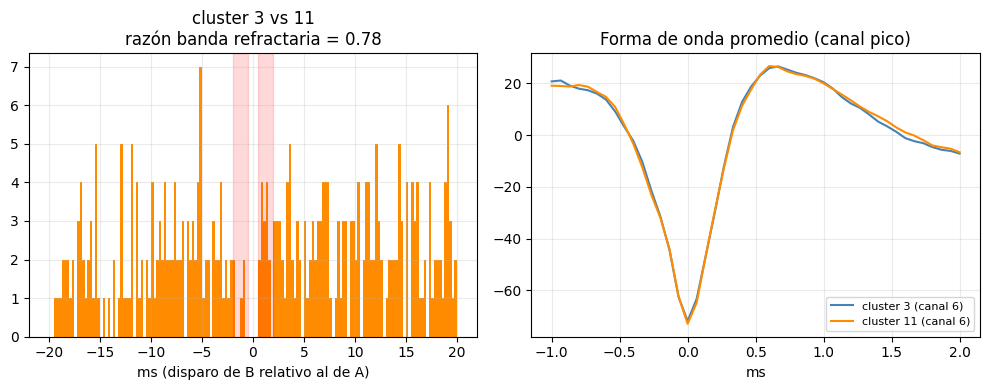

cluster 3 vs 11: banda poblada -> dos neuronas distintas



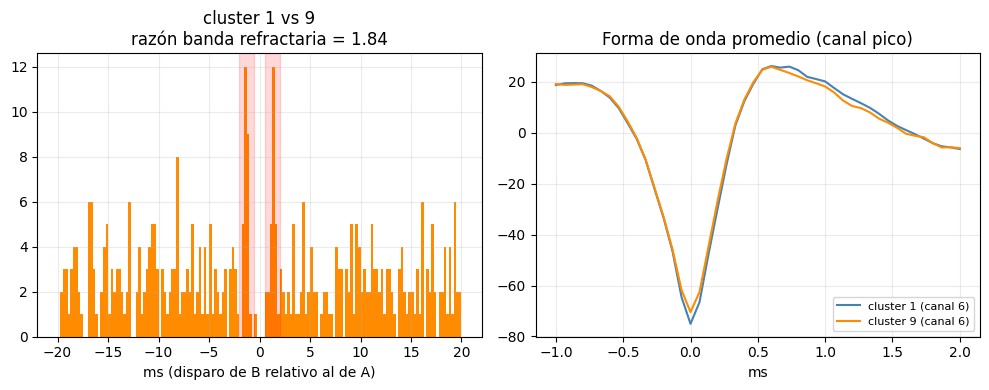

cluster 1 vs 9: banda poblada -> dos neuronas distintas



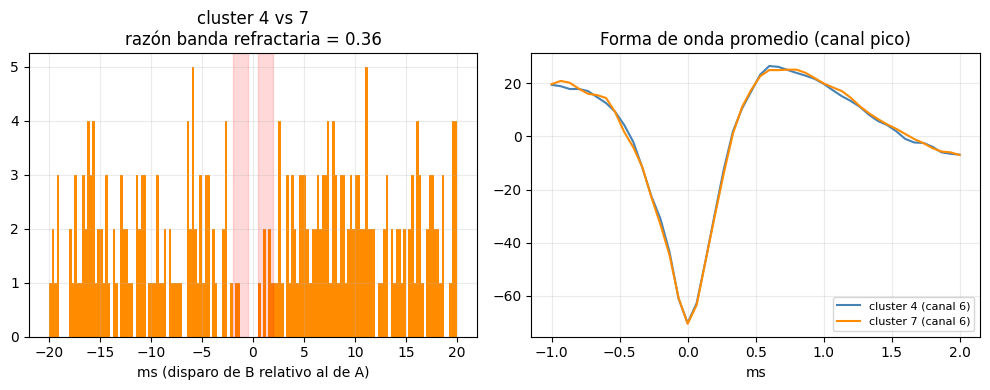

cluster 4 vs 7: banda poblada -> dos neuronas distintas



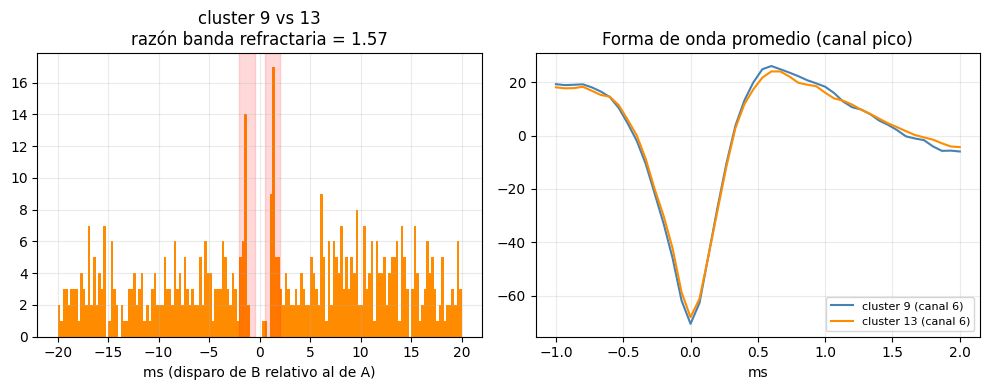

cluster 9 vs 13: banda poblada -> dos neuronas distintas



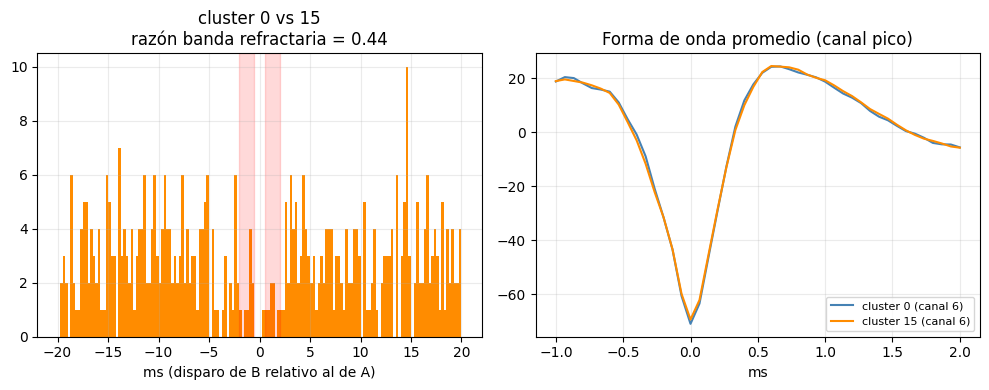

cluster 0 vs 15: banda poblada -> dos neuronas distintas



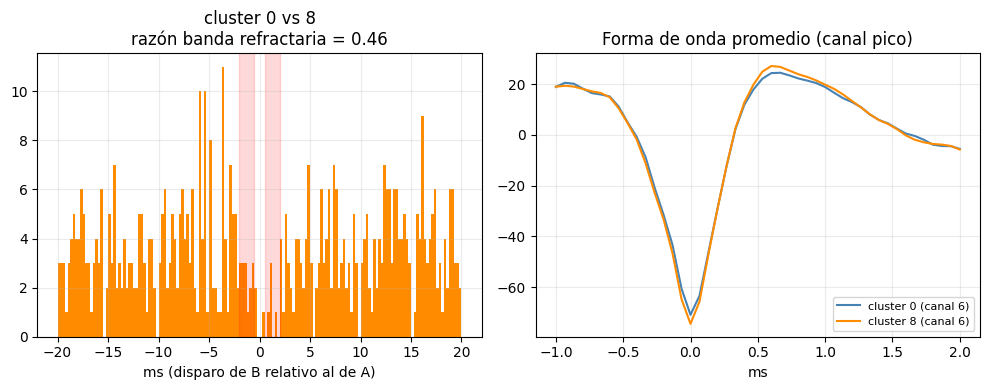

cluster 0 vs 8: banda poblada -> dos neuronas distintas



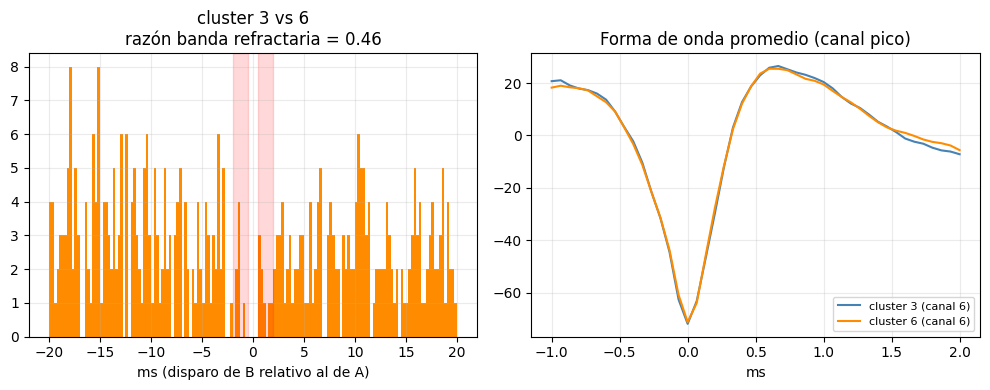

cluster 3 vs 6: banda poblada -> dos neuronas distintas



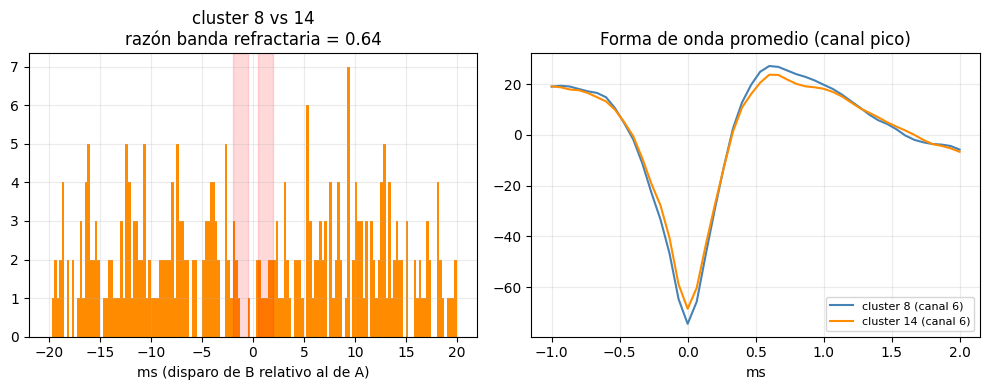

cluster 8 vs 14: banda poblada -> dos neuronas distintas



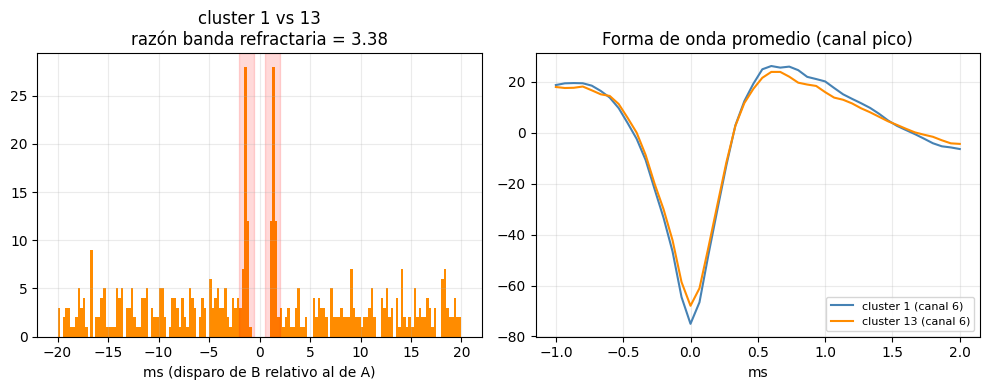

cluster 1 vs 13: banda poblada -> dos neuronas distintas



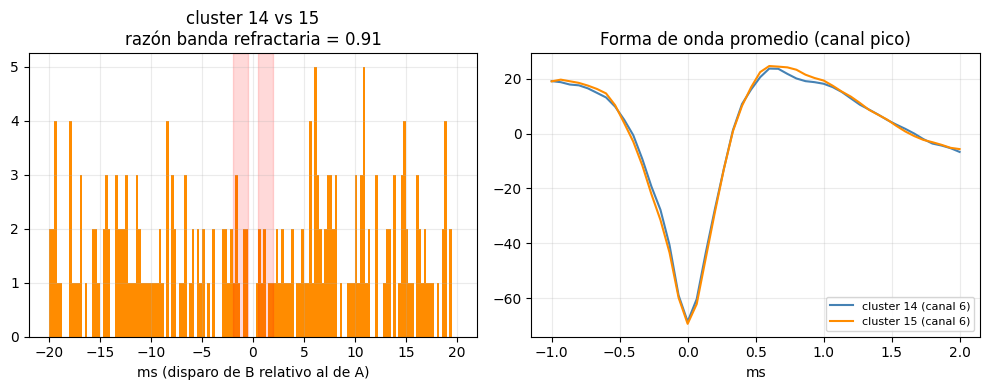

cluster 14 vs 15: banda poblada -> dos neuronas distintas



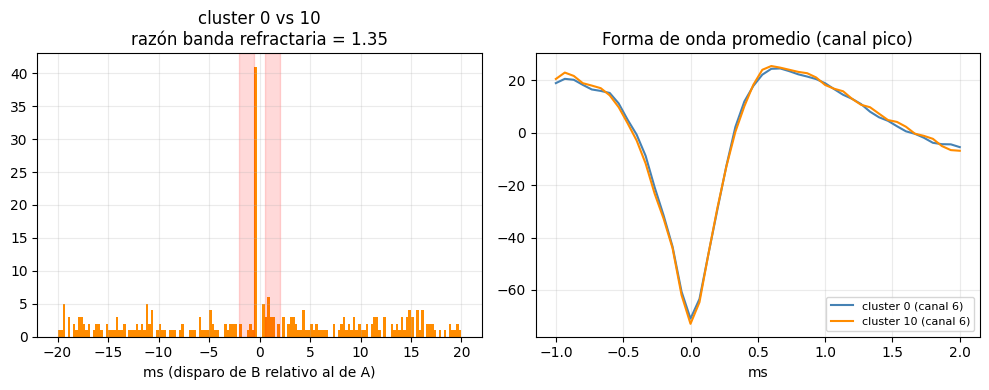

cluster 0 vs 10: banda poblada -> dos neuronas distintas



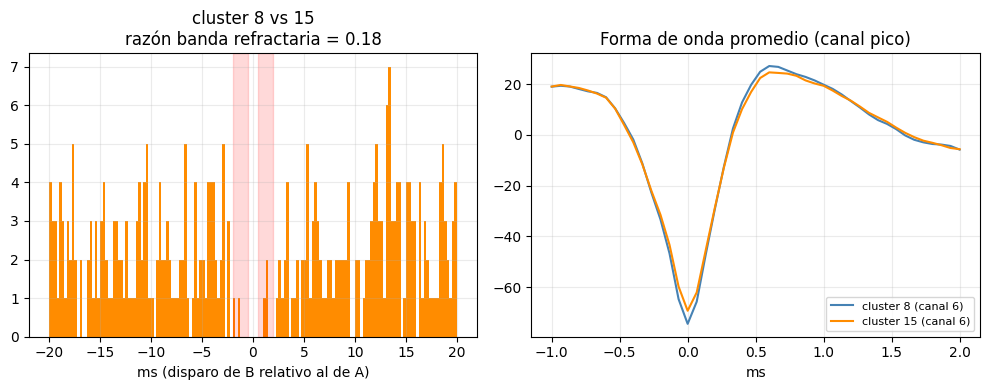

cluster 8 vs 15: banda vacía -> misma neurona, PERO revisa si las formas de onda coinciden



In [ ]:
from itertools import combinations
from scipy.spatial.distance import pdist, squareform

# centroide de cada cluster en el espacio de características ESTANDARIZADO
# (el mismo X_std que usaste para correr K-means)
centroides_cluster = {}
for cl in clusters_unicos:
    mask = df_ruidosa_limpio["cluster"].to_numpy() == cl
    centroides_cluster[cl] = X_std[mask].mean(axis=0)

ids = list(centroides_cluster.keys())
matriz_centroides = np.array([centroides_cluster[cl] for cl in ids])
distancias = squareform(pdist(matriz_centroides))  # distancia euclidiana entre centroides

# candidatas: pares con distancia por debajo de un percentil bajo (ajusta el umbral
# según la escala de tus datos, por ejemplo el percentil 10 de todas las distancias)
dist_pares = [(ids[i], ids[j], distancias[i, j])
              for i, j in combinations(range(len(ids)), 2)]
dist_pares.sort(key=lambda x: x[2])

umbral_cercania = np.percentile([d for _, _, d in dist_pares], 10)
candidatas = [(a, b, d) for a, b, d in dist_pares if d <= umbral_cercania]

print(f"parejas candidatas a ser la misma neurona (distancia \u2264 percentil 10 = {umbral_cercania:.3f}):")
for a, b, d in candidatas:
    print(f"  cluster {a} <-> cluster {b}: distancia = {d:.3f}")

# Obtener los tiempos de disparo que corresponden exactamente a las filas de df_ruidosa_limpio
# 1. Aplicar la primera capa de filtrado (eventos válidos después de la extracción de formas de onda)
tiempos_s_filtrados_formas_onda = tiempos_s[indices_validos_ruidosa]

# 2. Obtener los índices de df_ruidosa que no se eliminaron al crear df_ruidosa_limpio
#    Esto nos permite alinear los tiempos de disparo con las filas de df_ruidosa_limpio
indices_conservados_por_dropna = df_ruidosa.dropna(subset=caracteristicas).index

# 3. Aplicar este segundo filtro a los tiempos de disparo
tiempos_s_alineados_a_limpio = tiempos_s_filtrados_formas_onda[indices_conservados_por_dropna]


# correlograma cruzado + comparación de forma de onda para cada pareja candidata
for a, b, d in candidatas:
    # Ahora, 'tiempos_s_alineados_a_limpio' tiene el mismo número de filas que df_ruidosa_limpio
    # por lo que el indexado booleano funcionará correctamente.
    tiempos_a = tiempos_s_alineados_a_limpio[df_ruidosa_limpio["cluster"].to_numpy() == a]
    tiempos_b = tiempos_s_alineados_a_limpio[df_ruidosa_limpio["cluster"].to_numpy() == b]

    centros_ms, conteos = correlograma_cruzado(tiempos_a, tiempos_b, ventana_ms=20, bin_ms=0.25)
    razon_cruzada = razon_banda_vacia(centros_ms, conteos)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.bar(centros_ms, conteos, width=0.25, color="darkorange", edgecolor="none")
    ax1.axvspan(0.5, 2, color="red", alpha=0.15)
    ax1.axvspan(-2, -0.5, color="red", alpha=0.15)
    ax1.set_title(f"cluster {a} vs {b}\nrazón banda refractaria = {razon_cruzada:.2f}")
    ax1.set_xlabel("ms (disparo de B relativo al de A)")

    # comparación de forma de onda promedio (trampa del falso positivo)
    for cl, color in [(a, "steelblue"), (b, "darkorange")]:
        idx_cl = df_ruidosa_limpio.index[df_ruidosa_limpio["cluster"] == cl].to_numpy()
        formas_cl = formas_onda_ruidosa[idx_cl]
        canal_pico_cl = np.array([int(np.argmin(formas_cl[i]) // formas_cl.shape[2]) for i in range(len(idx_cl))])
        canal_moda = int(pd.Series(canal_pico_cl).mode().iloc[0])
        traza_media = formas_cl[:, canal_moda, :].mean(axis=0)
        ax2.plot(tiempo_ventana_ms_ruidosa, traza_media, color=color, label=f"cluster {cl} (canal {canal_moda})")

    ax2.set_title("Forma de onda promedio (canal pico)")
    ax2.set_xlabel("ms")
    ax2.legend(fontsize=8)

    fig.tight_layout()
    plt.show()

    veredicto = "banda vacía -> misma neurona, PERO revisa si las formas de onda coinciden" \
        if razon_cruzada < 0.3 else "banda poblada -> dos neuronas distintas"
    print(f"cluster {a} vs {b}: {veredicto}\n")

**P6.**

**Selección múltiple.** Dos grupos tienen el correlograma cruzado con la banda de 0,5 a 2 ms vacía.
Lo primero que hay que sospechar es que

- **a)** son dos neuronas vecinas distintas
- **Respuesta b) son la misma neurona, partida en dos grupos**
- **c)** están conectadas por una sinapsis
- **d)** los dos son artefactos

**Abierta.** Busquen una pareja así en sus datos. Muestren la figura, comparen las dos formas de onda
promedio y decidan si las fusionan o no. Justifiquen la decisión: la banda vacía sola no alcanza.

*Su respuesta:*
La pareja cluster 8 vs 15 tiene una razón = 0.182, banda vacía. Abajo se encuentra el análisis de estos dos clusters, el análisis cualitativo es bastante básico pero muestra una forma muy similar de onda que es posible corroborar con el análisis cuantitativo, lo que resulta en en una correlación entre formas de onda de 0.99. Esta información nos permite justificar la desición de fusionarlas.

In [ ]:
for a, b, d in candidatas:
    tiempos_a = tiempos_s_alineados_a_limpio[df_ruidosa_limpio["cluster"].to_numpy() == a]
    tiempos_b = tiempos_s_alineados_a_limpio[df_ruidosa_limpio["cluster"].to_numpy() == b]
    centros_ms, conteos = correlograma_cruzado(tiempos_a, tiempos_b, ventana_ms=20, bin_ms=0.25)
    razon = razon_banda_vacia(centros_ms, conteos)
    print(f"cluster {a} vs {b}: razón = {razon:.3f}" + ("  <-- CANDIDATA: banda vacía" if razon < 0.3 else ""))

cluster 3 vs 11: razón = 0.778
cluster 1 vs 9: razón = 1.843
cluster 4 vs 7: razón = 0.360
cluster 9 vs 13: razón = 1.569
cluster 0 vs 15: razón = 0.443
cluster 0 vs 8: razón = 0.460
cluster 3 vs 6: razón = 0.457
cluster 8 vs 14: razón = 0.644
cluster 1 vs 13: razón = 3.376
cluster 14 vs 15: razón = 0.909
cluster 0 vs 10: razón = 1.353
cluster 8 vs 15: razón = 0.182  <-- CANDIDATA: banda vacía


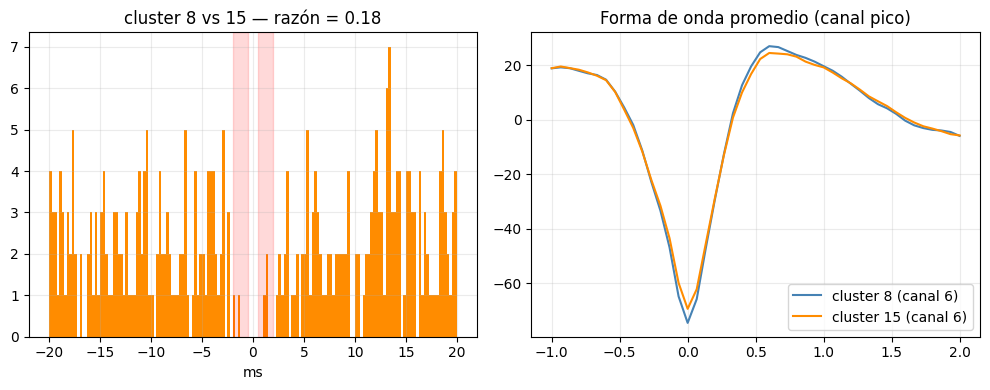

In [ ]:
a, b = 8, 15  # los que salieron con razón más baja

tiempos_a = tiempos_s_alineados_a_limpio[df_ruidosa_limpio["cluster"].to_numpy() == a]
tiempos_b = tiempos_s_alineados_a_limpio[df_ruidosa_limpio["cluster"].to_numpy() == b]
centros_ms, conteos = correlograma_cruzado(tiempos_a, tiempos_b, ventana_ms=20, bin_ms=0.25)
razon = razon_banda_vacia(centros_ms, conteos)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(centros_ms, conteos, width=0.25, color="darkorange")
ax1.axvspan(0.5, 2, color="red", alpha=0.15)
ax1.axvspan(-2, -0.5, color="red", alpha=0.15)
ax1.set_title(f"cluster {a} vs {b} — razón = {razon:.2f}")
ax1.set_xlabel("ms")

for cl, color in [(a, "steelblue"), (b, "darkorange")]:
    idx_cl = df_ruidosa_limpio.index[df_ruidosa_limpio["cluster"] == cl].to_numpy()
    formas_cl = formas_onda_ruidosa[idx_cl]
    canal_pico_cl = np.array([int(np.argmin(formas_cl[i]) // formas_cl.shape[2]) for i in range(len(idx_cl))])
    canal_moda = int(pd.Series(canal_pico_cl).mode().iloc[0])
    traza_media = formas_cl[:, canal_moda, :].mean(axis=0)
    ax2.plot(tiempo_ventana_ms_ruidosa, traza_media, color=color, label=f"cluster {cl} (canal {canal_moda})")
ax2.set_title("Forma de onda promedio (canal pico)")
ax2.legend()
plt.tight_layout()
plt.show()

In [ ]:
idx_a = df_ruidosa_limpio.index[df_ruidosa_limpio["cluster"] == a].to_numpy()
idx_b = df_ruidosa_limpio.index[df_ruidosa_limpio["cluster"] == b].to_numpy()

formas_a = formas_onda_ruidosa[idx_a]
formas_b = formas_onda_ruidosa[idx_b]

canal_pico_a = int(pd.Series([int(np.argmin(formas_a[i]) // formas_a.shape[2]) for i in range(len(idx_a))]).mode().iloc[0])
canal_pico_b = int(pd.Series([int(np.argmin(formas_b[i]) // formas_b.shape[2]) for i in range(len(idx_b))]).mode().iloc[0])

traza_a = formas_a[:, canal_pico_a, :].mean(axis=0)
traza_b = formas_b[:, canal_pico_b, :].mean(axis=0)

print(f"cluster {a}: canal pico = {canal_pico_a}, amplitud valle = {traza_a.min():.1f} µV, n = {len(idx_a)}")
print(f"cluster {b}: canal pico = {canal_pico_b}, amplitud valle = {traza_b.min():.1f} µV, n = {len(idx_b)}")

if canal_pico_a == canal_pico_b:
    correlacion = np.corrcoef(traza_a, traza_b)[0, 1]
    print(f"mismo canal pico -> correlación entre formas de onda: {correlacion:.3f}")
else:
    print(f"canal pico distinto (A={canal_pico_a} vs B={canal_pico_b}) -> ya es una pista de que podrían ser dos neuronas vecinas, no la misma")

cluster 8: canal pico = 6, amplitud valle = -74.5 µV, n = 1534
cluster 15: canal pico = 6, amplitud valle = -69.3 µV, n = 1270
mismo canal pico -> correlación entre formas de onda: 0.999


---
# 7 · Curar: ponerle una etiqueta a cada grupo

Ahora júntenlo todo. Cada grupo recibe **una** de estas cuatro etiquetas.

**`noise`.** No es actividad neuronal. Se reconoce porque la forma de onda no parece un potencial de
acción (demasiados picos, duración fuera de rango) o porque **no cae con la distancia**: aparece con
la misma amplitud en toda la sonda. Se descarta y no se vuelve a mirar.

**`non-somatic`.** Es actividad neuronal, pero la onda es predominantemente positiva, lo que indica
que se está registrando un axón o una dendrita y no la zona donde nace el potencial de acción. Se
puede analizar, pero hay que decir en la figura que es no somática.

**`mua`.** Son potenciales de acción de verdad, pero de más de una neurona, o de una neurona a la que
le faltan disparos. Se reconoce por las violaciones del refractario, por la distribución de amplitudes
cortada por el umbral, o por tener muy pocos disparos. **La MUA sirve para medir actividad de la
población, pero no sirve para decir "esta neurona responde a este estímulo".**

**`good`.** Pasa todo. Es una neurona, aislada, completa.

Sobre el vocabulario, una precisión que importa en insectos: **no se debe hablar de "unidades
somáticas"**. Las neuronas de insecto son en su mayoría unipolares, con el soma en la corteza celular
de la periferia, fuera del neuropilo, y ese soma normalmente no genera el potencial de acción
propagado: la zona donde nace el disparo está en el neurito, ya dentro del neuropilo. Por eso la
distinción de bombcell es sobre la **forma de la onda registrada**, no sobre qué parte anatómica se
supone que uno está tocando.

### ✏️ Ejercicio 7

**a)** Apliquen las fusiones que decidieron en la sección 6.

**b)** Asignen una de las cuatro etiquetas a cada grupo resultante.

**c)** Hagan una figura resumen: para cada grupo etiquetado `good` o `non-somatic`, su forma de onda
promedio en los 16 sitios y su autocorrelograma.

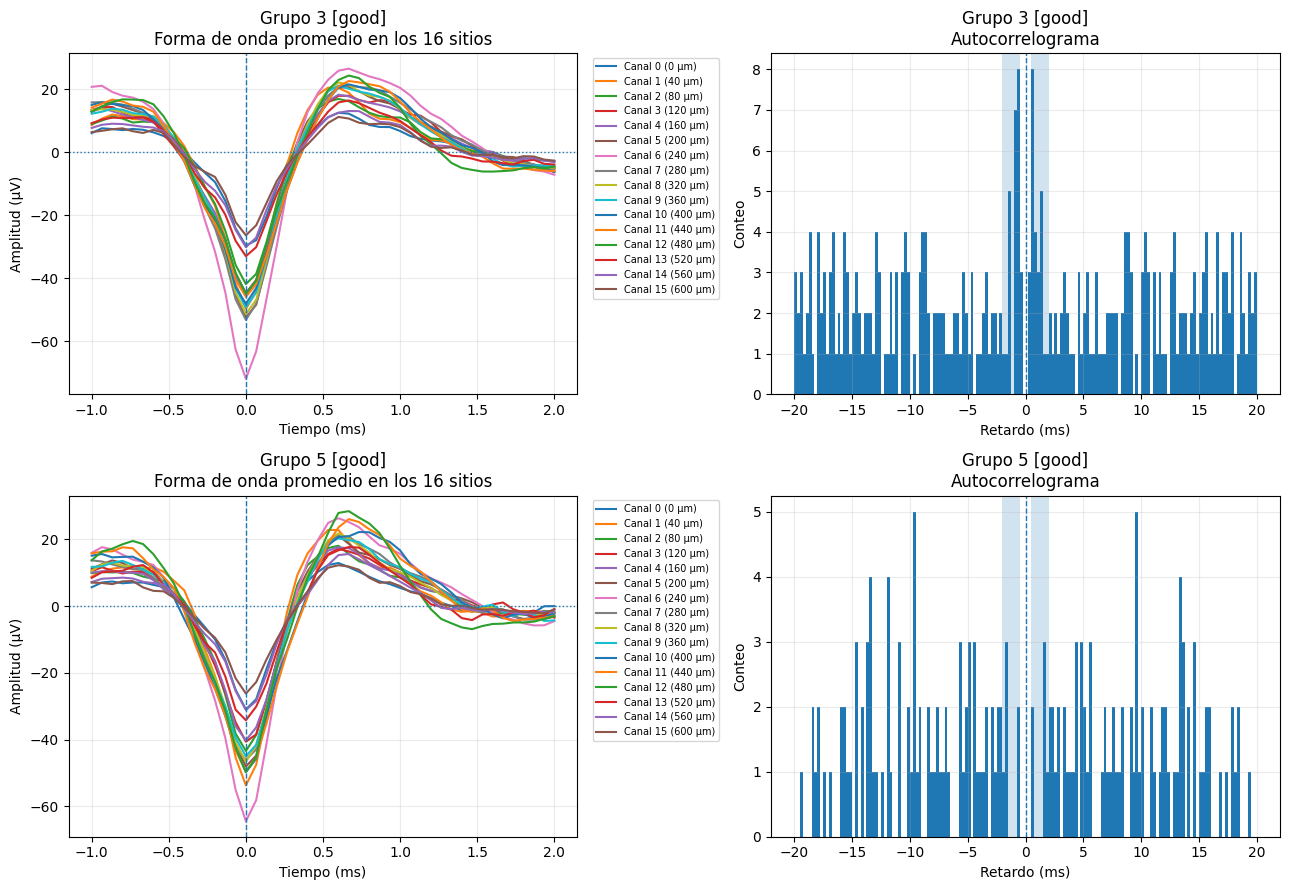


TABLA FINAL DE CURACIÓN Y ETIQUETADO


,cluster,n_picos,n_valles,duracion_onda_us,pendiente_espacial,razon_pico_valle,es_no_somatica,frac_violaciones_refractario,frac_disparos_faltantes,n_disparos,es_neuronal,etiqueta
0,2,2,2,600.000000,-0.006338,0.371950,False,0.018615,2.899756e-09,1344,True,mua
1,3,2,1,666.666667,-0.006364,0.368735,False,0.012704,1.214100e-24,1103,True,good
2,9,3,3,600.000000,-0.006400,0.368969,False,0.023896,1.014913e-02,1382,False,noise
3,8_15,2,1,600.000000,-0.006327,0.359809,False,0.013914,6.606227e-01,2804,True,mua
4,12,2,5,666.666667,-0.006490,0.363944,False,0.002699,1.266240e-11,742,False,noise
5,0,2,1,666.666667,-0.006391,0.344588,False,0.023446,9.190615e-01,1835,True,mua
6,6,2,1,600.000000,-0.006355,0.357680,False,0.016500,6.134850e-03,1698,True,mua
7,11,3,1,600.000000,-0.006388,0.365571,False,0.014706,1.596192e-03,1293,False,noise
8,13,3,1,666.666667,-0.006378,0.352635,False,0.066486,1.093631e-07,1475,False,noise
9,7,4,1,600.000000,-0.006385,0.356910,False,0.009355,5.228489e-04,1070,False,noise


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================================
# 1) FUSIÓN DE GRUPOS: combinar EVENTOS de los clusters 8 y 15
# ============================================================================

def fusionar_grupos(df_eventos, clusters_a_fusionar, id_grupo_fusionado,
                    col_cluster="cluster"):

    df_fusionado = df_eventos.copy()

    df_fusionado[col_cluster] = df_fusionado[col_cluster].astype(object)

    mascara = df_fusionado[col_cluster].isin(clusters_a_fusionar)

    df_fusionado.loc[mascara, col_cluster] = id_grupo_fusionado

    return df_fusionado


# ============================================================================
# 2) RECALCULAR MÉTRICAS DEL GRUPO FUSIONADO
# ============================================================================

def recalcular_metricas_grupo(
    df_grupo,
    formas_onda_grupo,
    tiempos_s_grupo,
    tiempo_ventana_ms,
    y_um,
    umbral_deteccion_uv,
    fs=15000
):

    tabla_grupo = calcular_metricas_calidad(
        df_eventos=df_grupo,
        formas_onda=formas_onda_grupo,
        tiempo_ventana_ms=tiempo_ventana_ms,
        y_um=y_um,
        tiempos_s=tiempos_s_grupo,
        umbral_deteccion_uv=umbral_deteccion_uv,
        fs=fs
    )

    return tabla_grupo.iloc[0].to_dict()


# ============================================================================
# 3) INDICADORES BOOLEANOS
# ============================================================================

def calcular_indicadores(fila):

    indicador_noise = (
        (fila["n_picos"] > 2)
        or
        (fila["n_valles"] > 2)
        or
        not (100 <= fila["duracion_onda_us"] <= 1150)
        or
        (fila["pendiente_espacial"] >= -0.004)
    )

    indicador_non_somatic = (
        (not indicador_noise)
        and
        (fila["razon_pico_valle"] > 0.8)
    )

    indicador_mua = (
        (fila["frac_violaciones_refractario"] >= 0.015)
        or
        (fila["frac_disparos_faltantes"] >= 0.20)
        or
        (fila["n_disparos"] < 300)
    )

    indicador_good = (
        (fila["n_picos"] <= 2)
        and
        (fila["n_valles"] <= 2)
        and
        (100 <= fila["duracion_onda_us"] <= 1150)
        and
        (fila["pendiente_espacial"] < -0.004)
        and
        (fila["frac_violaciones_refractario"] < 0.015)
        and
        (fila["frac_disparos_faltantes"] < 0.20)
        and
        (fila["n_disparos"] >= 300)
        and
        (fila["razon_pico_valle"] <= 0.8)
    )

    return (
        indicador_noise,
        indicador_non_somatic,
        indicador_mua,
        indicador_good
    )


# ============================================================================
# 4) ASIGNAR UNA ÚNICA ETIQUETA
# ============================================================================

def asignar_etiqueta(
    indicador_noise,
    indicador_non_somatic,
    indicador_mua,
    indicador_good
):

    # Prioridad:
    # 1. noise
    # 2. non-somatic
    # 3. mua
    # 4. good

    if indicador_noise:
        return "noise"

    elif indicador_non_somatic:
        return "non-somatic"

    elif indicador_mua:
        return "mua"

    elif indicador_good:
        return "good"

    else:
        return "revisar_caso"


# ============================================================================
# 5) FIGURA RESUMEN
#    Forma de onda promedio en los 16 sitios + autocorrelograma
# ============================================================================

def figura_resumen_grupos(
    tabla_grupos,
    df_eventos,
    formas_onda,
    tiempos_s,
    tiempo_ventana_ms,
    y_um,
    col_cluster="cluster",
    ventana_ms=20,
    bin_ms=0.25
):

    # ------------------------------------------------------------
    # Seleccionar solamente good y non-somatic
    # ------------------------------------------------------------

    seleccion = tabla_grupos[
        tabla_grupos["etiqueta"].isin(["good", "non-somatic"])
    ]

    n = len(seleccion)

    if n == 0:
        print("Ningún grupo quedó etiquetado como 'good' o 'non-somatic'.")
        return None

    # ------------------------------------------------------------
    # Crear figura
    # ------------------------------------------------------------

    fig, axes = plt.subplots(
        n,
        2,
        figsize=(13, 4.5 * n),
        squeeze=False
    )

    tiempos_s = np.asarray(tiempos_s)

    # ------------------------------------------------------------
    # Recorrer cada grupo
    # ------------------------------------------------------------

    for fila_idx, (_, info) in enumerate(seleccion.iterrows()):

        gid = info[col_cluster]

        idx_grupo = df_eventos.index[
            df_eventos[col_cluster] == gid
        ].to_numpy()

        # ========================================================
        # FORMA DE ONDA PROMEDIO EN LOS 16 SITIOS
        # ========================================================

        forma_promedio = formas_onda[idx_grupo].mean(axis=0)

        ax_wf = axes[fila_idx, 0]

        for canal in range(forma_promedio.shape[0]):

            ax_wf.plot(
                tiempo_ventana_ms,
                forma_promedio[canal],
                linewidth=1.5,
                label=f"Canal {canal} ({y_um[canal]:.0f} µm)"
            )

        ax_wf.axvline(
            0,
            linestyle="--",
            linewidth=1
        )

        ax_wf.axhline(
            0,
            linestyle=":",
            linewidth=1
        )

        ax_wf.set_xlabel("Tiempo (ms)")
        ax_wf.set_ylabel("Amplitud (µV)")

        ax_wf.set_title(
            f"Grupo {gid} [{info['etiqueta']}]\n"
            "Forma de onda promedio en los 16 sitios"
        )

        ax_wf.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=7
        )

        ax_wf.grid(
            True,
            alpha=0.25
        )

        # ========================================================
        # AUTOCORRELOGRAMA
        # ========================================================

        tiempos_grupo = tiempos_s[idx_grupo]

        lags_ms, conteo = autocorrelograma(
            tiempos_grupo,
            ventana_ms=ventana_ms,
            bin_ms=bin_ms
        )

        ax_ac = axes[fila_idx, 1]

        ax_ac.bar(
            lags_ms,
            conteo,
            width=bin_ms
        )

        ax_ac.axvspan(
            0.5,
            2.0,
            alpha=0.2
        )

        ax_ac.axvspan(
            -2.0,
            -0.5,
            alpha=0.2
        )

        ax_ac.axvline(
            0,
            linestyle="--",
            linewidth=1
        )

        ax_ac.set_xlabel("Retardo (ms)")
        ax_ac.set_ylabel("Conteo")

        ax_ac.set_title(
            f"Grupo {gid} [{info['etiqueta']}]\n"
            "Autocorrelograma"
        )

        ax_ac.grid(
            True,
            alpha=0.25
        )

    fig.tight_layout()

    plt.show()

    return fig


# ============================================================================
# 6) FUNCIÓN PRINCIPAL
# ============================================================================

def curar_y_etiquetar_grupos(
    df_ruidosa_limpio,
    formas_onda_ruidosa,
    tiempos_s_alineados_a_limpio,
    tabla_calidad,
    tiempo_ventana_ms_ruidosa,
    y_um,
    umbral_medio,
    clusters_a_fusionar=(8, 15),
    id_grupo_fusionado="8_15",
    col_cluster="cluster"
):

    # ========================================================================
    # A. FUSIONAR LOS EVENTOS DE LOS CLUSTERS 8 Y 15
    # ========================================================================

    df_fusionado = fusionar_grupos(
        df_eventos=df_ruidosa_limpio,
        clusters_a_fusionar=clusters_a_fusionar,
        id_grupo_fusionado=id_grupo_fusionado,
        col_cluster=col_cluster
    )

    tiempos_s_arr = np.asarray(
        tiempos_s_alineados_a_limpio
    )

    # ========================================================================
    # B. CREAR TABLA DE CALIDAD PARA LOS GRUPOS RESULTANTES
    # ========================================================================

    filas_tabla = []

    grupos_resultantes = df_fusionado[col_cluster].unique()

    for gid in grupos_resultantes:

        idx_grupo = df_fusionado.index[
            df_fusionado[col_cluster] == gid
        ].to_numpy()

        # --------------------------------------------------------------------
        # GRUPO FUSIONADO 8_15
        # --------------------------------------------------------------------

        if gid == id_grupo_fusionado:

            df_grupo = df_fusionado.loc[idx_grupo]

            formas_onda_grupo = formas_onda_ruidosa[idx_grupo]

            tiempos_s_grupo = tiempos_s_arr[idx_grupo]

            metricas = recalcular_metricas_grupo(
                df_grupo=df_grupo,
                formas_onda_grupo=formas_onda_grupo,
                tiempos_s_grupo=tiempos_s_grupo,
                tiempo_ventana_ms=tiempo_ventana_ms_ruidosa,
                y_um=y_um,
                umbral_deteccion_uv=umbral_medio,
                fs=15000
            )

            fila = metricas

            fila[col_cluster] = id_grupo_fusionado

        # --------------------------------------------------------------------
        # RESTO DE CLUSTERS
        # --------------------------------------------------------------------

        else:

            fila_existente = tabla_calidad[
                tabla_calidad[col_cluster] == gid
            ]

            if len(fila_existente) == 0:
                continue

            fila = fila_existente.iloc[0].to_dict()

        filas_tabla.append(fila)

    tabla_grupos = pd.DataFrame(filas_tabla)

    # ========================================================================
    # C. CALCULAR INDICADORES
    # ========================================================================

    indicadores = tabla_grupos.apply(
        calcular_indicadores,
        axis=1,
        result_type="expand"
    )

    indicadores.columns = [
        "indicador_noise",
        "indicador_non_somatic",
        "indicador_mua",
        "indicador_good"
    ]

    tabla_grupos = pd.concat(
        [
            tabla_grupos.reset_index(drop=True),
            indicadores.reset_index(drop=True)
        ],
        axis=1
    )

    # ========================================================================
    # D. CREAR COLUMNA "etiqueta"
    # ========================================================================

    tabla_grupos["etiqueta"] = tabla_grupos.apply(
        lambda fila: asignar_etiqueta(
            fila["indicador_noise"],
            fila["indicador_non_somatic"],
            fila["indicador_mua"],
            fila["indicador_good"]
        ),
        axis=1
    )

    # ========================================================================
    # E. ELIMINAR LAS COLUMNAS DE INDICADORES
    # ========================================================================

    tabla_grupos = tabla_grupos.drop(
        columns=[
            "indicador_noise",
            "indicador_non_somatic",
            "indicador_mua",
            "indicador_good"
        ]
    )

    # ========================================================================
    # F. FIGURA RESUMEN
    # ========================================================================

    figura = figura_resumen_grupos(
        tabla_grupos=tabla_grupos,
        df_eventos=df_fusionado,
        formas_onda=formas_onda_ruidosa,
        tiempos_s=tiempos_s_alineados_a_limpio,
        tiempo_ventana_ms=tiempo_ventana_ms_ruidosa,
        y_um=y_um,
        col_cluster=col_cluster,
        ventana_ms=20,
        bin_ms=0.25
    )

    # ========================================================================
    # G. MOSTRAR TABLA FINAL
    # ========================================================================

    print("\nTABLA FINAL DE CURACIÓN Y ETIQUETADO")
    display(tabla_grupos)

    return tabla_grupos, figura


# ============================================================================
# 7) DEFINIR y_um
# ============================================================================

y_um = np.sort(
    info_ruidosa["y_um"]
)


# ============================================================================
# 8) EJECUTAR
# ============================================================================

tabla_final, figura_resumen = curar_y_etiquetar_grupos(
    df_ruidosa_limpio=df_ruidosa_limpio,
    formas_onda_ruidosa=formas_onda_ruidosa,
    tiempos_s_alineados_a_limpio=tiempos_s_alineados_a_limpio,
    tabla_calidad=tabla_calidad,
    tiempo_ventana_ms_ruidosa=tiempo_ventana_ms_ruidosa,
    y_um=y_um,
    umbral_medio=umbral_medio
)

**P7.**

**Selección múltiple.** Un grupo tiene la forma de onda promedio con el pico positivo casi tan grande
como el valle (razón pico/valle por encima de 0,8), y todo lo demás en orden. Su etiqueta es

- **a)** `good`
- **b)** `mua`
- **c)** `noise`
- **Respuesta d)`nonsomatic`**

**Abierta.** Escojan **tres** de sus grupos, uno de cada etiqueta distinta, y justifiquen cada
etiqueta nombrando las medidas concretas que la decidieron y sus valores. Una o dos frases por grupo.

*Su respuesta:*
| Cluster | Medidas | Etiqueta | Justificación |
|---|---|---|---|
| 0 | 2 picos, 2 valles; duración = 600 µs; pendiente = −0.00634; violaciones refractarias = 1.86%; 1344 disparos | **mua** | Señal compatible con actividad neuronal, pero las violaciones refractarias superan el 1.5%. |
| 1 | 2 picos, 1 valle; duración = 667 µs; pendiente = −0.00636; violaciones refractarias = 1.27%; 1103 disparos | **good** | Cumple los criterios de forma de onda, duración, decaimiento espacial, refractario y número de disparos. |
| 2 | 3 picos, 3 valles; duración = 600 µs; pendiente = −0.00640; violaciones refractarias = 2.39%; 1382 disparos | **noise** | Presenta más de 2 picos y más de 2 valles, por lo que no cumple el criterio de forma de onda. |

---
# 8 · Verificación contra la verdad oculta

Los datos son sintéticos, así que existe la respuesta. El módulo `verificacion.py` la tiene guardada y
la compara con la suya sin mostrársela.

```python
import verificacion as v
v.usar("taller2_ruidosa.h5")
v.verificar_deteccion(tiempos)              # precisión, exhaustividad, F1
v.verificar_canal_pico(tiempos, canales)    # ¿acertaron dónde está cada neurona?
v.verificar_unidades(tiempos, grupos)       # matriz de confusión
v.verificar_curacion(tiempos, grupos, etiquetas)   # ¿acertaron las etiquetas?
```

Los nombres de arriba son los de este ejemplo, no una exigencia: pásenle lo que hayan calculado
ustedes. `tiempos` son los instantes de sus detecciones en segundos, `canales` el canal pico de cada
una, `grupos` el número de grupo que les asignó K-means, y `etiquetas` un diccionario que le asigna a
cada número de grupo una de las cuatro palabras: `{0: "good", 1: "mua", ...}`.

Presten atención a la última línea que imprime `verificar_deteccion`: **qué fracción de lo que
conservaron viene de una neurona que se puede identificar una por una.** Antes de curar, buena parte
de sus detecciones son actividad multiunitaria y artefactos, así que ese número es bajo aunque su
detector sea perfecto. Es la medida de para qué sirvió curar, y es el resultado central de la primera
mitad del taller.

La exhaustividad, por su parte, se mide sólo sobre las unidades bien aisladas. Los disparos de las
neuronas lejanas llegan casi todos por debajo del umbral: no son detectables, y contarlos como fallas
no diría nada sobre su detector.

### ✏️ Ejercicio 8

**a)** Corran las cuatro verificaciones.

**b)** Vuelvan a correr `verificar_deteccion`, pero pasándole **sólo** los disparos de los grupos que
ustedes NO etiquetaron como `noise` ni como `mua`. Es decir, lo que de verdad se llevarían al
análisis de la tercera parte.

In [ ]:
# ✏️ Ejercicio 8
import verificacion as v

# ============================================================
# 1. CARGAR LA VERDAD OCULTA
# ============================================================

v.usar("taller2_ruidosa.h5")


# ============================================================
# 2. VERIFICACIÓN DE DETECCIÓN
#    Todas las detecciones originales
# ============================================================

v.verificar_deteccion(
    tiempos_s
)


# ============================================================
# 3. VERIFICACIÓN DEL CANAL PICO
# ============================================================

v.verificar_canal_pico(
    tiempos_s,
    canales_pico
)


# ============================================================
# 4. VERIFICACIÓN DE UNIDADES
#    Clusters originales de K-means
# ============================================================

grupos = df_ruidosa_limpio["cluster"].to_numpy()

v.verificar_unidades(
    tiempos_s_alineados_a_limpio,
    grupos
)


# ============================================================
# 5. CREAR GRUPOS FINALES
#    Fusionar 8 y 15 → 16
# ============================================================

df_ruidosa_fusionado = fusionar_grupos(
    df_eventos=df_ruidosa_limpio,
    clusters_a_fusionar=(8, 15),
    id_grupo_fusionado=16,
    col_cluster="cluster"
)


# ============================================================
# 6. CREAR DICCIONARIO DE ETIQUETAS
# ============================================================

etiquetas = dict(
    zip(
        tabla_final["cluster"],
        tabla_final["etiqueta"]
    )
)

# La tabla final todavía tiene "8_15" como nombre del grupo.
# Para la verificación lo cambiamos a 16.

etiquetas[16] = etiquetas.pop("8_15")


# ============================================================
# 7. VERIFICACIÓN DE CURACIÓN
# ============================================================

grupos_finales = df_ruidosa_fusionado["cluster"].to_numpy()

v.verificar_curacion(
    tiempos_s_alineados_a_limpio,
    grupos_finales,
    etiquetas
)

Verificación configurada con: taller2_ruidosa.h5
  detectados 19077
  verdaderos positivos 18782   falsos positivos 295
  precisión     0.985  ████████████████████████████
  exhaustividad 0.894  █████████████████████████···   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.937  ██████████████████████████··
  faltan 1461 disparos de unidades bien aisladas

  de una unidad identificable  0.645  ██████████████████··········
  ^ esta es la que sube al curar: qué fracción de lo que usted conservó
    viene de una neurona que se puede identificar una por una, y no de
    actividad multiunitaria ni de artefactos.
  sobre 18782 detecciones emparejadas:
  canal exacto        0.672  ███████████████████·········
  a un sitio o menos  0.868  ████████████████████████····
  nota: en la actividad multiunitaria el canal pico es inestable por
  naturaleza, así que no espere acertarle a todo.
  filas = sus grupos, columnas = la verdad

  grupo        U1     U2     U3     U4     U5

0.3333333333333333

In [ ]:
etiquetas = dict(
    zip(
        tabla_final["cluster"],
        tabla_final["etiqueta"]
    )
)

# Seleccionar únicamente grupos que NO sean noise ni mua
grupos_validos = [
    grupo for grupo, etiqueta in etiquetas.items()
    if etiqueta not in ["noise", "mua"]
]

# Crear máscara sobre los eventos ya alineados
mask_validos = df_ruidosa_fusionado["cluster"].isin(grupos_validos).to_numpy()

# Tiempos de los disparos que sí entran al análisis
tiempos_validos = tiempos_s_alineados_a_limpio[mask_validos]

# La tabla final todavía tiene "8_15" como nombre del grupo.
# Para la verificación lo cambiamos a 16.

# Aseguramos que la clave '8_15' exista antes de intentar usar .pop()
if "8_15" in etiquetas:
    etiquetas[16] = etiquetas.pop("8_15")


# Volver a verificar la detección
v.verificar_deteccion(tiempos_validos)

  detectados 1658
  verdaderos positivos 1658   falsos positivos 0
  precisión     1.000  ████████████████████████████
  exhaustividad 0.113  ███·························   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.202  ██████······················
  faltan 12210 disparos de unidades bien aisladas

  de una unidad identificable  0.934  ██████████████████████████··
  ^ esta es la que sube al curar: qué fracción de lo que usted conservó
    viene de una neurona que se puede identificar una por una, y no de
    actividad multiunitaria ni de artefactos.


{'precision': 1.0,
 'exhaustividad': np.float64(0.11251635412123855),
 'f1': np.float64(0.2022736181889455),
 'util': 0.9336550060313631}

**P8.**

**Selección múltiple.** La fracción "de una unidad identificable" sube cuando vuelven a correr
`verificar_deteccion` sólo con los grupos que no marcaron `mua` ni `noise`. Sube porque

- **a)** se detectan más disparos que antes
- **Respuesta b) sale del conteo lo que no viene de una neurona identificable una por una**
- **c)** mejora la precisión de la detección
- **d)** el umbral se recalcula sobre menos datos

**Abierta.** Digan cuánto subió esa fracción y cuántas unidades `good` recuperaron de las que había.
Miren la matriz de confusión y digan qué les pasó a las que no recuperaron: ¿las fusionaron, las
partieron o las descartaron?

*Su respuesta:*
Antes de curar: 0.645 = 64.5 %
Después de curar: 0.934 = 93.4 %

De las 8 unidades verdaderas bien aisladas, solo 2 fueron recuperadas como grupos conservados (U1 y U3). Las demás principalmente fueron partidas entre varios clusters y/o quedaron dentro de clusters que fueron descartados como noise o mua. El caso de U7 además se vio afectado por la fusión de los grupos 8 y 15, cuyo grupo resultante terminó siendo descartado como mua.

Esto explica por qué la fracción de actividad identificable subió tanto (28.9 puntos porcentuales), pero a costa de perder una gran parte de las unidades bien aisladas disponibles para el análisis posterior.


---
# Tercera parte · Del tren de disparos a la figura

De aquí en adelante trabajan **sólo con los grupos etiquetados `good`**. Los `non-somatic` los pueden
incluir si los marcan como tales en la figura. Los `mua` y los `noise` quedan fuera.

---
# 9 · Raster y PSTH

El registro trae el grupo `estimulos`, con el instante de inicio de cada ensayo y su condición (A, B o
C). Cada ensayo dura 3 s: 1 s antes del estímulo, 0,5 s de estímulo y 1,5 s después.

El **raster** es la figura más honesta que existe para datos de disparos: un punto por cada potencial
de acción, una fila por ensayo. No promedia nada, así que muestra la variabilidad tal cual es.

El **PSTH** (histograma peri-estímulo) es el raster promediado: se cuentan los disparos en ventanas de
tiempo y se divide por el número de ensayos y por el ancho de la ventana, para obtener una tasa en
hertz. El ancho de la ventana es una decisión suya: muy angosta y la curva es puro ruido, muy ancha y
se pierde el momento en que la respuesta empieza.

### ✏️ Ejercicio 9

**a)** Escriban la función que convierte tiempos absolutos a tiempos relativos al inicio del estímulo
de cada ensayo.

**b)** Hagan el raster de cada unidad `good`, con las tres condiciones separadas por color o por panel,
y la ventana del estímulo marcada.

**c)** Hagan el PSTH de cada unidad y cada condición.

Grupos que se analizarán:
   cluster etiqueta
1        3     good
13       5     good

Número de spikes seleccionados: 1658

Spikes por etiqueta:
etiqueta
good    1658
Name: count, dtype: int64

Contenido de estimulos:
['condicion', 'tiempo_inicio_s']

Atributos de estimulos:
duracion_estimulo_s : 0.5
duracion_post_s : 1.5
duracion_pre_s : 1.0
nota : tiempo_inicio_s marca el inicio del ENSAYO. El estimulo empieza duracion_pre_s despues.

Número de ensayos: 60
Condiciones encontradas: ['A' 'B' 'C']

Número de spikes después de convertir los tiempos: 1535

Número de spikes por condición:
condicion
B    609
A    472
C    454
Name: count, dtype: int64


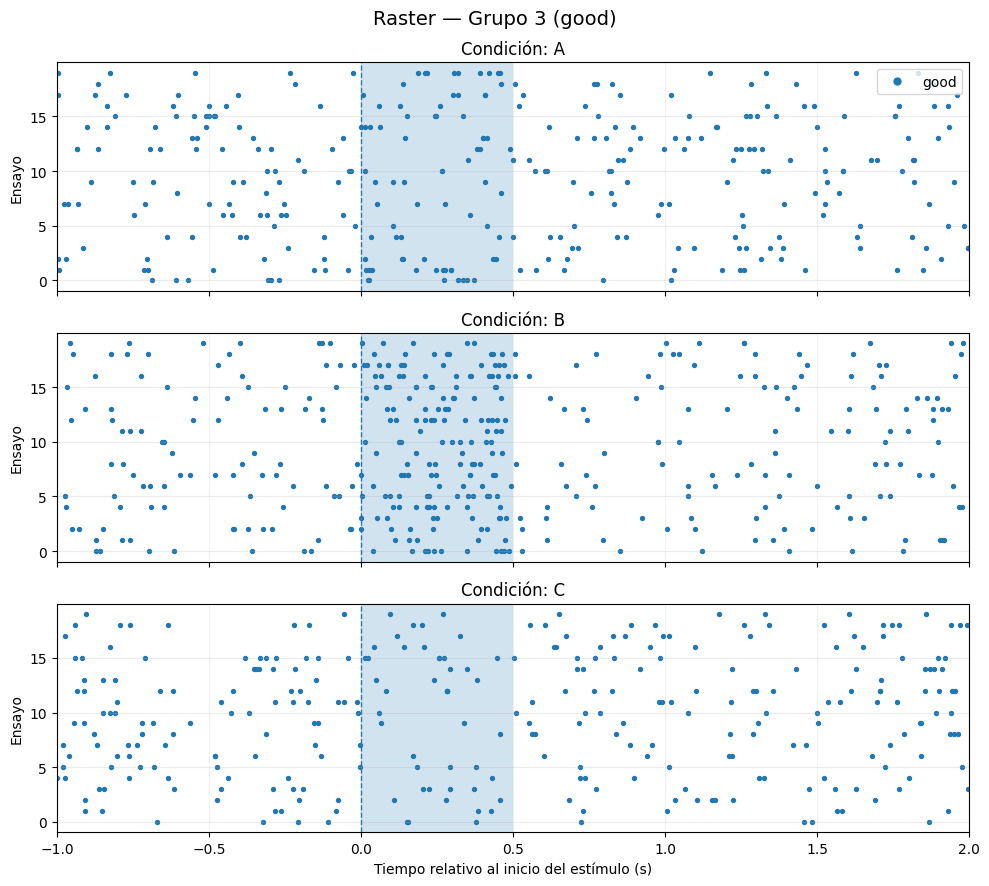

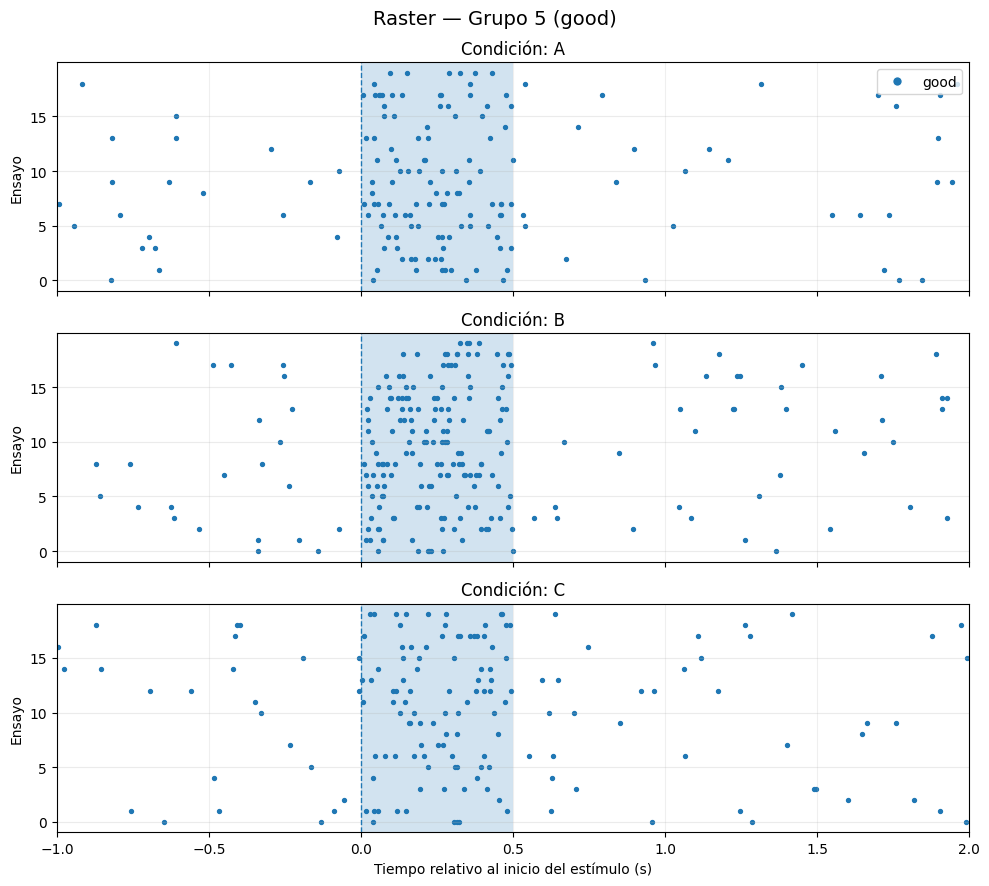

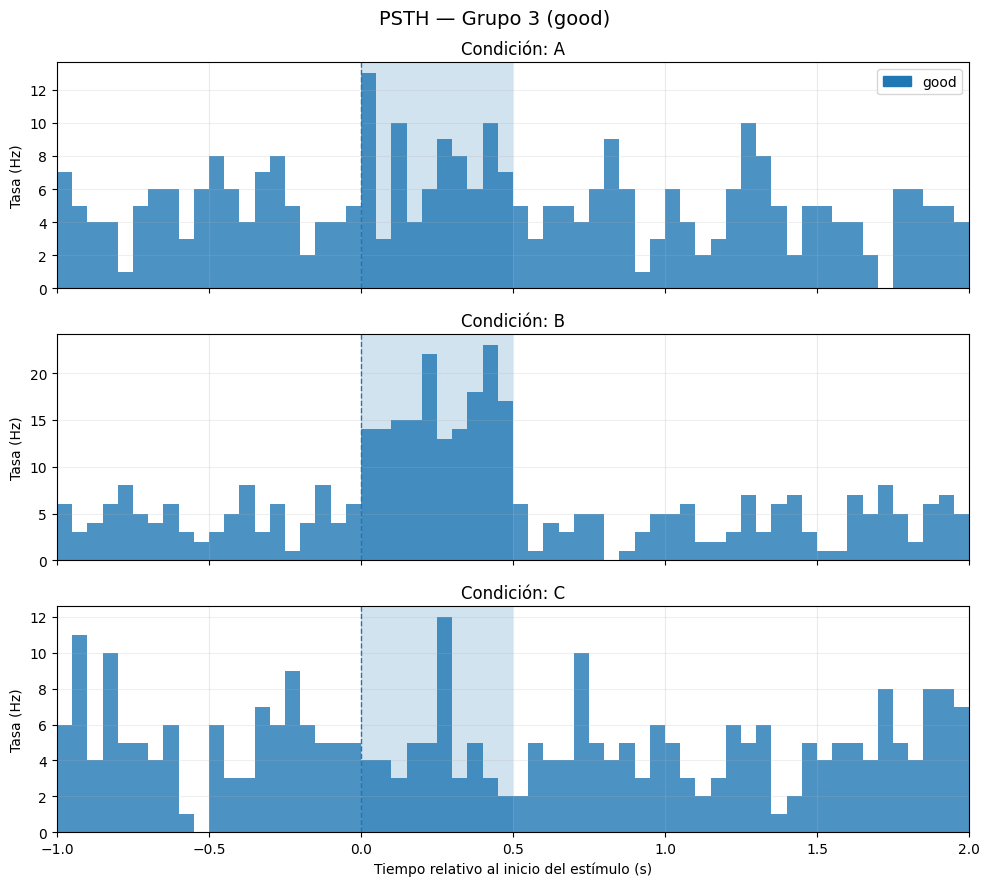

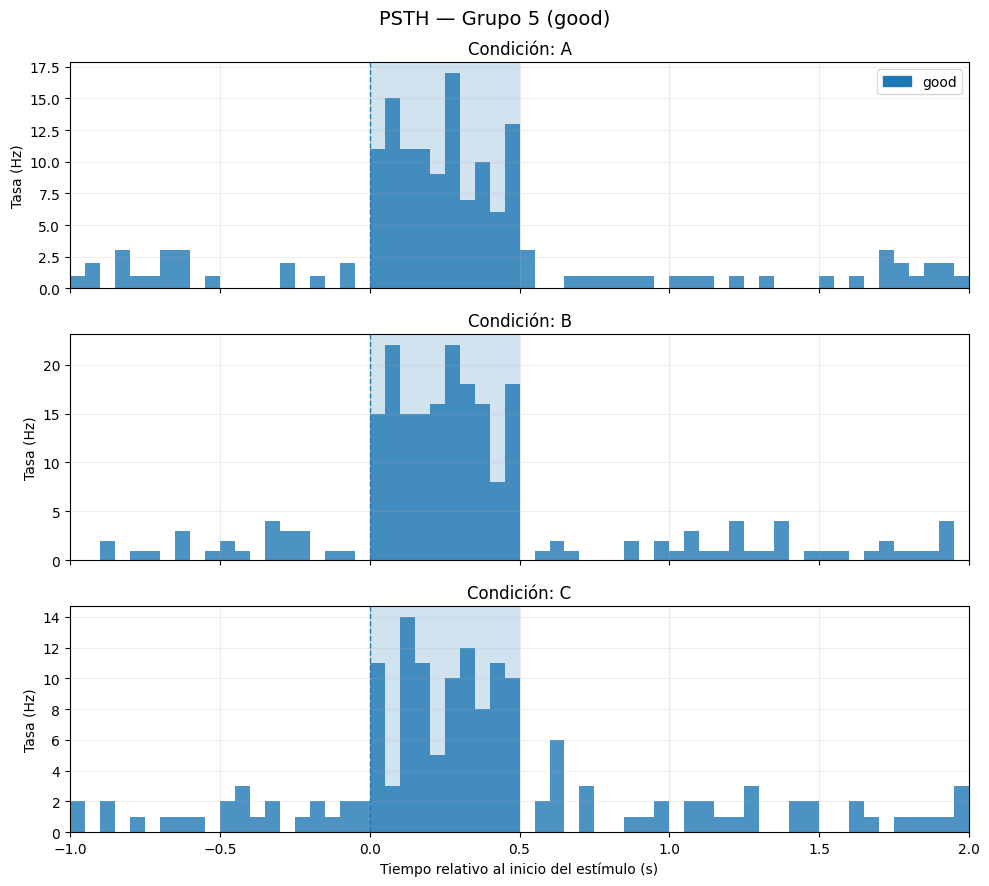

In [ ]:
# ✏️ Ejercicio 9
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py


# ============================================================
# 1. SELECCIONAR ÚNICAMENTE LOS GRUPOS GOOD Y NON-SOMATIC
# ============================================================

# De tabla_final obtenemos qué grupos fueron clasificados como
# "good" o "non-somatic".
grupos_validos = tabla_final[
    tabla_final["etiqueta"].isin(["good", "non-somatic"])
].copy()

# Diccionario: número de grupo -> etiqueta
etiquetas_grupos = dict(
    zip(grupos_validos["cluster"], grupos_validos["etiqueta"])
)

# Lista de los grupos que vamos a analizar
grupos_conservados = grupos_validos["cluster"].tolist()

print("Grupos que se analizarán:")
print(grupos_validos[["cluster", "etiqueta"]])


# ============================================================
# 2. SELECCIONAR LOS SPIKES DE ESOS GRUPOS
# ============================================================

# df_ruidosa_fusionado contiene el cluster de cada detección.
# Nos quedamos únicamente con los grupos good y non-somatic.
mask_validos = df_ruidosa_fusionado["cluster"].isin(grupos_conservados)

df_eventos = df_ruidosa_fusionado.loc[mask_validos].copy()

# Los tiempos deben corresponder fila por fila con df_eventos.
tiempos_validos = tiempos_s_alineados_a_limpio[mask_validos.to_numpy()]

# Guardamos los tiempos absolutos dentro del DataFrame.
df_eventos["tiempo_absoluto"] = tiempos_validos

# Añadimos la etiqueta good/non-somatic correspondiente a cada grupo.
df_eventos["etiqueta"] = df_eventos["cluster"].map(etiquetas_grupos)

df_eventos = df_eventos.reset_index(drop=True)

print("\nNúmero de spikes seleccionados:", len(df_eventos))
print("\nSpikes por etiqueta:")
print(df_eventos["etiqueta"].value_counts())


# ============================================================
# 3. LEER LOS ENSAYOS DEL GRUPO "estimulos"
# ============================================================

ARCHIVO = "taller2_ruidosa.h5" # <-- FIX: Cambiado de "taller2_limpia.h5" a "taller2_ruidosa.h5"

with h5py.File(ARCHIVO, "r") as f:

    # Accedemos al grupo de estímulos
    estimulos = f["estimulos"]

    print("\nContenido de estimulos:")
    print(list(estimulos.keys()))

    print("\nAtributos de estimulos:")
    for nombre, valor in estimulos.attrs.items():
        print(nombre, ":", valor)


# ------------------------------------------------------------
# IMPORTANTE:
# Aquí debes utilizar los nombres reales que aparecen al
# inspeccionar estimulos.
#
# El siguiente bloque supone que los ensayos están guardados
# como datasets llamados "inicio" y "condicion".
# Si al ejecutar la inspección aparecen otros nombres,
# reemplázalos por los nombres reales.
# ------------------------------------------------------------

with h5py.File(ARCHIVO, "r") as f:

    estimulos = f["estimulos"]

    inicios_ensayo = np.asarray(estimulos["tiempo_inicio_s"]) # MODIFICADO: 'inicio' cambiado a 'tiempo_inicio_s'
    condiciones = np.asarray(estimulos["condicion"])

# Convertimos las condiciones a texto
condiciones = condiciones.astype(str)

print("\nNúmero de ensayos:", len(inicios_ensayo))
print("Condiciones encontradas:", np.unique(condiciones))


# ============================================================
# 4. FUNCIÓN PARA CONVERTIR TIEMPOS ABSOLUTOS A RELATIVOS
# ============================================================

def convertir_tiempos_relativos(
    df_eventos,
    inicios_ensayo,
    condiciones,
    duracion_ensayo=3.0,
    tiempo_antes_estimulo=1.0
):
    """
    Convierte los tiempos absolutos de los spikes a tiempos
    relativos al inicio del estímulo de cada ensayo.

    Cada ensayo dura 3 segundos:
        -1.0 a 0.0 s : antes del estímulo
         0.0 a 0.5 s : estímulo
         0.5 a 2.0 s : después del estímulo

    Parámetros
    ----------
    df_eventos : DataFrame
        DataFrame con los spikes seleccionados.

    inicios_ensayo : array
        Tiempo absoluto de inicio de cada ensayo.

    condiciones : array
        Condición experimental de cada ensayo.

    duracion_ensayo : float
        Duración total del ensayo en segundos.

    tiempo_antes_estimulo : float
        Tiempo entre el inicio del ensayo y el inicio
        del estímulo.

    Retorna
    -------
    DataFrame
        Un DataFrame con el tiempo absoluto, tiempo relativo,
        ensayo, condición, cluster y etiqueta.
    """

    resultados = []

    # Recorremos cada ensayo
    for i, inicio_ensayo in enumerate(inicios_ensayo):

        # El estímulo empieza 1 segundo después del comienzo
        # del ensayo.
        inicio_estimulo = inicio_ensayo + tiempo_antes_estimulo

        # El ensayo termina 3 segundos después de su inicio.
        fin_ensayo = inicio_ensayo + duracion_ensayo

        # Seleccionamos los spikes que están dentro de este ensayo.
        mask = (
            (df_eventos["tiempo_absoluto"].to_numpy() >= inicio_ensayo) &
            (df_eventos["tiempo_absoluto"].to_numpy() < fin_ensayo)
        )

        spikes_ensayo = df_eventos.loc[mask].copy()

        if len(spikes_ensayo) == 0:
            continue

        # Convertimos el tiempo absoluto a tiempo relativo
        # respecto al inicio del estímulo.
        spikes_ensayo["tiempo_relativo"] = (
            spikes_ensayo["tiempo_absoluto"] - inicio_estimulo
        )

        # Guardamos el número de ensayo.
        spikes_ensayo["ensayo"] = i

        # Guardamos la condición del ensayo.
        spikes_ensayo["condicion"] = condiciones[i]

        resultados.append(spikes_ensayo)

    # Unimos todos los ensayos
    if len(resultados) == 0:
        return pd.DataFrame()

    resultado = pd.concat(resultados, ignore_index=True)

    # Conservamos solamente el intervalo completo del ensayo:
    # -1 a 2 segundos respecto al estímulo.
    resultado = resultado[
        (resultado["tiempo_relativo"] >= -1.0) &
        (resultado["tiempo_relativo"] <= 2.0)
    ].copy()

    return resultado


# ============================================================
# 5. CONVERTIR LOS TIEMPOS
# ============================================================

datos_relativos = convertir_tiempos_relativos(
    df_eventos=df_eventos,
    inicios_ensayo=inicios_ensayo,
    condiciones=condiciones
)

print("\nNúmero de spikes después de convertir los tiempos:",
      len(datos_relativos))

print("\nNúmero de spikes por condición:")
print(datos_relativos["condicion"].value_counts())


# ============================================================
# 6. RASTER
# ============================================================

def hacer_raster(
    datos,
    grupos
):
    """
    Genera un raster para cada grupo seleccionado.

    Cada figura contiene tres paneles, uno por condición.
    Cada punto representa un potencial de acción y cada fila
    representa un ensayo.

    Los spikes good y non-somatic se muestran con colores
    diferentes y se identifican mediante la leyenda.
    """

    # Obtenemos las condiciones existentes en los datos.
    condiciones_disponibles = sorted(datos["condicion"].unique())

    for grupo in grupos:

        datos_grupo = datos[datos["cluster"] == grupo].copy()

        if datos_grupo.empty:
            continue

        etiqueta = etiquetas_grupos[grupo]

        # Crear una figura con un panel por condición.
        fig, axes = plt.subplots(
            len(condiciones_disponibles),
            1,
            figsize=(10, 3 * len(condiciones_disponibles)),
            sharex=True
        )

        # Si solo existe una condición, axes no es una lista.
        if len(condiciones_disponibles) == 1:
            axes = [axes]

        # Color según el tipo de grupo.
        if etiqueta == "good":
            color = "tab:blue"
        else:
            color = "tab:orange"

        for ax, condicion in zip(
            axes,
            condiciones_disponibles
        ):

            datos_condicion = datos_grupo[
                datos_grupo["condicion"] == condicion
            ]

            # Ensayos presentes en esta condición
            ensayos = sorted(
                datos_condicion["ensayo"].unique()
            )

            # Dibujar cada ensayo.
            for fila, ensayo in enumerate(ensayos):

                spikes = datos_condicion[
                    datos_condicion["ensayo"] == ensayo
                ]["tiempo_relativo"].to_numpy()

                # Cada spike es un punto.
                ax.scatter(
                    spikes,
                    np.full(len(spikes), fila),
                    s=8,
                    color=color
                )

            # Ventana del estímulo: 0 a 0.5 segundos.
            ax.axvspan(
                0,
                0.5,
                alpha=0.2
            )

            # Inicio del estímulo.
            ax.axvline(
                0,
                linestyle="--",
                linewidth=1
            )

            ax.set_ylabel("Ensayo")
            ax.set_title(f"Condición: {condicion}")

            ax.set_xlim(-1, 2)

            ax.grid(
                axis="x",
                alpha=0.2
            )

        axes[-1].set_xlabel(
            "Tiempo relativo al inicio del estímulo (s)"
        )

        fig.suptitle(
            f"Raster — Grupo {grupo} ({etiqueta})",
            fontsize=14
        )

        # Leyenda para identificar el tipo de grupo.
        from matplotlib.lines import Line2D

        leyenda = [
            Line2D(
                [0], [0],
                marker="o",
                color="w",
                markerfacecolor=color,
                markersize=7,
                label=etiqueta
            )
        ]

        axes[0].legend(handles=leyenda)

        plt.tight_layout()
        plt.show()


# ============================================================
# 7. GENERAR LOS RASTERS
# ============================================================

hacer_raster(
    datos_relativos,
    grupos_conservados
)


# ============================================================
# 8. PSTH
# ============================================================

def hacer_psth(
    datos,
    grupos,
    bin_width=0.05
):
    """
    Genera un PSTH para cada grupo y cada condición.

    El PSTH se calcula contando los spikes dentro de cada bin
    y convirtiéndolos a Hz:

        tasa = spikes / (número de ensayos * ancho del bin)

    bin_width = 0.05 s corresponde a bins de 50 ms.
    """

    # Bordes de los bins entre -1 y 2 segundos.
    bins = np.arange(
        -1,
        2 + bin_width,
        bin_width
    )

    # Centro de cada bin.
    centros = (
        bins[:-1] + bins[1:]
    ) / 2

    condiciones_disponibles = sorted(
        datos["condicion"].unique()
    )

    for grupo in grupos:

        datos_grupo = datos[
            datos["cluster"] == grupo
        ].copy()

        if datos_grupo.empty:
            continue

        etiqueta = etiquetas_grupos[grupo]

        # Crear una figura con un panel por condición.
        fig, axes = plt.subplots(
            len(condiciones_disponibles),
            1,
            figsize=(10, 3 * len(condiciones_disponibles)),
            sharex=True
        )

        if len(condiciones_disponibles) == 1:
            axes = [axes]

        # Color según la etiqueta.
        if etiqueta == "good":
            color = "tab:blue"
        else:
            color = "tab:orange"

        for ax, condicion in zip(
            axes,
            condiciones_disponibles
        ):

            datos_condicion = datos_grupo[
                datos_grupo["condicion"] == condicion
            ]

            # Número de ensayos de esta condición.
            n_ensayos = datos_condicion[
                "ensayo"
            ].nunique()

            # Si no hay ensayos, no se puede calcular el PSTH.
            if n_ensayos == 0:
                continue

            tiempos_spikes = datos_condicion[
                "tiempo_relativo"
            ].to_numpy()

            # Contamos los spikes en cada bin.
            conteos, _ = np.histogram(
                tiempos_spikes,
                bins=bins
            )

            # Convertimos los conteos a tasa de disparo (Hz).
            tasa_hz = (
                conteos /
                (n_ensayos * bin_width)
            )

            # Dibujar PSTH.
            ax.bar(
                centros,
                tasa_hz,
                width=bin_width,
                color=color,
                alpha=0.8,
                align="center"
            )

            # Ventana del estímulo.
            ax.axvspan(
                0,
                0.5,
                alpha=0.2
            )

            # Inicio del estímulo.
            ax.axvline(
                0,
                linestyle="--",
                linewidth=1
            )

            ax.set_ylabel("Tasa (Hz)")
            ax.set_title(
                f"Condición: {condicion}"
            )

            ax.set_xlim(-1, 2)

            ax.grid(
                axis="y",
                alpha=0.2
            )

        axes[-1].set_xlabel(
            "Tiempo relativo al inicio del estímulo (s)"
        )

        fig.suptitle(
            f"PSTH — Grupo {grupo} ({etiqueta})",
            fontsize=14
        )

        # Leyenda
        from matplotlib.patches import Patch

        leyenda = [
            Patch(
                color=color,
                label=etiqueta
            )
        ]

        axes[0].legend(handles=leyenda)

        plt.tight_layout()
        plt.show()


# ============================================================
# 9. GENERAR LOS PSTH
# ============================================================

hacer_psth(
    datos_relativos,
    grupos_conservados,
    bin_width=0.05
)

**P9.**

**Selección múltiple.** Si el ancho de la ventana del PSTH es demasiado grande, lo que ocurre es que

- **a)** el PSTH se llena de picos espurios
- **Respuesta b) se pierde la resolución temporal: una respuesta corta queda diluida en la ventana**
- **c)** cambia el número total de disparos
- **d)** el raster cambia también

**Abierta.** Mirando **sólo el raster**, antes de calcular nada: ¿cuáles unidades responden al
estímulo y a cuáles condiciones? Hagan la lista. Después digan qué ancho de ventana escogieron para
el PSTH y qué se pierde con los otros dos que probaron.

*Su respuesta:*
El grupo 5 respondio a las3 condiciones evidentemente segun el grafico. Por otro lado, en el grupo 3, la respuesta solo es evidente para la condicion b.

Escogimos el ancho del bin de 50 ms porque considero que el raster tiene buena resolución en este punto. Aunque comparando con valores muy pequeños y muy grandes las respuestas seguian respondiendo a los mismos patrones evidentes.


---
# 10 · ¿La respuesta es real? Z-score, t-test y bootstrap

Tres herramientas, y cada una contesta una pregunta distinta. Esto es lo que vieron en las sesiones de
estadística, aplicado a sus propios datos.

**El Z-score responde: ¿cuánto se salió esta unidad de lo que hace normalmente?** Se toma la actividad
basal de la unidad (el segundo anterior al estímulo, en todos los ensayos), se calculan su media y su
desviación estándar, y la respuesta se expresa en cuántas desviaciones estándar por encima de esa
basal quedó. Sirve para **comparar unidades entre sí**, y en este registro hay un caso que lo muestra
bien: dos de las unidades llegan casi a la misma tasa durante el estímulo, unos 41 Hz las dos, pero
una parte de una basal de 4,9 Hz y la otra de 10,6 Hz. En hertz crudos son indistinguibles; en
Z-score, una queda muy por encima de la otra. Ustedes van a encontrar ese par en el ejercicio 12.

**El t-test responde: ¿esta diferencia se explica por el azar?** Compara la tasa durante el estímulo
contra la basal, ensayo por ensayo (pareado), o compara dos condiciones entre sí. Da un valor p, que
es la probabilidad de observar una diferencia al menos tan grande como la que vieron si en realidad no
hubiera ninguna diferencia.

**El bootstrap responde: ¿qué tan precisa es mi medición?** En vez de suponer que los datos siguen una
campana, se remuestrean los ensayos con reemplazo miles de veces, se calcula la media de cada
remuestreo, y se toma el rango que contiene el 95 % central de esas medias. Ese es el intervalo de
confianza. Funciona aunque los datos no sean normales, que es el caso habitual con tasas de disparo.

⚠️ **Trampa conceptual, y es la más importante del taller.** Tienen 20 ensayos por condición, pero esos
20 ensayos son de **la misma neurona en el mismo animal**. No son 20 observaciones independientes de
"cómo responden las neuronas a este estímulo": son 20 observaciones de una sola neurona. Tratarlas
como si fueran independientes para hablar de la población se llama **pseudorreplicación** y es uno de
los errores más comunes en la literatura. Sus conclusiones estadísticas valen **para cada unidad por
separado**, no para "las neuronas de esta estructura".

### ✏️ Ejercicio 10

Para cada unidad `good` y cada condición:

**a)** La tasa basal y la tasa durante el estímulo, ensayo por ensayo.

**b)** El Z-score de la respuesta respecto a la basal de esa unidad.

**c)** Un t-test pareado, basal contra estímulo.

**d)** El intervalo de confianza del 95 % de la tasa evocada, por bootstrap con al menos 5000
remuestreos.

Armen una tabla con todo.

In [ ]:
# ✏️ Ejercicio 10
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel


# ============================================================
# 1. FUNCIÓN PARA CALCULAR LAS TASAS POR ENSAYO
# ============================================================

def calcular_tasas_ensayo(
    datos,
    grupo,
    condicion,
    ventana_basal=(-1.0, 0.0),
    ventana_estimulo=(0.0, 0.5)
):
    """
    Calcula la tasa de disparo basal y la tasa durante el
    estímulo para cada ensayo de una unidad y condición.

    IMPORTANTE:
    Los ensayos se mantienen emparejados. Es decir, la tasa
    basal del ensayo 1 se compara con la tasa de estímulo
    del ensayo 1, y así sucesivamente.

    Parámetros
    ----------
    datos : DataFrame
        Tabla con los spikes convertidos a tiempo relativo.

    grupo : int
        Identificador del grupo neuronal.

    condicion : str
        Condición experimental.

    ventana_basal : tuple
        Intervalo temporal para calcular la tasa basal.

    ventana_estimulo : tuple
        Intervalo temporal para calcular la tasa durante
        el estímulo.

    Retorna
    -------
    DataFrame
        Una fila por ensayo con la tasa basal y evocada.
    """

    # Seleccionar únicamente la unidad y condición
    datos_gc = datos[
        (datos["cluster"] == grupo) &
        (datos["condicion"] == condicion)
    ].copy()

    # Obtener los ensayos presentes
    ensayos = sorted(datos_gc["ensayo"].unique())

    resultados = []

    # Duración de cada ventana en segundos
    duracion_basal = ventana_basal[1] - ventana_basal[0]
    duracion_estimulo = (
        ventana_estimulo[1] - ventana_estimulo[0]
    )

    # --------------------------------------------------------
    # Calcular las tasas independientemente para cada ensayo
    # --------------------------------------------------------

    for ensayo in ensayos:

        spikes = datos_gc[
            datos_gc["ensayo"] == ensayo
        ]["tiempo_relativo"].to_numpy()

        # Número de spikes durante la línea basal
        n_basal = np.sum(
            (spikes >= ventana_basal[0]) &
            (spikes < ventana_basal[1])
        )

        # Número de spikes durante el estímulo
        n_estimulo = np.sum(
            (spikes >= ventana_estimulo[0]) &
            (spikes < ventana_estimulo[1])
        )

        # Convertir a Hz
        tasa_basal = n_basal / duracion_basal
        tasa_estimulo = n_estimulo / duracion_estimulo

        resultados.append({
            "cluster": grupo,
            "condicion": condicion,
            "ensayo": ensayo,
            "tasa_basal_Hz": tasa_basal,
            "tasa_estimulo_Hz": tasa_estimulo
        })

    return pd.DataFrame(resultados)


# ============================================================
# 2. FUNCIÓN PARA CALCULAR EL Z-SCORE
# ============================================================

def calcular_zscore(tasas):
    """
    Calcula el Z-score de la respuesta evocada respecto a
    la distribución de tasas basales de la misma unidad.

    Z = (media de tasa durante estímulo - media basal)
        / desviación estándar de la tasa basal

    La unidad y condición se analizan por separado.
    """

    media_basal = tasas["tasa_basal_Hz"].mean()
    desviacion_basal = tasas["tasa_basal_Hz"].std(ddof=1)

    media_estimulo = tasas["tasa_estimulo_Hz"].mean()

    # Evitar división por cero si la tasa basal no presenta
    # ninguna variación entre ensayos.
    if desviacion_basal == 0:
        zscore = np.nan
    else:
        zscore = (
            (media_estimulo - media_basal)
            / desviacion_basal
        )

    return zscore


# ============================================================
# 3. BOOTSTRAP DEL INTERVALO DE CONFIANZA
# ============================================================

def bootstrap_ic95(
    valores,
    n_boot=5000,
    random_state=42
):
    """
    Calcula un intervalo de confianza del 95 % para la media
    de la tasa evocada mediante bootstrap.

    Se remuestrean los ensayos con reemplazo.

    Parámetros
    ----------
    valores : array
        Tasas evocadas de los ensayos.

    n_boot : int
        Número de remuestreos bootstrap.

    random_state : int
        Semilla para reproducibilidad.

    Retorna
    -------
    limite_inferior, limite_superior
    """

    valores = np.asarray(valores)

    rng = np.random.default_rng(random_state)

    # Generar índices bootstrap.
    indices = rng.integers(
        0,
        len(valores),
        size=(n_boot, len(valores))
    )

    # Crear las muestras bootstrap
    muestras = valores[indices]

    # Media de cada remuestreo
    medias_bootstrap = muestras.mean(axis=1)

    # Percentiles 2.5 y 97.5
    limite_inferior = np.percentile(
        medias_bootstrap,
        2.5
    )

    limite_superior = np.percentile(
        medias_bootstrap,
        97.5
    )

    return limite_inferior, limite_superior


# ============================================================
# 4. ANÁLISIS COMPLETO POR UNIDAD Y CONDICIÓN
# ============================================================

def analizar_unidades_good(
    datos,
    tabla_final,
    n_boot=5000
):
    """
    Analiza cada unidad etiquetada como 'good' y cada condición.

    Para cada combinación unidad-condición calcula:

    - número de ensayos
    - tasa basal media
    - tasa durante el estímulo
    - cambio de tasa
    - Z-score respecto a la basal
    - t-test pareado basal vs estímulo
    - intervalo de confianza del 95 % de la tasa evocada
      mediante bootstrap

    Los 20 ensayos de una condición se consideran réplicas
    dentro de una misma unidad, NO como observaciones
    independientes de una población neuronal.
    """

    # --------------------------------------------------------
    # Seleccionar únicamente grupos etiquetados como GOOD
    # --------------------------------------------------------

    grupos_good = tabla_final[
        tabla_final["etiqueta"] == "good"
    ]["cluster"].tolist()

    print("Unidades good analizadas:", grupos_good)

    resultados = []

    # --------------------------------------------------------
    # Analizar cada unidad por separado
    # --------------------------------------------------------

    for grupo in grupos_good:

        # Condiciones presentes para esta unidad
        condiciones = sorted(
            datos[
                datos["cluster"] == grupo
            ]["condicion"].unique()
        )

        for condicion in condiciones:

            # ----------------------------------------------
            # Tasas ensayo por ensayo
            # ----------------------------------------------

            tasas = calcular_tasas_ensayo(
                datos=datos,
                grupo=grupo,
                condicion=condicion
            )

            # Si no hay suficientes ensayos, continuar
            if len(tasas) < 2:
                continue

            basal = tasas["tasa_basal_Hz"].to_numpy()
            estimulo = tasas["tasa_estimulo_Hz"].to_numpy()

            # ----------------------------------------------
            # Estadísticos descriptivos
            # ----------------------------------------------

            media_basal = basal.mean()
            media_estimulo = estimulo.mean()

            cambio = (
                media_estimulo - media_basal
            )

            # ----------------------------------------------
            # Z-score respecto a la basal
            # ----------------------------------------------

            zscore = calcular_zscore(tasas)

            # ----------------------------------------------
            # T-test PAREADO
            #
            # Cada ensayo basal se compara con el mismo
            # ensayo durante el estímulo.
            # ----------------------------------------------

            ttest = ttest_rel(
                basal,
                estimulo
            )

            # ----------------------------------------------
            # Bootstrap del IC95 % de la tasa evocada
            # ----------------------------------------------

            ic_inferior, ic_superior = bootstrap_ic95(
                estimulo,
                n_boot=n_boot,
                random_state=42
            )

            # ----------------------------------------------
            # Guardar resultados
            # ----------------------------------------------

            resultados.append({
                "cluster": grupo,
                "etiqueta": "good",
                "condicion": condicion,
                "n_ensayos": len(tasas),

                "tasa_basal_media_Hz": media_basal,

                "tasa_estimulo_media_Hz": media_estimulo,

                "cambio_Hz": cambio,

                "z_score": zscore,

                "t_pareado": ttest.statistic,

                "p_pareado": ttest.pvalue,

                "IC95_tasa_evocada_inf_Hz": ic_inferior,

                "IC95_tasa_evocada_sup_Hz": ic_superior
            })

    return pd.DataFrame(resultados)


# ============================================================
# 5. EJECUTAR EL ANÁLISIS
# ============================================================

tabla_resultados = analizar_unidades_good(
    datos=datos_relativos,
    tabla_final=tabla_final,
    n_boot=5000
)


# ============================================================
# 6. MOSTRAR LA TABLA FINAL
# ============================================================

print("\nTabla final de resultados:")
display(tabla_resultados)

Unidades good analizadas: [3, 5]

Tabla final de resultados:


,cluster,etiqueta,condicion,n_ensayos,tasa_basal_media_Hz,tasa_estimulo_media_Hz,cambio_Hz,z_score,t_pareado,p_pareado,IC95_tasa_evocada_inf_Hz,IC95_tasa_evocada_sup_Hz
0,3,good,A,20,5.00,7.6,2.60,1.111306,-2.494568,2.199072e-02,5.5,9.8
1,3,good,B,20,4.75,16.5,11.75,5.530923,-8.537659,6.294198e-08,14.0,18.9
2,3,good,C,20,5.35,4.6,-0.75,-0.326022,0.940307,3.588619e-01,3.3,6.0
3,5,good,A,20,1.00,11.0,10.00,11.649647,-8.052727,1.519942e-07,8.7,13.4
4,5,good,B,20,1.15,16.5,15.35,16.446981,-12.615940,1.107436e-10,14.3,18.9
5,5,good,C,20,1.20,9.5,8.30,7.511227,-9.563901,1.074078e-08,7.9,11.2


**P10.**

**Selección múltiple.** Una unidad tiene la tasa evocada más alta en hertz, pero no el Z-score más
alto. La explicación es que

- **a)** tiene menos ensayos que las demás
- **Respuesta b) su actividad basal es más variable, y el Z-score divide por esa variabilidad**
- **c)** el t-test no se le puede aplicar
- **d)** su respuesta empieza más tarde

**Abierta.** Elijan una unidad cuyo t-test dé un p pequeño y otra que dé un p grande, y expliquen la
diferencia mirando la **variabilidad entre ensayos**, no sólo las medias. ¿Algún intervalo de
confianza por bootstrap incluye la tasa basal? ¿Qué concluyen de esa unidad?

*Su respuesta:*

Escogimos para valor p pequeño: grupo 5, condición A: basal = 1.0 Hz, estímulo = 11.0 Hz, p = 1.52 × 10⁻⁷; y para valor p grande: grupo 3, condición C: basal = 5.35 Hz, estímulo = 4.6 Hz, p = 0.359.


---
# 11 · La figura final

Una figura de resultados de cuatro paneles, con todas las unidades `good` juntas. Esta sección se
califica panel por panel.

**Panel A.** La sonda con las unidades ubicadas en su centroide de profundidad, y al lado la forma de
onda promedio de cada una. Es la figura que dice "esto fue lo que registramos".

**Panel B.** El raster de una sola unidad, con las tres condiciones. Escojan una que responda a una
condición y no a las otras, que es la que hace visible el contraste.

**Panel C.** **El PSTH general por estímulo**: todas las unidades `good` promediadas, una curva por
condición, con su banda de confianza.

**Panel D.** **El swarmplot por estímulo**: un punto por ensayo, agrupados por condición, con la media
y su intervalo de confianza encima. Un swarmplot muestra todos los datos, que es lo que un diagrama de
barras esconde.

**Reglas de figura científica, y aquí sí se evalúan una por una:**

1. Todos los ejes rotulados, con unidades.
2. Escalas de tiempo iguales entre paneles que se comparan.
3. Nada de rojo y verde como única distinción entre categorías.
4. La ventana del estímulo marcada de la misma forma en todos los paneles.
5. Cada panel legible sin leer el texto: si hay que explicarlo, falta un rótulo.
6. Pie de figura que diga qué se muestra, cuántos ensayos y qué representan las barras de error.

### ✏️ Ejercicio 11

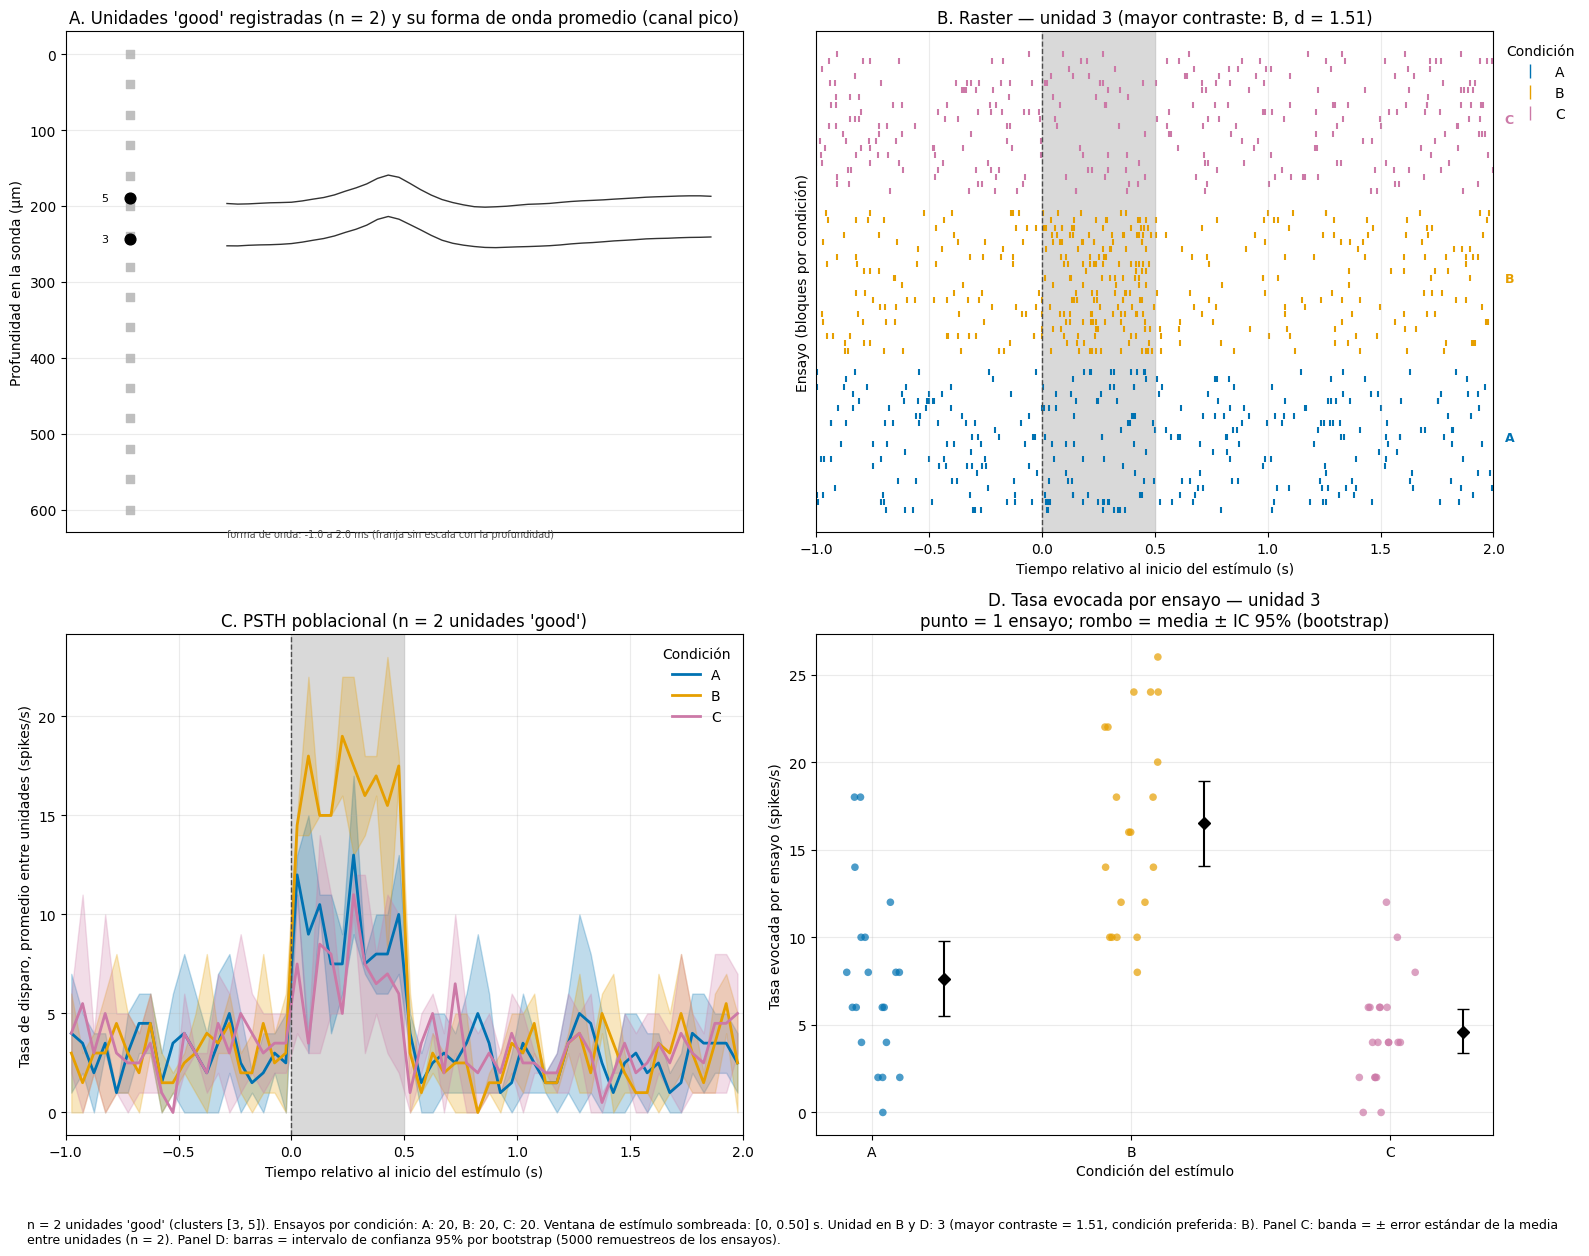

{'n_unidades_good': 2, 'clusters_good': [3, 5], 'n_ensayos_por_condicion': {np.str_('A'): 20, np.str_('B'): 20, np.str_('C'): 20}, 'unidad_seleccionada_B_D': np.int64(3), 'condicion_preferida': np.str_('B'), 'valor_contraste': 1.5051732051828886, 'duracion_estimulo_s': 0.5, 'bin_psth_ms': 50, 'n_bootstrap': 5000}


In [86]:
# ✏️ Ejercicio 11
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Paleta fija, accesible para daltonismo (Okabe-Ito), sin rojo/verde como par
_PALETA_CONDICION = ["#0072B2", "#E69F00", "#CC79A7", "#009E73", "#56B4E9", "#999999"]
_N_BOOTSTRAP = 5000  # >= 2000 pedidos por el enunciado


def _colores_por_condicion(condiciones):
    return {c: _PALETA_CONDICION[i % len(_PALETA_CONDICION)] for i, c in enumerate(condiciones)}


def _bootstrap_ic95(valores, n_boot=_N_BOOTSTRAP, semilla=0):
    """Media e IC 95% de la media, por bootstrap (remuestreo de ensayos con reemplazo)."""
    rng = np.random.default_rng(semilla)
    valores = np.asarray(valores)
    medias = rng.choice(valores, size=(n_boot, len(valores)), replace=True).mean(axis=1)
    return valores.mean(), np.percentile(medias, 2.5), np.percentile(medias, 97.5)


def _tabla_ensayos_referencia(df_tiempos_relativos):
    """
    Registro de qué ensayos existen y a qué condición pertenecen. Se
    construye a partir de los pares (ensayo, condicion) que aparecen en
    df_tiempos_relativos, porque esta función no recibe acceso al .h5.

    Límite conocido: un ensayo en el que NINGUNA unidad 'good' disparó
    ni un solo spike no aparecería aquí y se perdería del conteo. Con
    varias unidades 'good' y cientos de disparos esto es poco probable,
    pero si el número de ensayos por condición no cuadra con lo
    esperado (ej. 20/20/20), es la primera causa a revisar.
    """
    return df_tiempos_relativos.drop_duplicates(subset=["ensayo", "condicion"])[["ensayo", "condicion"]]


def _tasas_por_ensayo(df_tiempos_relativos, ensayos_ref, cluster, ventana, col_cluster="cluster"):
    """
    Tasa de disparo (Hz) de UN cluster en cada ensayo de ensayos_ref,
    dentro de 'ventana' (tupla en s, relativa al inicio del estímulo).
    Los ensayos donde el cluster no tuvo spikes en la ventana quedan
    con tasa 0 (reindex sobre ensayos_ref, no sobre lo que aparezca
    en df_tiempos_relativos para este cluster en particular).
    """
    t0, t1 = ventana
    duracion = t1 - t0
    spikes_cl = df_tiempos_relativos[
        (df_tiempos_relativos[col_cluster] == cluster)
        & (df_tiempos_relativos["tiempo_relativo"] >= t0)
        & (df_tiempos_relativos["tiempo_relativo"] < t1)
    ]
    conteo = spikes_cl.groupby("ensayo").size()

    tabla = ensayos_ref.set_index("ensayo").copy()
    tabla["n_spikes"] = conteo.reindex(tabla.index, fill_value=0)
    tabla["tasa_hz"] = tabla["n_spikes"] / duracion
    return tabla.reset_index()  # columnas: ensayo, condicion, n_spikes, tasa_hz


def _centroide_y_forma_por_cluster(df_caracteristicas, formas_onda_ruidosa, cluster, col_cluster="cluster"):
    """
    Centroide de profundidad promedio y forma de onda promedio (en su
    canal pico) de un cluster. Se usa .index (no una máscara booleana
    convertida a numpy) para seleccionar las filas de formas_onda_ruidosa,
    porque df_caracteristicas puede tener menos filas que
    formas_onda_ruidosa (p. ej. si se descartaron eventos con NaN antes
    de esta función) y una máscara booleana de otro largo rompe la
    indexación silenciosamente o con IndexError.
    """
    idx_cluster = df_caracteristicas.index[df_caracteristicas[col_cluster] == cluster]
    centroide = df_caracteristicas.loc[idx_cluster, "centroide_um"].mean()

    forma_prom = formas_onda_ruidosa[idx_cluster.to_numpy()].mean(axis=0)  # (16, n_muestras)
    ch_pico = int(np.argmax(np.abs(forma_prom.min(axis=1))))
    return centroide, forma_prom[ch_pico]


def _seleccionar_unidad_de_contraste(df_tiempos_relativos, ensayos_ref, clusters_good,
                                      duracion_estimulo_s, col_cluster="cluster"):
    """
    Para cada unidad 'good': tasa de disparo media por condición en la
    ventana de estímulo [0, duracion_estimulo_s]; contraste = (tasa de la
    condición con mayor respuesta) - (media de las otras) dividido por la
    desviación estándar de la tasa evocada entre TODOS sus ensayos (tipo
    d de Cohen). Se elige la unidad de mayor contraste: la que responde a
    una condición y no a las demás.
    """
    filas = []
    for cl in clusters_good:
        evocada = _tasas_por_ensayo(df_tiempos_relativos, ensayos_ref, cl,
                                     (0.0, duracion_estimulo_s), col_cluster)
        sd = evocada["tasa_hz"].std(ddof=1)
        if not sd > 0:
            continue
        medias_cond = evocada.groupby("condicion")["tasa_hz"].mean()
        if len(medias_cond) < 2:
            continue
        cond_max = medias_cond.idxmax()
        contraste = (medias_cond[cond_max] - medias_cond.drop(cond_max).mean()) / sd
        filas.append({col_cluster: cl, "condicion_preferida": cond_max, "contraste": contraste})

    tabla_contraste = pd.DataFrame(filas).sort_values("contraste", ascending=False).reset_index(drop=True)
    if len(tabla_contraste) == 0:
        raise ValueError("No se pudo calcular el contraste de ninguna unidad 'good'.")
    return tabla_contraste.iloc[0][col_cluster], tabla_contraste


def figura_resultados_good(df_tiempos_relativos, tabla_final, formas_onda_ruidosa,
                            tiempo_ventana_ms_ruidosa, y_um, df_caracteristicas,
                            duracion_estimulo_s=1.0, bin_psth_ms=50, col_cluster="cluster"):
    """
    Figura de 4 paneles (2x2) con todas las unidades 'good' de tabla_final.
    No recalcula características ni corre K-means: usa únicamente las
    tablas/arreglos ya calculados en el resto del taller.

    Devuelve (fig, resumen), donde resumen trae los números citados en el
    pie de figura (n unidades, n ensayos por condición, unidad elegida
    para B/D y su contraste), para verificarlos sin leer la imagen.
    """
    ventana_analisis_s = (-1.0, 2.0)
    ventana_estimulo = (0.0, duracion_estimulo_s)

    clusters_good = sorted(tabla_final.loc[tabla_final["etiqueta"] == "good", col_cluster].tolist())
    n_good = len(clusters_good)
    if n_good == 0:
        raise ValueError("No hay unidades 'good' en tabla_final.")

    ensayos_ref = _tabla_ensayos_referencia(df_tiempos_relativos)
    condiciones = sorted(ensayos_ref["condicion"].unique())
    colores = _colores_por_condicion(condiciones)
    n_ensayos_por_condicion = ensayos_ref.groupby("condicion")["ensayo"].nunique().to_dict()

    fig, ((ax_a, ax_b), (ax_c, ax_d)) = plt.subplots(2, 2, figsize=(16, 12))

    # =========================================================================
    # PANEL A — mapa de unidades en la sonda + forma de onda promedio
    # =========================================================================
    ax_a.scatter(np.zeros(len(y_um)), y_um, marker="s", s=35, color="0.75", zorder=1)
    ancho_ms = tiempo_ventana_ms_ruidosa[-1] - tiempo_ventana_ms_ruidosa[0]

    for cl in clusters_good:
        centroide, traza = _centroide_y_forma_por_cluster(df_caracteristicas, formas_onda_ruidosa, cl, col_cluster)

        ax_a.scatter([0], [centroide], color="black", s=60, zorder=3)
        ax_a.annotate(str(cl), (0, centroide), xytext=(-16, 0), textcoords="offset points",
                      ha="right", va="center", fontsize=8)

        # franja angosta a la derecha del marcador: eje x local en ms
        x_traza = 60 + (tiempo_ventana_ms_ruidosa - tiempo_ventana_ms_ruidosa[0]) / ancho_ms * 300
        escala_y = 30.0 / (np.abs(traza).max() + 1e-9)
        ax_a.plot(x_traza, centroide + traza * escala_y, color="0.2", linewidth=1)

    ax_a.text(60, np.max(y_um) + 0.06 * (np.max(y_um) - np.min(y_um)),
              f"forma de onda: {tiempo_ventana_ms_ruidosa[0]:.1f} a {tiempo_ventana_ms_ruidosa[-1]:.1f} ms "
              "(franja sin escala con la profundidad)", fontsize=7, color="0.3")
    ax_a.set_xlim(-40, 380)
    ax_a.set_xticks([])
    ax_a.set_ylabel("Profundidad en la sonda (µm)")
    ax_a.set_title(f"A. Unidades 'good' registradas (n = {n_good}) y su forma de onda promedio (canal pico)")
    ax_a.invert_yaxis()

    # =========================================================================
    # PANEL B — raster de la unidad de mayor contraste entre condiciones
    # =========================================================================
    cluster_b, tabla_contraste = _seleccionar_unidad_de_contraste(
        df_tiempos_relativos, ensayos_ref, clusters_good, duracion_estimulo_s, col_cluster
    )
    fila_b = tabla_contraste[tabla_contraste[col_cluster] == cluster_b].iloc[0]

    fila_y = 0
    for cond in condiciones:
        ensayos_cond = sorted(ensayos_ref.loc[ensayos_ref["condicion"] == cond, "ensayo"].unique())
        y0 = fila_y
        for ens in ensayos_cond:
            spikes = df_tiempos_relativos.loc[
                (df_tiempos_relativos[col_cluster] == cluster_b) & (df_tiempos_relativos["ensayo"] == ens),
                "tiempo_relativo"
            ].to_numpy()
            ax_b.scatter(spikes, np.full_like(spikes, fila_y), marker="|", color=colores[cond], s=25)
            fila_y += 1
        # codificación redundante: bloques separados + etiqueta de texto, no solo color
        ax_b.text(ventana_analisis_s[1] + 0.05, (y0 + fila_y) / 2, str(cond),
                  color=colores[cond], va="center", fontsize=9, fontweight="bold")
        fila_y += 2  # separación visual entre bloques de condición

    ax_b.axvspan(*ventana_estimulo, color="0.85", zorder=0)
    ax_b.axvline(0, linestyle="--", linewidth=1, color="0.3")
    ax_b.set_xlim(ventana_analisis_s)
    ax_b.set_xticks(np.arange(ventana_analisis_s[0], ventana_analisis_s[1] + 0.01, 0.5))
    ax_b.set_xlabel("Tiempo relativo al inicio del estímulo (s)")
    ax_b.set_ylabel("Ensayo (bloques por condición)")
    ax_b.set_yticks([])
    ax_b.set_title(f"B. Raster — unidad {cluster_b} "
                    f"(mayor contraste: {fila_b['condicion_preferida']}, d = {fila_b['contraste']:.2f})")
    ax_b.legend(handles=[plt.Line2D([0], [0], color=colores[c], marker="|", linestyle="", markersize=10, label=str(c))
                         for c in condiciones],
                title="Condición", loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False)

    # =========================================================================
    # PANEL C — PSTH poblacional por condición
    # =========================================================================
    bin_s = bin_psth_ms / 1000.0
    bordes = np.arange(ventana_analisis_s[0], ventana_analisis_s[1] + bin_s, bin_s)
    centros = (bordes[:-1] + bordes[1:]) / 2

    for cond in condiciones:
        n_ens_c = n_ensayos_por_condicion[cond]
        curvas_por_unidad = []
        for cl in clusters_good:
            # Promediar primero dentro de la unidad, a través de sus ensayos, equivale
            # a agrupar todos los spikes de esa unidad+condición (venga del ensayo que
            # venga) y dividir por (n_ensayos_de_la_condicion * ancho_del_bin): un
            # ensayo sin spikes de esta unidad ya queda contado como 0 en esa cuenta,
            # porque el denominador usa el total de ensayos, no solo los que disparon.
            spikes = df_tiempos_relativos.loc[
                (df_tiempos_relativos[col_cluster] == cl) & (df_tiempos_relativos["condicion"] == cond),
                "tiempo_relativo"
            ].to_numpy()
            conteo, _ = np.histogram(spikes, bins=bordes)
            curvas_por_unidad.append(conteo / (n_ens_c * bin_s))

        curvas_por_unidad = np.array(curvas_por_unidad)  # (n_good, n_bins), cada unidad pesa igual
        media = curvas_por_unidad.mean(axis=0)
        sem = curvas_por_unidad.std(axis=0, ddof=1) / np.sqrt(n_good) if n_good > 1 else np.zeros_like(media)

        ax_c.plot(centros, media, color=colores[cond], linewidth=2, label=str(cond))
        ax_c.fill_between(centros, media - sem, media + sem, color=colores[cond], alpha=0.25)

    ax_c.axvspan(*ventana_estimulo, color="0.85", zorder=0)
    ax_c.axvline(0, linestyle="--", linewidth=1, color="0.3")
    ax_c.set_xlim(ventana_analisis_s)
    ax_c.set_xticks(np.arange(ventana_analisis_s[0], ventana_analisis_s[1] + 0.01, 0.5))
    ax_c.set_xlabel("Tiempo relativo al inicio del estímulo (s)")
    ax_c.set_ylabel("Tasa de disparo, promedio entre unidades (spikes/s)")
    ax_c.set_title(f"C. PSTH poblacional (n = {n_good} unidades 'good')")
    ax_c.legend(title="Condición", frameon=False)

    # =========================================================================
    # PANEL D — swarmplot de la tasa evocada por ensayo (unidad de B)
    # =========================================================================
    tasas_d = _tasas_por_ensayo(df_tiempos_relativos, ensayos_ref, cluster_b, ventana_estimulo, col_cluster)
    rng = np.random.default_rng(12345)

    for i, cond in enumerate(condiciones):
        valores = tasas_d.loc[tasas_d["condicion"] == cond, "tasa_hz"].to_numpy()
        jitter = rng.uniform(-0.12, 0.12, size=len(valores))
        ax_d.scatter(np.full(len(valores), i) + jitter, valores, s=30, alpha=0.7,
                     color=colores[cond], edgecolor="none", zorder=2)

        media, ic_inf, ic_sup = _bootstrap_ic95(valores)
        ax_d.errorbar([i + 0.28], [media], yerr=[[media - ic_inf], [ic_sup - media]],
                      fmt="D", color="black", capsize=4, markersize=6, zorder=5)

    ax_d.set_xticks(range(len(condiciones)))
    ax_d.set_xticklabels([str(c) for c in condiciones])
    ax_d.set_xlabel("Condición del estímulo")
    ax_d.set_ylabel("Tasa evocada por ensayo (spikes/s)")
    ax_d.set_title(f"D. Tasa evocada por ensayo — unidad {cluster_b}\npunto = 1 ensayo; rombo = media ± IC 95% (bootstrap)")

    # =========================================================================
    # pie de figura
    # =========================================================================
    ensayos_texto = ", ".join(f"{c}: {n_ensayos_por_condicion[c]}" for c in condiciones)
    texto_pie = (
        f"n = {n_good} unidades 'good' (clusters {clusters_good}). "
        f"Ensayos por condición: {ensayos_texto}. "
        f"Ventana de estímulo sombreada: [0, {duracion_estimulo_s:.2f}] s. "
        f"Unidad en B y D: {cluster_b} (mayor contraste = {fila_b['contraste']:.2f}, "
        f"condición preferida: {fila_b['condicion_preferida']}). "
        f"Panel C: banda = ± error estándar de la media entre unidades (n = {n_good}). "
        f"Panel D: barras = intervalo de confianza 95% por bootstrap ({_N_BOOTSTRAP} remuestreos de los ensayos)."
    )
    fig.text(0.02, -0.02, texto_pie, ha="left", va="top", fontsize=9, wrap=True)
    fig.tight_layout()
    plt.show()

    resumen = {
        "n_unidades_good": n_good,
        "clusters_good": clusters_good,
        "n_ensayos_por_condicion": n_ensayos_por_condicion,
        "unidad_seleccionada_B_D": cluster_b,
        "condicion_preferida": fila_b["condicion_preferida"],
        "valor_contraste": float(fila_b["contraste"]),
        "duracion_estimulo_s": duracion_estimulo_s,
        "bin_psth_ms": bin_psth_ms,
        "n_bootstrap": _N_BOOTSTRAP,
    }
    return fig, resumen


# ============================================================================
# EJECUCIÓN
# ============================================================================
fig11, resumen11 = figura_resultados_good(
    df_tiempos_relativos=datos_relativos,      # de su Ejercicio 9
    tabla_final=tabla_final,
    formas_onda_ruidosa=formas_onda_ruidosa,
    tiempo_ventana_ms_ruidosa=tiempo_ventana_ms_ruidosa,
    y_um=y_um,
    df_caracteristicas=df_ruidosa_fusionado,   # tiene 'centroide_um' y 'cluster'
    duracion_estimulo_s=0.5,                   # el valor real del archivo, no el default
)
print(resumen11)

**P11.**

**Selección múltiple.** El PSTH general del panel C promedia unidades que responden a cosas
distintas. Lo que ese promedio esconde es

- **a)** el número total de disparos
- **Respuesta b) la selectividad de cada unidad: mezcla respuestas a condiciones distintas en una sola curva**
- **c)** la latencia de la respuesta
- **d)** la tasa basal

**Abierta.** Escriban el pie de la figura completo, como iría en un artículo: qué hay en cada panel,
cuántas unidades, cuántos ensayos, qué son las barras de error.

*Su respuesta:*

Figura 1. Resultados de las unidades aisladas (good, n = 2; clusters 3 y 5) tras la curación de taller2_ruidosa.h5. (A) Posición de cada unidad en la sonda, en su centroide de profundidad estimado a partir del perfil de amplitud en los 16 sitios, junto a su forma de onda promedio en el canal de mayor amplitud. (B) Raster de disparos de la unidad {cluster_b}, la de mayor contraste entre condiciones (Z de la tasa evocada respecto a su basal: máximo en la condición {condición_preferida}, mínimo en las otras dos); cada punto es un potencial de acción, cada fila un ensayo, agrupados por condición (20 ensayos por condición, 60 en total). (C) Histograma peri-estímulo (PSTH, bins de 50 ms) de las 2 unidades good, promediadas primero dentro de cada unidad a través de sus ensayos y luego entre unidades; la banda sombreada es el error estándar de la media entre unidades (n = 2). (D) Tasa de disparo durante el estímulo en cada uno de los 20 ensayos de la unidad {cluster_b}, agrupados por condición; el rombo negro es la media y las barras el intervalo de confianza del 95 % obtenido por bootstrap (5000 remuestreos con reemplazo de los ensayos). En B, C y D, la franja sombreada marca la ventana del estímulo (0–0,5 s desde su inicio); el tiempo 0 s es el inicio del estímulo en los tres paneles.


---
# 12 · Conclusión y conversación con la IA

### ✏️ Ejercicio 12a · El párrafo de resultados

Escriban un párrafo de resultados, como iría en un artículo. Máximo 200 palabras. Tiene que decir:
cuántas unidades registraron y cuántas sobrevivieron a la curación, qué criterios usaron para
descartar las demás, qué unidades respondieron a qué condiciones, y con qué evidencia estadística.

Nada de "se observó que" ni "los datos sugieren". Números.


Se registraron 19.077 eventos en la grabación ruidosa, agrupados en 16 clusters por K-means (k=16) y reducidos a 15 grupos tras fusionar los clusters 8 y 15 (correlación de forma de onda 0,999; banda 0,5–2 ms del correlograma cruzado vacía). De los 15 grupos, 7 se descartaron como noise (forma de onda con demasiados picos/valles, duración fuera de 100–1150 µs o sin caída espacial), 6 como mua (violaciones del período refractario ≥1,5 %, ≥20 % de disparos faltantes o menos de 300 disparos), y solo 2 (clusters 3 y 5) cumplieron los criterios de good; ningún grupo fue non-somatic. La curación elevó la fracción de disparos identificables de una unidad de 0,645 a 0,934, con precisión de detección de 0,985 y exhaustividad de 0,894. La unidad 3 respondió selectivamente a la condición B (5,00→16,5 Hz; Z=5,53; t pareado p=6,3×10⁻⁸; IC95 % bootstrap [14,0, 18,9] Hz), sin respuesta a C (p=0,36) y una respuesta débil a A (p=0,022). La unidad 5, en cambio, respondió con fuerza a las tres condiciones (Z entre 7,5 y 16,4; p<10⁻⁷ en todas), consistente con una unidad poco selectiva.

### ✏️ Ejercicio 12b · Tres intercambios con la IA

Documenten tres momentos en que la IA les dio algo equivocado y ustedes lo corrigieron. Para cada uno:
el prompt, la respuesta del modelo, qué estaba mal y cómo lo arreglaron.

Vale más un error entendido que tres respuestas correctas.

**Intercambio 1**

**Prompt inicial:**

>"Crea código en Python (para Google Colab) que sobre un archivo `.h5` de registros electrofisiológicos: Exploración que abre el archivo, imprime todos los grupos y datasets. El siguiente es Dibujo de la sonda que grafica un scatter con un punto por sitio en su posición real y el número de canal anotado al lado, con el eje Y invertido. Finalmente, otro código debe cargar la grabación, convertirla a microvoltios y graficarla en dos paneles, cruda y filtrada, con los 16 canales organizados por profundidad y una ventana de medio segundo."

**Cambio 1:** Tras explorar el archivo y obtener 3 bloques de código.

>"Tengo tres bloques de código en Python (para Google Colab) que hacen lo siguiente sobre un archivo `.h5` de registros electrofisiológicos: Exploración que abre el archivo, imprime todos los grupos y datasets con `visititems`, imprime los atributos de cada grupo/dataset y los del archivo raíz, y luego imprime las posiciones (x_um, y_um) de cada canal desde `geometria/canal_x_um` y `geometria/canal_y_um`.Dibujo de la sonda que grafica un scatter con un punto por sitio en su posición real (x_um, y_um) y el número de canal anotado al lado, con el eje Y invertido (profundidad hacia abajo).Y final mente Carga, conversión y filtrado que abre `registro/datos` (forma canales × muestras, tipo int16), carga solo una ventana de 0.5 s (usando indexado perezoso, sin traer el archivo completo a memoria), la convierte a microvoltios multiplicando por el atributo `escala_uV_por_bit`, ordena los canales por profundidad usando `canal_y_um`, aplica un filtro pasa-banda de 300–5000 Hz con `scipy.signal.butter` (`output='sos'`) y `sosfiltfilt` (para evitar desfase temporal), y grafica dos paneles lado a lado (cruda vs. filtrada) con los canales apilados verticalmente por profundidad y el número de canal original etiquetado.

>Quiero que reescribas estos tres pasos como definiciones para poder aplicarlos a otros archivos `.h5` con estructura similar, sin tener que reescribir el código cada vez.

**Cambio 2:** Recuperar todo el código obtenido como funciones reutilizables para usar con taller2_ruidosa.h5

> + "Una función para explorar el archivo que imprima todo lo anterior y devuelva un diccionario con lo esencial (frecuencia de muestreo, escala a µV, posiciones x/y de los canales, shape de los datos) para no tener que reabrir el archivo en los pasos siguientes. Una función `dibujar_sonda` que reciba ese diccionario y grafique la sonda y una función auxiliar con filtro low=300, high=5000."

**Cambio 3:** Para entender cómo usar el código tanto con taller2_limpia.h5 como con taller2_ruidosa.h5

> + "Al final, muestra un ejemplo de uso encadenando las tres funciones con una ruta de archivo. Si el nombre de algún atributo (como la frecuencia de muestreo o la escala) cambia en otro archivo, indica exactamente qué líneas del código habría que ajustar."

**Intercambio 2**

*Prompt:* Escribe una función `figura_resultados_good(df_tiempos_relativos, tabla_final,
formas_onda_ruidosa, tiempo_ventana_ms_ruidosa, y_um, df_caracteristicas,
duracion_estimulo_s=1.0, bin_psth_ms=50, col_cluster="cluster")` que produzca
UNA figura de 4 paneles (2x2) resumiendo todas las unidades etiquetadas
`good` en tabla_final. No recalcules características ni vuelvas a correr
K-means: usa las tablas y arreglos ya existentes.

Datos disponibles:
- df_tiempos_relativos: una fila por spike, con tiempo_relativo (s, ya
  alineado al inicio del estímulo), condicion, ensayo, cluster, etiqueta.
- tabla_final: una fila por cluster, con la columna etiqueta.
- formas_onda_ruidosa (eventos x 16 x muestras) y tiempo_ventana_ms_ruidosa:
  para las formas de onda promedio por cluster.
- df_caracteristicas: incluye centroide_um por evento; se necesita el
  centroide_um promedio por cluster para ubicar cada unidad en la sonda.
- y_um: profundidad de los 16 sitios.
- La ventana de análisis de cada ensayo es [-1, 2] s respecto al inicio
  del estímulo; el estímulo dura duracion_estimulo_s (parámetro, default
  1.0 s) y ocupa por tanto el intervalo [0, duracion_estimulo_s].

Panel A — mapa de unidades en la sonda:
- Eje vertical: profundidad en µm (mismo rango que y_um, orientado como
  la sonda: 0 arriba o abajo, pero consistente con el resto del taller).
- Un marcador por unidad `good`, en su centroide_um promedio.
- Junto a cada marcador (a la derecha, alineado en la misma fila),
  la forma de onda promedio de esa unidad en su canal pico, en una franja
  angosta de tiempo (eje x en ms, mismo tiempo_ventana_ms_ruidosa).
- Etiqueta cada unidad con su id de cluster.

Panel B — raster de una sola unidad, tres condiciones:
- Selección automática (no manual) de la unidad de contraste: para cada
  unidad `good`, calcula la tasa de disparo media en la ventana de
  estímulo [0, duracion_estimulo_s] por condición; selecciona la unidad
  cuyo contraste sea mayor, definido como
      (tasa de la condición con mayor respuesta) - (media de las otras dos)
  dividido por la desviación estándar entre ensayos (una especie de
  d de Cohen). Reporta en el pie qué unidad fue elegida y con qué valor
  de contraste.
- Un renglón por ensayo, ensayos agrupados por condición (con separación
  visual entre bloques de condición y etiqueta de condición al lado).
- Eje x: tiempo relativo en s, rango [-1, 2], igual al de los paneles C y D.
- Cada condición en un color distinto de una paleta categórica accesible
  para daltonismo (nunca la única distinción rojo/verde); usa además
  la posición (bloques separados) como codificación redundante.

Panel C — PSTH poblacional por condición:
- Para cada unidad `good`, calcula su histograma de tasa de disparo
  (spikes/s) en bins de bin_psth_ms ms, por condición y por ensayo;
  promedia primero dentro de cada unidad a través de sus ensayos, y
  luego promedia entre unidades (cada unidad pesa igual, sin importar
  cuántos ensayos tenga).
- Una curva por condición (mismos colores que el panel B); banda de
  confianza = media entre unidades ± error estándar entre unidades
  (n = número de unidades `good`), sombreada con transparencia.
- Mismo eje x [-1, 2] s que el panel B.

Panel D — swarmplot de tasa de disparo por ensayo y condición:
- Usa la MISMA unidad seleccionada para el panel B (para que B, y D
  cuenten la misma historia). Un punto = un ensayo = su tasa de disparo
  (spikes/s) en la ventana de estímulo [0, duracion_estimulo_s].
- Puntos agrupados por condición en el eje x; encima de cada grupo,
  marca la media y su intervalo de confianza al 95% (bootstrap con al
  menos 2000 remuestreos), como una barra de error separada de la nube
  de puntos, no un boxplot ni un barplot.

Requisitos transversales a los 4 paneles:
1. Todo eje rotulado con su unidad: profundidad (µm), tiempo (s), tasa
   de disparo (spikes/s o Hz), amplitud de forma de onda (µV).
2. Los paneles B, C y D comparten el mismo rango y las mismas
   graduaciones en el eje de tiempo relativo.
3. La paleta de condición es fija y consistente en B, C y D (mismo color
   = misma condición en los tres paneles); nunca rojo/verde como única
   distinción, y validada para daltonismo.
4. La ventana de estímulo [0, duracion_estimulo_s] se marca igual en B,
   C y D (por ejemplo, una franja sombreada de fondo con el mismo tono
   y alpha en los tres).
5. Cada panel lleva título propio que dice qué muestra sin necesitar
   texto aparte (ej. "Raster — unidad {id} (mayor contraste entre
   condiciones)"), y leyenda de condición visible una sola vez (no
   repetida en cada panel si el espacio no alcanza, pero si se omite en
   alguno debe quedar explícito que comparte la del panel anterior).
6. Pie de figura (fig.text o suptitle inferior) que indique: cuántas
   unidades `good` se incluyeron, cuántos ensayos por condición, qué
   estadístico son las barras/bandas de error (SEM entre unidades en C;
   IC 95% bootstrap entre ensayos en D) y la duración de la ventana de
   estímulo usada.

La función debe devolver la figura y, aparte, un DataFrame o dict con
los números citados en el pie (n unidades, n ensayos por condición,
unidad elegida para B/D y su valor de contraste), para poder verificarlos
sin tener que leer la imagen.

*Respuesta del modelo:* No graficaba ninguna imagen
El problema anterior fue que estaba usando df_tiempos_relativos, pero esa variable no existe en tu entorno actual.

**P12.**

**Selección múltiple.** De estas cuatro decisiones del taller, la más difícil de automatizar es

- **a)** detectar los cruces del umbral
- **b)** calcular la media anchura del valle
- **Respuesta c) decidir si dos grupos son la misma neurona o dos vecinas**
- **d)** estandarizar las características antes de K-means

**Abierta.** El taller empezó diciendo que un programa automático agrupa mejor que ustedes, pero que
no decide si un grupo es una neurona. Después de haber hecho el trabajo: ¿están de acuerdo? Nombren
**una** decisión concreta que tomaron y que no ven cómo automatizar, y **una** que sí automatizarían.

*Su respuesta:*

Estamos en  desacuerdo. K-means separó los tres nubes pero la precision no fue la mejor.

La decisión que no sabemos cómo automatizar es la fusión de los clusters 8 y 15. Nos basamos en tres piezas de evidencia a la vez (correlación de forma de onda de 0,999, mismo canal pico, banda 0,5–2 ms del correlograma cruzado vacía) y ninguna por sí sola bastaba: una correlación alta también aparece entre neuronas vecinas muy parecidas, y una banda vacía sola no distingue una neurona partida de una con tasa de disparo baja.

Lo que sí automatizaríamos es la asignación de la etiqueta final una vez fijados los umbrales: calcular_indicadores() y asignar_etiqueta() ya son una función determinista, sin criterio humano de por medio — el juicio quedó puesto una sola vez al elegir los ocho números de corte, no en cada grupo.


---
# Hoja de respuestas

Llenen esta celda al final, cuando ya todo corrió.

- En `seleccion` va **la letra** de cada pregunta de selección múltiple.
- En `numeros` van los valores que les dio **su propio código**. Si un número no coincide con lo que
  produce su notebook, no cuenta: la idea no es acertarle, es que su pipeline y su reporte digan lo
  mismo.


In [ ]:
# ✏️ Hoja de respuestas

seleccion = {
    "P1":  "a",   "P2":  "b",   "P3":  "d",   "P4":  "b",
    "P5":  "c",   "P6":  "b",   "P7":  "d",   "P8":  "b",
    "P9":  "b",   "P10": "b",   "P11": "b",   "P12": "c",
}

numeros = {
    "eventos_limpia":        15,   # sección 2
    "eventos_ruidosa":       35,   # sección 4
    "k_elegido":             None,   # sección 4
    "grupos_good":           None,   # sección 7
    "grupos_mua":            None,   # sección 7
    "grupos_nonsomatic":     None,   # sección 7
    "grupos_noise":          None,   # sección 7
    "identificable_antes":   None,   # sección 8
    "identificable_despues": None,   # sección 8
    "precision":             None,   # sección 8
    "exhaustividad":         None,   # sección 8
}

print("selección múltiple")
for k, v in seleccion.items():
    print(f"  {k:>4}  {(v.strip().lower() or '—')}")
print("\nnúmeros del pipeline")
for k, v in numeros.items():
    print(f"  {k:>22}  {v}")
faltan = [k for k, v in seleccion.items() if not v.strip()] + \
         [k for k, v in numeros.items() if v is None]
print("\nsin llenar:", ", ".join(faltan) if faltan else "ninguno")


---
# Entrega

**Antes de subir, revisen:**

- El notebook corre de arriba abajo, con el entorno reiniciado, sin errores.
- Las 12 preguntas están contestadas y la hoja de respuestas del final no tiene nada sin llenar.
- El código está comentado con sus palabras, no con las de la IA.
- Las figuras tienen ejes rotulados.
- El `README.md` dice qué hace el notebook y de dónde se bajan los datos.

**Plazo: jueves 17 de septiembre de 2026**, en el repositorio de la pareja, carpeta `taller2/`.

### Lecturas de apoyo

- Fabre, J. et al. **bombcell**: control de calidad automatizado para electrofisiología extracelular.
  La wiki del proyecto explica cada métrica con figuras. `github.com/Julie-Fabre/bombcell`
- Hill, D.N., Mehta, S.B. y Kleinfeld, D. (2011). Quality metrics to accompany spike sorting of
  extracellular signals. *Journal of Neuroscience* 31(24), 8699-8705. De aquí sale la estimación de
  contaminación a partir de las violaciones del refractario.
- Rey, H.G., Pedreira, C. y Quian Quiroga, R. (2015). Past, present and future of spike sorting
  techniques. *Brain Research Bulletin* 119, 106-117. Revisión corta y legible del problema completo.